In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'
OUTPUT_DIR = os.path.join(BASE_PATH, 'master_data')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [28]:
master_parquet_path = os.path.join(OUTPUT_DIR, 'master_payment_level.parquet')

In [29]:
# Read the master payment level parquet file
master_df = pd.read_parquet(master_parquet_path)

print(f'Shape: {master_df.shape[0]:,} rows x {master_df.shape[1]} columns')
print(f'Memory usage: {master_df.memory_usage(deep=True).sum() / (1024**3):.2f} GB')
print(f'\nColumn dtypes:\n{master_df.dtypes}')
print(f'\nSample rows:')
master_df.head(3)

Shape: 18,776,843 rows x 71 columns
Memory usage: 14.98 GB

Column dtypes:
file_no                               str
loan_number                           str
state                                 str
loan_status                           str
closure_date               datetime64[us]
                                ...      
coapp_female_median_age           float64
coapp_male_avg_age                float64
coapp_male_median_age             float64
coapp_min_age                     float64
coapp_max_age                     float64
Length: 71, dtype: object

Sample rows:


,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,...,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
0,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,5.0,2024-12-31,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
1,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,4.0,2024-11-30,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
2,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,3.0,2024-10-31,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0


In [30]:
# Figure out important columns

In [31]:
master_df.columns.tolist()

['file_no',
 'loan_number',
 'state',
 'loan_status',
 'closure_date',
 'maturity_date',
 'installment_number',
 'installment_due_date',
 'communicated_installment_date',
 'emi_amount',
 'paid_emi',
 'unpaid_emi',
 'number_of_paid_emis',
 'number_of_unpaid_emis',
 'dpd_max',
 'bucket_prior',
 'bucket_current',
 'transaction_id',
 'receipt_id',
 'installment_due_date_y',
 'installment_amount',
 'transaction_date',
 'transaction_amount',
 'allocated_amount',
 'transaction_status',
 'payment_mode',
 'payment_sub_mode',
 'payment_source',
 'rank',
 'year',
 'month',
 'communicated_installment_date1',
 'bounce_flag',
 'masked_loan_id',
 'fileno',
 'loan_origination_date',
 'scheduled_maturity_date',
 'tenure_total',
 'product_type',
 'secured_flag',
 'interest_rate',
 'emi_frequency',
 'disbursed_amount',
 'principal_outstanding',
 'ltv',
 'bureau_score_origination',
 'restructured_flag',
 'moratorium_flag',
 'branch',
 'repayment_start_date',
 'sourcing_channel',
 'scheme',
 'customer_age'

In [32]:
mapper_df = master_df[['loan_number','masked_loan_id','loan_origination_date']]

In [33]:
mapper_df = mapper_df.drop_duplicates()

In [34]:
mapper_df.shape

(620458, 3)

In [35]:
BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'

In [36]:
mapper_df.to_csv(BASE_PATH+'mapper_df.csv',index=False)

In [8]:
mapper_df['loan_number'].value_counts()

loan_number
FSAPLALONS000005590813    1
FSAPLALONS000005588821    1
FSAPLALONS000005590034    1
FSAPLALONS000005585770    1
FSAPLALONS000005597544    1
                         ..
FSUPLALONS000005522209    1
FSUPLALONS000005541608    1
FSUPLALONS000005549525    1
FSUPLALONS000005543280    1
FSUPLALONS000005527120    1
Name: count, Length: 620458, dtype: int64

In [9]:
master_df.columns

Index(['file_no', 'loan_number', 'state', 'loan_status', 'closure_date',
       'maturity_date', 'installment_number', 'installment_due_date',
       'communicated_installment_date', 'emi_amount', 'paid_emi', 'unpaid_emi',
       'number_of_paid_emis', 'number_of_unpaid_emis', 'dpd_max',
       'bucket_prior', 'bucket_current', 'transaction_id', 'receipt_id',
       'installment_due_date_y', 'installment_amount', 'transaction_date',
       'transaction_amount', 'allocated_amount', 'transaction_status',
       'payment_mode', 'payment_sub_mode', 'payment_source', 'rank', 'year',
       'month', 'communicated_installment_date1', 'bounce_flag',
       'masked_loan_id', 'fileno', 'loan_origination_date',
       'scheduled_maturity_date', 'tenure_total', 'product_type',
       'secured_flag', 'interest_rate', 'emi_frequency', 'disbursed_amount',
       'principal_outstanding', 'ltv', 'bureau_score_origination',
       'restructured_flag', 'moratorium_flag', 'branch',
       'repayment_start

In [10]:
master_df['loan_number'].value_counts()

loan_number
HL1070002                 108
HL1140003                 107
HL1210003                 106
HL1020003                 103
HL1270004                 102
                         ... 
FSUPLALONS000005770284      1
FSUPLALONS000005770818      1
FSUPLALONS000005770743      1
FSUPLALONS000005770289      1
FSUPLALONS000005772860      1
Name: count, Length: 620458, dtype: int64

In [11]:
vc = master_df["loan_number"].value_counts()
print(vc[vc == 20])

loan_number
FSAPLALONS000005482051    20
FSAPLALONS000005510855    20
FSAPLALONS000005476721    20
FSAPLALONS000005478272    20
FSAPLALONS000005480231    20
                          ..
FSUPLALONS000005570410    20
FSUPLALONS000005518239    20
FSUPLALONS000005518240    20
FSUPLALONS000005559839    20
FSUPLALONS000005559840    20
Name: count, Length: 14928, dtype: int64


In [12]:
master_df.shape

(18776843, 71)

In [13]:
master_df['payment_sub_mode'].value_counts(1)

payment_sub_mode
NEFT                 0.706006
NACH                 0.243728
SUB_PAYMENT_1        0.049963
RTGS                 0.000302
INTERNAL_TRANSFER    0.000001
Name: proportion, dtype: double[pyarrow]

In [14]:
master_df['payment_mode'].value_counts(1)

payment_mode
ELECTRONIC_FUND_TRANSFER    0.527446
CASH                        0.457872
CHEQUE                      0.009414
DEMAND_DRAFT                0.004841
DRAFT                       0.000427
Name: proportion, dtype: double[pyarrow]

In [15]:
master_df['payment_source'].value_counts(1)

payment_source
BBP               0.89308
RP               0.064215
UPI              0.042559
JP               0.000118
RPE              0.000019
BPP              0.000005
pay              0.000001
Rp               0.000001
056932/INDIAN         0.0
RM                    0.0
ICICI                 0.0
BP                    0.0
P                     0.0
BBPS                  0.0
TQmLc1RP              0.0
Name: proportion, dtype: double[pyarrow]

In [16]:
master_df['rank'].value_counts(1)

rank
1.0    1.0
Name: proportion, dtype: float64

In [17]:
master_df.head()

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,...,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
0,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,5.0,2024-12-31,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
1,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,4.0,2024-11-30,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
2,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,3.0,2024-10-31,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
3,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,2.0,2024-09-30,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
4,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,1.0,2024-08-31,5.0,8582.0,...,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0


In [18]:
sample_df = master_df[master_df['loan_number'] == 'FSAPLALONS000005482051']

In [19]:
sample_df

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,...,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
173714,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,20.0,2025-07-31,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173715,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,19.0,2025-06-30,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173716,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,18.0,2025-05-31,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173717,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,17.0,2025-04-30,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173718,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,16.0,2025-03-31,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173719,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,15.0,2025-02-28,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173720,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,14.0,2025-01-31,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173721,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,13.0,2024-12-31,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173722,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,12.0,2024-11-30,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173723,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,11.0,2024-10-31,31.0,8674.0,...,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0


In [20]:
# Option 1: Print all columns as a list
print(sample_df.columns.tolist())

# Option 2: See all columns with dtypes and null counts
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(sample_df.dtypes)

# Option 3: Full info without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
sample_df

['file_no', 'loan_number', 'state', 'loan_status', 'closure_date', 'maturity_date', 'installment_number', 'installment_due_date', 'communicated_installment_date', 'emi_amount', 'paid_emi', 'unpaid_emi', 'number_of_paid_emis', 'number_of_unpaid_emis', 'dpd_max', 'bucket_prior', 'bucket_current', 'transaction_id', 'receipt_id', 'installment_due_date_y', 'installment_amount', 'transaction_date', 'transaction_amount', 'allocated_amount', 'transaction_status', 'payment_mode', 'payment_sub_mode', 'payment_source', 'rank', 'year', 'month', 'communicated_installment_date1', 'bounce_flag', 'masked_loan_id', 'fileno', 'loan_origination_date', 'scheduled_maturity_date', 'tenure_total', 'product_type', 'secured_flag', 'interest_rate', 'emi_frequency', 'disbursed_amount', 'principal_outstanding', 'ltv', 'bureau_score_origination', 'restructured_flag', 'moratorium_flag', 'branch', 'repayment_start_date', 'sourcing_channel', 'scheme', 'customer_age', 'gender', 'employment_status', 'customer_income', 

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,paid_emi,unpaid_emi,number_of_paid_emis,number_of_unpaid_emis,dpd_max,bucket_prior,bucket_current,transaction_id,receipt_id,installment_due_date_y,installment_amount,transaction_date,transaction_amount,allocated_amount,transaction_status,payment_mode,payment_sub_mode,payment_source,rank,year,month,communicated_installment_date1,bounce_flag,masked_loan_id,fileno,loan_origination_date,scheduled_maturity_date,tenure_total,product_type,secured_flag,interest_rate,emi_frequency,disbursed_amount,principal_outstanding,ltv,bureau_score_origination,restructured_flag,moratorium_flag,branch,repayment_start_date,sourcing_channel,scheme,customer_age,gender,employment_status,customer_income,income_to_emi_ratio,customer_segment,prior_loans_count,prior_delinquency_history,caopp_data_flag,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
173714,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,20.0,2025-07-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264295.0,61901961.0,2025-07-31,8674.0,2025-07-05,8700.0,8622.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,7,2025-07-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173715,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,19.0,2025-06-30,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264294.0,60530302.0,2025-06-30,8674.0,2025-06-04,8674.0,8622.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,6,NaT,1,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173716,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,18.0,2025-05-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264293.0,59192302.0,2025-05-31,8674.0,2025-05-03,8700.0,8648.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,5,2025-05-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173717,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,17.0,2025-04-30,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264292.0,58162916.0,2025-04-30,8674.0,2025-04-10,8700.0,8674.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,4,NaT,1,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173718,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,16.0,2025-03-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264291.0,56779491.0,2025-03-31,8674.0,2025-03-07,8438.0,8438.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,3,2025-03-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173719,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,

# Creating target variable

## Steps
- 1. Filter the dataset where for loan emi, transaction status == C and payment mode 
  2. 

In [21]:
master_df['communicated_installment_date'].value_counts(1)
# Instead of 30th and 31st modify the communicated day

communicated_installment_date
5.0     0.460820
10.0    0.177986
20.0    0.149714
15.0    0.141561
31.0    0.030907
30.0    0.018642
2.0     0.006256
28.0    0.003617
29.0    0.001519
24.0    0.001170
3.0     0.000593
1.0     0.000560
13.0    0.000522
11.0    0.000503
17.0    0.000460
4.0     0.000458
21.0    0.000405
12.0    0.000404
7.0     0.000393
6.0     0.000386
8.0     0.000379
9.0     0.000366
16.0    0.000364
22.0    0.000354
23.0    0.000348
14.0    0.000323
18.0    0.000305
19.0    0.000300
27.0    0.000150
26.0    0.000117
25.0    0.000117
Name: proportion, dtype: float64

In [22]:
master_df['year'].value_counts()

year
2025    5471525
2024    4792993
2023    3482429
2022    2112042
2021    1353542
2020     520077
2026     475820
2019     404247
2018     122660
2017      27711
2016       6711
2015       2885
2014       1689
2013       1223
2012        695
2011        300
2010        147
2009         84
2008         40
2007         17
2006          6
Name: count, dtype: int64

In [23]:
sample_df = master_df[master_df['year'] == 2025]

In [24]:
dec_25_df = sample_df[sample_df['month'] == 12]

In [25]:
dec_25_df.shape

(473537, 71)

In [26]:
# count check pass

In [27]:
dec_25_df['bounce_flag'].value_counts()

bounce_flag
1    269696
0    203841
Name: count, dtype: Int64

In [28]:
dec_25_df['unpaid_emi'].value_counts()

unpaid_emi
0.00         401528
7356.00        4019
6130.00        3636
4904.00        2875
8581.00        2209
7355.00        1557
3678.00        1485
9806.00        1378
9807.00        1336
9808.00        1264
8674.00        1081
6129.00         997
8582.00         928
8673.00         913
12259.00        881
4903.00         877
5517.00         804
10120.00        767
7229.00         713
4291.00         682
2452.00         654
6743.00         609
7968.00         609
11564.00        578
5783.00         503
7228.00         501
10119.00        500
11566.00        469
12258.00        464
11034.00        370
5782.00         332
3065.00         302
11032.00        301
5516.00         301
7547.00         290
7969.00         269
11033.00        254
1226.00         244
6742.00         231
4337.00         223
11565.00        223
6289.00         219
6506.00         213
9397.00         202
14711.00        196
5031.00         191
9194.00         171
7951.00         165
8804.00         157
10062.00 

In [29]:
401528/473537

0.8479337411860108

In [30]:
# import pandas as pd

# dec_25_df['communicated_installment_date_replica'] = pd.to_datetime(
#     dec_25_df['installment_due_date'].where(
#         dec_25_df['installment_due_date'].dt.day == dec_25_df['communicated_installment_date']
#     )
# )

In [31]:
# a = dec_25_df[dec_25_df['communicated_installment_date_replica'] != dec_25_df['communicated_installment_date_replica']]

In [32]:
# a.shape

In [33]:
# a['communicated_installment_date_replica'].value_counts()

In [34]:
# mismatch = dec_25_df[
#     ~(
#         (dec_25_df['communicated_installment_date_replica'] == dec_25_df['communicated_installment_date1']) |
#         (dec_25_df['communicated_installment_date_replica'].isna() & dec_25_df['communicated_installment_date1'].isna())
#     )
# ]

In [35]:
# mismatch.shape

In [36]:
# mismatch_true = dec_25_df[
#     ~(
#         (dec_25_df['communicated_installment_date_replica'] == dec_25_df['communicated_installment_date1']) |
#         (dec_25_df['communicated_installment_date_replica'].isna() & dec_25_df['communicated_installment_date1'].isna())
#     )
# ]
# print("True mismatches:", mismatch_true.shape)

In [37]:
# dec_25_df['communicated_installment_date1'].isna()

In [38]:
# dec_25_df['communicated_installment_date1'][6]

In [39]:
# dec_25_df.head(6)

In [40]:
# dec_25_df['communicated_installment_date_replica'][6]

In [41]:
# dec_25_df['communicated_installment_date_replica'].isna()

In [42]:
# # How many rows total?
# print("Total rows:", dec_25_df.shape[0])

# # NaT counts
# print("replica NaT:", dec_25_df['communicated_installment_date_replica'].isna().sum())
# print("date1 NaT:", dec_25_df['communicated_installment_date1'].isna().sum())

# # Where both are NaT
# both_nat = dec_25_df['communicated_installment_date_replica'].isna() & dec_25_df['communicated_installment_date1'].isna()
# print("Both NaT:", both_nat.sum())

# # Where only one is NaT
# one_nat = dec_25_df['communicated_installment_date_replica'].isna() != dec_25_df['communicated_installment_date1'].isna()
# print("Only one NaT:", one_nat.sum())

# # Where neither is NaT but values differ
# value_diff = (
#     dec_25_df['communicated_installment_date_replica'].notna() & 
#     dec_25_df['communicated_installment_date1'].notna() &
#     (dec_25_df['communicated_installment_date_replica'] != dec_25_df['communicated_installment_date1'])
# )
# print("Value differences:", value_diff.sum())

In [43]:
# dec_25_df['communicated_installment_date1'] = pd.to_datetime(
#     dec_25_df['installment_due_date'].where(
#         dec_25_df['installment_due_date'].dt.day == dec_25_df['communicated_installment_date']
#     )
# )

# # Verify
# print("date1 NaT:", dec_25_df['communicated_installment_date1'].isna().sum())  # should be 471116

In [44]:
# mismatch_true = dec_25_df[
#     ~(
#         (dec_25_df['communicated_installment_date_replica'] == dec_25_df['communicated_installment_date1']) |
#         (dec_25_df['communicated_installment_date_replica'].isna() & dec_25_df['communicated_installment_date1'].isna())
#     )
# ]
# print("True mismatches:", mismatch_true.shape)

In [45]:
# n short: Bug in the first creation of communicated_installment_date1 → fixed by recreating it → validation passed.

In [46]:
master_df.head()

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,paid_emi,unpaid_emi,number_of_paid_emis,number_of_unpaid_emis,dpd_max,bucket_prior,bucket_current,transaction_id,receipt_id,installment_due_date_y,installment_amount,transaction_date,transaction_amount,allocated_amount,transaction_status,payment_mode,payment_sub_mode,payment_source,rank,year,month,communicated_installment_date1,bounce_flag,masked_loan_id,fileno,loan_origination_date,scheduled_maturity_date,tenure_total,product_type,secured_flag,interest_rate,emi_frequency,disbursed_amount,principal_outstanding,ltv,bureau_score_origination,restructured_flag,moratorium_flag,branch,repayment_start_date,sourcing_channel,scheme,customer_age,gender,employment_status,customer_income,income_to_emi_ratio,customer_segment,prior_loans_count,prior_delinquency_history,caopp_data_flag,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
0,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,5.0,2024-12-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702165.0,52786069.0,2024-12-31,8582.0,2024-12-05,8600.0,8528.0,C,CASH,<NA>,<NA>,1.0,2024,12,2024-12-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
1,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,4.0,2024-11-30,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702164.0,51530842.0,2024-11-30,8582.0,2024-11-05,8600.0,8546.0,C,CASH,<NA>,<NA>,1.0,2024,11,2024-11-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
2,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,3.0,2024-10-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702163.0,50242758.0,2024-10-31,8582.0,2024-10-07,8600.0,8564.0,C,CASH,<NA>,<NA>,1.0,2024,10,2024-10-05,1,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
3,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,2.0,2024-09-30,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702162.0,48903627.0,2024-09-30,8582.0,2024-09-05,8600.0,8582.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,9,2024-09-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
4,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,1.0,2024-08-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,NaN,NaN,NaT,NaN,NaT,NaN,NaN,<NA>,<NA>,<NA>,<NA>,1.0,2024,8,2024-08-05,1,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0


In [47]:
null_loans = master_df[master_df['communicated_installment_date1'].isna()]

In [48]:
null_loans.shape

(264616, 71)

In [49]:
master_df_31 = master_df[master_df['communicated_installment_date'] != 31]
master_df_31_32 = master_df_31[master_df_31['communicated_installment_date'] != 32]

In [50]:
master_df_31_32.head()

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,paid_emi,unpaid_emi,number_of_paid_emis,number_of_unpaid_emis,dpd_max,bucket_prior,bucket_current,transaction_id,receipt_id,installment_due_date_y,installment_amount,transaction_date,transaction_amount,allocated_amount,transaction_status,payment_mode,payment_sub_mode,payment_source,rank,year,month,communicated_installment_date1,bounce_flag,masked_loan_id,fileno,loan_origination_date,scheduled_maturity_date,tenure_total,product_type,secured_flag,interest_rate,emi_frequency,disbursed_amount,principal_outstanding,ltv,bureau_score_origination,restructured_flag,moratorium_flag,branch,repayment_start_date,sourcing_channel,scheme,customer_age,gender,employment_status,customer_income,income_to_emi_ratio,customer_segment,prior_loans_count,prior_delinquency_history,caopp_data_flag,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
0,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,5.0,2024-12-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702165.0,52786069.0,2024-12-31,8582.0,2024-12-05,8600.0,8528.0,C,CASH,<NA>,<NA>,1.0,2024,12,2024-12-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
1,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,4.0,2024-11-30,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702164.0,51530842.0,2024-11-30,8582.0,2024-11-05,8600.0,8546.0,C,CASH,<NA>,<NA>,1.0,2024,11,2024-11-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
2,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,3.0,2024-10-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702163.0,50242758.0,2024-10-31,8582.0,2024-10-07,8600.0,8564.0,C,CASH,<NA>,<NA>,1.0,2024,10,2024-10-05,1,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
3,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,2.0,2024-09-30,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702162.0,48903627.0,2024-09-30,8582.0,2024-09-05,8600.0,8582.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,9,2024-09-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
4,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,1.0,2024-08-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,NaN,NaN,NaT,NaN,NaT,NaN,NaN,<NA>,<NA>,<NA>,<NA>,1.0,2024,8,2024-08-05,1,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0


In [51]:
print("Before filter:", master_df['loan_number'].nunique(), "unique loans")
print(master_df['loan_number'].unique())
print(master_df_31_32['loan_number'].unique())
# filtered_date_loans = master_df_31_32[master_df_31_32['communicated_installment_date1'].isna()]['loan_number'].unique()

# print("\nAfter filter:", len(filtered_date_loans), "unique loans")
# print(filtered_date_loans)

Before filter: 620458 unique loans
<ArrowStringArray>
['FSAPLALONS000005590813', 'FSAPLALONS000005588821', 'FSAPLALONS000005590034',
 'FSAPLALONS000005585770', 'FSAPLALONS000005597544', 'FSAPLALONS000005599061',
 'FSAPLALONS000005596064', 'FSTSLALONS000005596128', 'FSAPLALONS000005590497',
 'FSAPLALONS000005591621',
 ...
 'FSUPLALONS000005547455', 'FSUPLALONS000005550545', 'FSUPLALONS000005531441',
 'FSUPLALONS000005557333', 'FSUPLALONS000005532006', 'FSUPLALONS000005522209',
 'FSUPLALONS000005541608', 'FSUPLALONS000005549525', 'FSUPLALONS000005543280',
 'FSUPLALONS000005527120']
Length: 620458, dtype: str
<ArrowStringArray>
['FSAPLALONS000005590813', 'FSAPLALONS000005588821', 'FSAPLALONS000005590034',
 'FSAPLALONS000005585770', 'FSAPLALONS000005597544', 'FSAPLALONS000005599061',
 'FSAPLALONS000005596064', 'FSTSLALONS000005596128', 'FSAPLALONS000005590497',
 'FSAPLALONS000005591621',
 ...
 'FSUPLALONS000005532003', 'FSUPLALONS000005550545', 'FSUPLALONS000005531441',
 'FSUPLALONS0000055

In [52]:
# Creating my own target variable

In [53]:
master_df.head()

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,paid_emi,unpaid_emi,number_of_paid_emis,number_of_unpaid_emis,dpd_max,bucket_prior,bucket_current,transaction_id,receipt_id,installment_due_date_y,installment_amount,transaction_date,transaction_amount,allocated_amount,transaction_status,payment_mode,payment_sub_mode,payment_source,rank,year,month,communicated_installment_date1,bounce_flag,masked_loan_id,fileno,loan_origination_date,scheduled_maturity_date,tenure_total,product_type,secured_flag,interest_rate,emi_frequency,disbursed_amount,principal_outstanding,ltv,bureau_score_origination,restructured_flag,moratorium_flag,branch,repayment_start_date,sourcing_channel,scheme,customer_age,gender,employment_status,customer_income,income_to_emi_ratio,customer_segment,prior_loans_count,prior_delinquency_history,caopp_data_flag,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
0,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,5.0,2024-12-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702165.0,52786069.0,2024-12-31,8582.0,2024-12-05,8600.0,8528.0,C,CASH,<NA>,<NA>,1.0,2024,12,2024-12-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
1,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,4.0,2024-11-30,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702164.0,51530842.0,2024-11-30,8582.0,2024-11-05,8600.0,8546.0,C,CASH,<NA>,<NA>,1.0,2024,11,2024-11-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
2,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,3.0,2024-10-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702163.0,50242758.0,2024-10-31,8582.0,2024-10-07,8600.0,8564.0,C,CASH,<NA>,<NA>,1.0,2024,10,2024-10-05,1,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
3,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,2.0,2024-09-30,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,52702162.0,48903627.0,2024-09-30,8582.0,2024-09-05,8600.0,8582.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,9,2024-09-05,0,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0
4,APP-192527,FSAPLALONS000005590813,AP,A,NaT,2031-07-31,1.0,2024-08-31,5.0,8582.0,8582.0,0.0,18.0,0.0,0.0,0.0,0.0,NaN,NaN,NaT,NaN,NaT,NaN,NaN,<NA>,<NA>,<NA>,<NA>,1.0,2024,8,2024-08-05,1,LN_zupbPxSNpk0=,APP-192527,2024-07-31,2031-07-31,84,FSBL LAP,Yes,24.54,Monthly,350000.0,311178.41,48.99,492.0,No,<NA>,Ongole,2024-08-31,Direct Marketing,FSBL LAP Business Loan,58.0,MALE,Shop owner,15000.0,34.33,Low,0,0,Yes,"[{'customer_age': 45.0, 'gender': 'FEMALE', 'p...",2.0,1.0,1.0,45.0,45.0,21.0,21.0,21.0,45.0


In [54]:
len(master_df[master_df['communicated_installment_date1'].isna()])

264616

In [55]:
master_df.shape

(18776843, 71)

In [56]:
264616/18776843

0.01409267787987576

In [57]:
master_df = master_df[~master_df['communicated_installment_date1'].isna()]

In [58]:
print("Before filter:", master_df['loan_number'].nunique(), "unique loans")
print(master_df['loan_number'].unique())

Before filter: 620458 unique loans
<ArrowStringArray>
['FSAPLALONS000005590813', 'FSAPLALONS000005588821', 'FSAPLALONS000005590034',
 'FSAPLALONS000005585770', 'FSAPLALONS000005597544', 'FSAPLALONS000005599061',
 'FSAPLALONS000005596064', 'FSTSLALONS000005596128', 'FSAPLALONS000005590497',
 'FSAPLALONS000005591621',
 ...
 'FSUPLALONS000005547455', 'FSUPLALONS000005550545', 'FSUPLALONS000005531441',
 'FSUPLALONS000005557333', 'FSUPLALONS000005532006', 'FSUPLALONS000005522209',
 'FSUPLALONS000005541608', 'FSUPLALONS000005549525', 'FSUPLALONS000005543280',
 'FSUPLALONS000005527120']
Length: 620458, dtype: str


In [59]:
master_df[master_df['loan_number'] == 'FSAPLALONS000005482051']

,file_no,loan_number,state,loan_status,closure_date,maturity_date,installment_number,installment_due_date,communicated_installment_date,emi_amount,paid_emi,unpaid_emi,number_of_paid_emis,number_of_unpaid_emis,dpd_max,bucket_prior,bucket_current,transaction_id,receipt_id,installment_due_date_y,installment_amount,transaction_date,transaction_amount,allocated_amount,transaction_status,payment_mode,payment_sub_mode,payment_source,rank,year,month,communicated_installment_date1,bounce_flag,masked_loan_id,fileno,loan_origination_date,scheduled_maturity_date,tenure_total,product_type,secured_flag,interest_rate,emi_frequency,disbursed_amount,principal_outstanding,ltv,bureau_score_origination,restructured_flag,moratorium_flag,branch,repayment_start_date,sourcing_channel,scheme,customer_age,gender,employment_status,customer_income,income_to_emi_ratio,customer_segment,prior_loans_count,prior_delinquency_history,caopp_data_flag,co_applicants,co_applicant_count,coapp_female_count,coapp_male_count,coapp_female_avg_age,coapp_female_median_age,coapp_male_avg_age,coapp_male_median_age,coapp_min_age,coapp_max_age
173714,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,20.0,2025-07-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264295.0,61901961.0,2025-07-31,8674.0,2025-07-05,8700.0,8622.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,7,2025-07-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173716,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,18.0,2025-05-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264293.0,59192302.0,2025-05-31,8674.0,2025-05-03,8700.0,8648.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,5,2025-05-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173718,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,16.0,2025-03-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264291.0,56779491.0,2025-03-31,8674.0,2025-03-07,8438.0,8438.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,3,2025-03-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173720,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,14.0,2025-01-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264289.0,54129780.0,2025-01-31,8674.0,2025-01-06,8700.0,8490.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,1,2025-01-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173721,APP-22559,FSAPLALONS000005482051,AP,C,2025-08-22,2028-11-30,13.0,2024-12-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264288.0,52901993.0,2024-12-31,8674.0,2024-12-07,8700.0,8516.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,12,2024-12-31,0,LN_zvjaByY9CUI=,APP-22559,2023-11-25,2028-11-30,60,FSBL LAP,Yes,25.29,Monthly,300000.0,0.0,35.13,636.0,No,<NA>,Hindupuram,2023-12-31,Direct Marketing,FSBL LAP Mortgage Loan,37.0,FEMALE,Daily wages,15000.0,36.14,Low,0,0,Yes,"[{'customer_age': 44.0, 'gender': 'MALE', 'pri...",1.0,0.0,1.0,NaN,NaN,44.0,44.0,44.0,44.0
173723,APP-22559,FSAPLALONS000005482051,AP,C,2025-08

# Reading payment bounce data

In [1]:
BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'

In [2]:
new_bounce_data_path = '/Users/shiva/Downloads/payment_bounce_data_masked_corrected.csv'

In [3]:
import pandas as pd

In [4]:
bounce_data = pd.read_csv(new_bounce_data_path)

/var/folders/fn/xcjmlh6119d7cxmd5kr0smw40000gn/T/ipykernel_39555/3120076555.py:1: DtypeWarning: Columns (0: file no) have mixed types. Specify dtype option on import or set low_memory=False.
  bounce_data = pd.read_csv(new_bounce_data_path)


In [5]:
bounce_data.columns

Index(['Unnamed: 0', 'file no', 'state', 'loan status', 'closure date',
       'maturity date', 'Installment Number', 'Installment Due Date',
       'communicated_installment_date', 'emi_amount', 'paid EMI', 'unpaid EMI',
       'number_of_paid_emis', 'number_of_unpaid_emis', 'dpd (max)',
       'bucket_prior', 'bucket_current', 'Transaction Id', 'Receipt Id',
       'Installment Due Date_y', 'Installment Amount', 'Transaction Date',
       'Transaction Amount', 'Allocated Amount', 'Transaction Status',
       'Payment Mode', 'Payment Sub Mode', 'Payment Source', 'rank', 'year',
       'month', 'communicated_installment_date1', 'bounce_flag',
       'Paid_till_T_plus_7', 'masked_loan_id'],
      dtype='str')

In [6]:
bounce_data[bounce_data['communicated_installment_date1'].isna()]

,Unnamed: 0,file no,state,loan status,closure date,maturity date,Installment Number,Installment Due Date,communicated_installment_date,emi_amount,...,Payment Mode,Payment Sub Mode,Payment Source,rank,year,month,communicated_installment_date1,bounce_flag,Paid_till_T_plus_7,masked_loan_id


In [7]:
with pd.option_context('display.max_columns', None, 
                       'display.max_rows', None,
                       'display.max_colwidth', None):
    display(bounce_data[bounce_data['masked_loan_id'] == 'LN_zvjaByY9CUI='])

,Unnamed: 0,file no,state,loan status,closure date,maturity date,Installment Number,Installment Due Date,communicated_installment_date,emi_amount,paid EMI,unpaid EMI,number_of_paid_emis,number_of_unpaid_emis,dpd (max),bucket_prior,bucket_current,Transaction Id,Receipt Id,Installment Due Date_y,Installment Amount,Transaction Date,Transaction Amount,Allocated Amount,Transaction Status,Payment Mode,Payment Sub Mode,Payment Source,rank,year,month,communicated_installment_date1,bounce_flag,Paid_till_T_plus_7,masked_loan_id
173714,245367,APP-22559,AP,C,2025-08-22,2028-11-30,20.0,2025-07-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264295.0,61901961.0,2025-07-31,8674.0,2025-07-05,8700.0,8622.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,7,2025-07-31,0,0,LN_zvjaByY9CUI=
173715,245369,APP-22559,AP,C,2025-08-22,2028-11-30,19.0,2025-06-30,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264294.0,60530302.0,2025-06-30,8674.0,2025-06-04,8674.0,8622.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,6,2025-06-30,0,0,LN_zvjaByY9CUI=
173716,245371,APP-22559,AP,C,2025-08-22,2028-11-30,18.0,2025-05-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264293.0,59192302.0,2025-05-31,8674.0,2025-05-03,8700.0,8648.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,5,2025-05-31,0,0,LN_zvjaByY9CUI=
173717,245372,APP-22559,AP,C,2025-08-22,2028-11-30,17.0,2025-04-30,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264292.0,58162916.0,2025-04-30,8674.0,2025-04-10,8700.0,8674.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,4,2025-04-30,0,0,LN_zvjaByY9CUI=
173718,245374,APP-22559,AP,C,2025-08-22,2028-11-30,16.0,2025-03-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264291.0,56779491.0,2025-03-31,8674.0,2025-03-07,8438.0,8438.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,3,2025-03-31,0,0,LN_zvjaByY9CUI=
173719,245376,APP-22559,AP,C,2025-08-22,2028-11-30,15.0,2025-02-28,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264290.0,55351436.0,2025-02-28,8674.0,2025-02-06,8700.0,8464.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,2,2025-02-28,0,0,LN_zvjaByY9CUI=
173720,245378,APP-22559,AP,C,2025-08-22,2028-11-30,14.0,2025-01-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264289.0,54129780.0,2025-01-31,8674.0,2025-01-06,8700.0,8490.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,1,2025-01-31,0,0,LN_zvjaByY9CUI=
173721,245380,APP-22559,AP,C,2025-08-22,2028-11-30,13.0,2024-12-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264288.0,52901993.0,2024-12-31,8674.0,2024-12-07,8700.0,8516.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,12,2024-12-31,0,0,LN_zvjaByY9CUI=
173722,245382,APP-22559,AP,C,2025-08-22,2028-11-30,12.0,2024-11-30,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264287.0,51821906.0,2024-11-30,8674.0,2024-11-16,8680.0,8522.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,11,2024-11-30,0,0,LN_zvjaByY9CUI=
173723,245384,APP-22559,AP,C,2025-08-22,2028-11-30,11.0,2024-10-31,31.0,8674.0,8674.0,0.0,20.0,0.0,0.0,0.0,0.0,44264286.0,50171485.0,2024-10-31,8674.0,2024-10-04,8690.0,8538.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2024,10,2024-10-31,0,0,LN_zvjaByY9CUI=


# Qc of the bounce flag

In [8]:
# Rows where bounce_flag and Paid_till_T_plus_7 differ
bounce_data[bounce_data['bounce_flag'] != bounce_data['Paid_till_T_plus_7']]

,Unnamed: 0,file no,state,loan status,closure date,maturity date,Installment Number,Installment Due Date,communicated_installment_date,emi_amount,...,Payment Mode,Payment Sub Mode,Payment Source,rank,year,month,communicated_installment_date1,bounce_flag,Paid_till_T_plus_7,masked_loan_id
2,5,APP-192527,AP,A,NaN,2031-07-31,3.0,2024-10-31,5.0,8582.0,...,CASH,NaN,NaN,1.0,2024,10,2024-10-05,1,0,LN_zupbPxSNpk0=
21,25,APP-192531,AP,A,NaN,2029-07-31,2.0,2024-09-30,5.0,2892.0,...,CASH,NaN,NaN,1.0,2024,9,2024-09-05,1,0,LN_5lcH2O99MCY=
29,33,APP-192536,AP,A,NaN,2029-07-31,12.0,2025-07-31,5.0,14457.0,...,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,7,2025-07-05,1,0,LN_-9Dn14i4sBg=
33,37,APP-192536,AP,A,NaN,2029-07-31,8.0,2025-03-31,5.0,14457.0,...,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,3,2025-03-05,1,0,LN_-9Dn14i4sBg=
35,39,APP-192536,AP,A,NaN,2029-07-31,6.0,2025-01-31,5.0,14457.0,...,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,1,2025-01-05,1,0,LN_-9Dn14i4sBg=
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18776783,31025210,APP-98758,UP,A,NaN,2031-04-30,15.0,2025-07-31,5.0,1226.0,...,CASH,NaN,NaN,1.0,2025,7,2025-07-05,1,0,LN_0styzOLZCkI=
18776804,31025237,APP-98841,UP,A,NaN,2031-03-31,16.0,2025-07-31,5.0,1226.0,...,CASH,NaN,NaN,1.0,2025,7,2025-07-05,1,0,LN__pl4lJFQmgY=
18776808,31025241,APP-98841,UP,A,NaN,2031-03-31,12.0,2025-03-31,5.0,1226.0,...,ELECTRONIC_FUND_TRANSFER,SUB_PAYMENT_1,NaN,1.0,2025,3,2025-03-05,1,0,LN__pl4lJFQmgY=
18776809,31025242,APP-98841,UP,A,NaN,2031-03-31,11.0,2025-02-28,5.0,1226.0,...,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,2,2025-02-05,1,0,LN__pl4lJFQmgY=


In [9]:
inconsistent_ids = (
    bounce_data[
        bounce_data['bounce_flag'].ne(bounce_data['Paid_till_T_plus_7']) & 
        bounce_data['masked_loan_id'].notna() &
        bounce_data['masked_loan_id'].astype(str).ne('') &
        bounce_data['masked_loan_id'].astype(str).ne('nan') &
        bounce_data['masked_loan_id'].astype(str).ne('None')
    ]
    ['masked_loan_id']
    .unique()[:7]
)

print(inconsistent_ids)

# Verify they return data
bounce_data[bounce_data['masked_loan_id'].isin(inconsistent_ids)][
    ['masked_loan_id', 'bounce_flag', 'Paid_till_T_plus_7']
]

<ArrowStringArray>
['LN_zupbPxSNpk0=', 'LN_5lcH2O99MCY=', 'LN_-9Dn14i4sBg=', 'LN_OKRxx5f1NwA=',
 'LN_uzCxzdtdYRk=', 'LN_BNBcmnaZCoA=', 'LN_dJaWppSCgFg=']
Length: 7, dtype: str


,masked_loan_id,bounce_flag,Paid_till_T_plus_7
0,LN_zupbPxSNpk0=,0,0
1,LN_zupbPxSNpk0=,0,0
2,LN_zupbPxSNpk0=,1,0
3,LN_zupbPxSNpk0=,0,0
4,LN_zupbPxSNpk0=,1,1
...,...,...,...
5317407,LN_zupbPxSNpk0=,1,0
5317408,LN_zupbPxSNpk0=,0,0
5317409,LN_zupbPxSNpk0=,0,0
5317410,LN_zupbPxSNpk0=,1,0


In [10]:
def print_loan_data(df,masked_loan_id):
    with pd.option_context('display.max_columns', None, 
                       'display.max_rows', None,
                       'display.max_colwidth', None):
        display(df[df['masked_loan_id'] == masked_loan_id])

In [11]:
print_loan_data(bounce_data,'LN_-9Dn14i4sBg=')

,Unnamed: 0,file no,state,loan status,closure date,maturity date,Installment Number,Installment Due Date,communicated_installment_date,emi_amount,paid EMI,unpaid EMI,number_of_paid_emis,number_of_unpaid_emis,dpd (max),bucket_prior,bucket_current,Transaction Id,Receipt Id,Installment Due Date_y,Installment Amount,Transaction Date,Transaction Amount,Allocated Amount,Transaction Status,Payment Mode,Payment Sub Mode,Payment Source,rank,year,month,communicated_installment_date1,bounce_flag,Paid_till_T_plus_7,masked_loan_id
23,27,APP-192536,AP,A,NaN,2029-07-31,18.0,2026-01-31,5.0,14457.0,0.0,14457.0,17.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2026,1,2026-01-05,1,1,LN_-9Dn14i4sBg=
24,28,APP-192536,AP,A,NaN,2029-07-31,17.0,2025-12-31,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642161.0,70262207.0,2025-12-31,14457.0,2026-01-19,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,12,2025-12-05,1,1,LN_-9Dn14i4sBg=
25,29,APP-192536,AP,A,NaN,2029-07-31,16.0,2025-11-30,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642160.0,68853247.0,2025-11-30,14457.0,2025-12-15,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,11,2025-11-05,1,1,LN_-9Dn14i4sBg=
26,30,APP-192536,AP,A,NaN,2029-07-31,15.0,2025-10-31,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642159.0,67589079.0,2025-10-31,14457.0,2025-11-19,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,10,2025-10-05,1,1,LN_-9Dn14i4sBg=
27,31,APP-192536,AP,A,NaN,2029-07-31,14.0,2025-09-30,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642158.0,64888617.0,2025-09-30,14457.0,2025-09-17,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,9,2025-09-05,1,1,LN_-9Dn14i4sBg=
28,32,APP-192536,AP,A,NaN,2029-07-31,13.0,2025-08-31,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642157.0,63829961.0,2025-08-31,14457.0,2025-08-31,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,8,2025-08-05,1,1,LN_-9Dn14i4sBg=
29,33,APP-192536,AP,A,NaN,2029-07-31,12.0,2025-07-31,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642156.0,62023373.0,2025-07-31,14457.0,2025-07-08,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,7,2025-07-05,1,0,LN_-9Dn14i4sBg=
30,34,APP-192536,AP,A,NaN,2029-07-31,11.0,2025-06-30,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642155.0,60897264.0,2025-06-30,14457.0,2025-06-13,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,6,2025-06-05,1,1,LN_-9Dn14i4sBg=
31,35,APP-192536,AP,A,NaN,2029-07-31,10.0,2025-05-31,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642154.0,59649518.0,2025-05-31,14457.0,2025-05-17,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,5,2025-05-05,1,1,LN_-9Dn14i4sBg=
32,36,APP-192536,AP,A,NaN,2029-07-31,9.0,2025-04-30,5.0,14457.0,14457.0,0.0,17.0,1.0,1.0,0.0,0.0,52642153.0,58488171.0,2025-04-30,14457.0,2025-04-25,14457.0,14457.0,C,ELECTRONIC_FUND_TRANSFER,NEFT,BBP,1.0,2025,4,2025-04-05,1,1,LN_-9Dn14i4sBg=


# Confirm the paid_till_7 logic

In [12]:
# Ensure datetime
bounce_data['communicated_installment_date1'] = pd.to_datetime(bounce_data['communicated_installment_date1'])
bounce_data['Transaction Date'] = pd.to_datetime(bounce_data['Transaction Date'])

# Calculate gap
bounce_data['date_gap'] = (bounce_data['Transaction Date'] - bounce_data['communicated_installment_date1']).dt.days

# Filter where gap is 7 days
gap_7 = bounce_data[bounce_data['date_gap'] == 8][
    ['masked_loan_id', 'communicated_installment_date1', 'Transaction Date', 'date_gap', 'Paid_till_T_plus_7']
]

print(gap_7.shape)
print(gap_7.head(10))

# Distribution of Paid_till_T_plus_7 when gap is exactly 7
print(gap_7['Paid_till_T_plus_7'].value_counts())

(278474, 5)
      masked_loan_id communicated_installment_date1 Transaction Date  \
30   LN_-9Dn14i4sBg=                     2025-06-05       2025-06-13   
83   LN_BNBcmnaZCoA=                     2025-08-05       2025-08-13   
149  LN_XK_4EeT2xqw=                     2026-01-05       2026-01-13   
261  LN_wyXfX5SmpuU=                     2025-08-20       2025-08-28   
267  LN_wyXfX5SmpuU=                     2025-02-20       2025-02-28   
524  LN_cTJ0qunaIx8=                     2025-02-05       2025-02-13   
663  LN_jd4273ZRtt0=                     2025-06-15       2025-06-23   
712  LN_3i_UiU_3MQ8=                     2025-11-05       2025-11-13   
713  LN_3i_UiU_3MQ8=                     2025-10-05       2025-10-13   
720  LN_3i_UiU_3MQ8=                     2025-03-05       2025-03-13   

     date_gap  Paid_till_T_plus_7  
30        8.0                   1  
83        8.0                   1  
149       8.0                   1  
261       8.0                   1  
267       8.0  

In [13]:
bounce_data.shape

(18776843, 36)

In [14]:
bounce_data.head()

,Unnamed: 0,file no,state,loan status,closure date,maturity date,Installment Number,Installment Due Date,communicated_installment_date,emi_amount,...,Payment Sub Mode,Payment Source,rank,year,month,communicated_installment_date1,bounce_flag,Paid_till_T_plus_7,masked_loan_id,date_gap
0,1,APP-192527,AP,A,NaN,2031-07-31,5.0,2024-12-31,5.0,8582.0,...,NaN,NaN,1.0,2024,12,2024-12-05,0,0,LN_zupbPxSNpk0=,0.0
1,3,APP-192527,AP,A,NaN,2031-07-31,4.0,2024-11-30,5.0,8582.0,...,NaN,NaN,1.0,2024,11,2024-11-05,0,0,LN_zupbPxSNpk0=,0.0
2,5,APP-192527,AP,A,NaN,2031-07-31,3.0,2024-10-31,5.0,8582.0,...,NaN,NaN,1.0,2024,10,2024-10-05,1,0,LN_zupbPxSNpk0=,2.0
3,6,APP-192527,AP,A,NaN,2031-07-31,2.0,2024-09-30,5.0,8582.0,...,NEFT,BBP,1.0,2024,9,2024-09-05,0,0,LN_zupbPxSNpk0=,0.0
4,7,APP-192527,AP,A,NaN,2031-07-31,1.0,2024-08-31,5.0,8582.0,...,NaN,NaN,1.0,2024,8,2024-08-05,1,1,LN_zupbPxSNpk0=,NaN


In [15]:
bounce_data['file no'].value_counts()

file no
5043939       108
5043877       107
5043958       106
5043933       103
5043878       102
             ... 
APP-530519      1
APP-530700      1
APP-532850      1
APP-535222      1
APP-536874      1
Name: count, Length: 620462, dtype: int64

In [16]:
# Create target bounce variable on loan level

In [17]:
# Use 2025 data

In [18]:
bounce_data['masked_loan_id'].nunique()

620458

In [19]:
bounce_data[['year','month']].value_counts().reset_index().head(10)

,year,month,count
0,2026,1,475260
1,2025,11,473849
2,2025,12,473537
3,2025,10,470520
4,2025,9,467558
5,2025,8,464059
6,2025,7,462827
7,2025,6,459196
8,2025,5,453507
9,2025,4,442596


In [20]:
bounce_data_25 = bounce_data[bounce_data['year'] == 2025]
# bounce_data_26 = bounce_data[bounce_data['year'] == 2026]

In [21]:
bounce_data_25['masked_loan_id'].nunique()

541574

In [22]:
bounce_data_25['split'] = bounce_data_25['month'].isin([11, 12]).map({True: 'oot', False: 'train_test'})

print(bounce_data_25['split'].value_counts())

split
train_test    4524139
oot            947386
Name: count, dtype: int64


In [23]:
# No of previous bounces from as of month dec 2025, last 30,60,90,180,270 days
# Make target variable if loan emi bounced on month dec 2025

In [24]:
bounce_data['communicated_installment_date1'] = pd.to_datetime(bounce_data['communicated_installment_date1'])

In [25]:
bounce_data = bounce_data_25

In [26]:
bounce_data.shape

(5471525, 37)

In [27]:
from datetime import datetime
# ============================================================
# LEAKAGE CHECK 1: Does hist ever contain current month data?
# ============================================================
print("=== CHECK 1: hist contamination ===")
for month in range(1, 13):
    AS_OF_DATE = datetime(2025, month, 1)
    hist = bounce_data[
        (bounce_data['year'] < 2025) |
        ((bounce_data['year'] == 2025) & (bounce_data['month'] < month))
    ]
    # Should never contain current month
    current_in_hist = hist[
        (hist['year'] == 2025) & (hist['month'] == month)
    ]
    print(f"  Month {month:2d}: hist rows from current month = {len(current_in_hist)} (should be 0)")

# ============================================================
# LEAKAGE CHECK 2: Does bounces_in_window cutoff reach into
# current month's dates?
# ============================================================
print("\n=== CHECK 2: Window cutoff vs hist dates ===")
for month in range(1, 13):
    AS_OF_DATE = datetime(2025, month, 1)
    hist = bounce_data[
        (bounce_data['year'] < 2025) |
        ((bounce_data['year'] == 2025) & (bounce_data['month'] < month))
    ]

    hist_max_date = hist['communicated_installment_date1'].max()
    cutoff_30d    = AS_OF_DATE - pd.Timedelta(days=30)

    print(f"  Month {month:2d} | as_of={AS_OF_DATE.date()} | "
          f"hist_max_date={hist_max_date.date() if pd.notna(hist_max_date) else 'NaT'} | "
          f"cutoff_30d={cutoff_30d.date()} | "
          f"{'✅ OK' if hist_max_date < pd.Timestamp(AS_OF_DATE) else '❌ LEAK'}")

# ============================================================
# LEAKAGE CHECK 3: The critical one —
# Paid_till_T_plus_7 in hist depends on T+7 payment date
# If installment date is near end of month, T+7 may be in current month
# ============================================================
print("\n=== CHECK 3: Paid_till_T_plus_7 T+7 boundary ===")

# For month = 2 (Feb), hist includes Jan data
# Jan 25 installment → T+7 = Feb 1 = AS_OF_DATE → borderline
# Check: how many hist rows have communicated_installment_date1
# within 7 days BEFORE as_of_date?

for month in range(1, 13):
    AS_OF_DATE = pd.Timestamp(datetime(2025, month, 1))
    hist = bounce_data[
        (bounce_data['year'] < 2025) |
        ((bounce_data['year'] == 2025) & (bounce_data['month'] < month))
    ]
    # Installments where T+7 window overlaps with current month
    borderline = hist[
        hist['communicated_installment_date1'] >= (AS_OF_DATE - pd.Timedelta(days=7))
    ]
    print(f"  Month {month:2d}: {len(borderline):>6,} rows with installment date "
          f"within 7 days before as_of "
          f"| Paid_till_T_plus_7 mean = {borderline['Paid_till_T_plus_7'].mean():.3f}"
          f" {'⚠️ check' if len(borderline) > 0 else '✅'}")

# ============================================================
# LEAKAGE CHECK 4: Feature vs target — same column used?
# ============================================================
print("\n=== CHECK 4: Feature flag vs target column ===")
print(f"  Feature flag used : 'Paid_till_T_plus_7' (sum from hist)")
print(f"  Target used       : 'Paid_till_T_plus_7' (min from target_month)")
print(f"  Same column name  : ⚠️  YES — confirm hist and target_month are non-overlapping")

# Confirm non-overlap for one month
month = 6
hist = bounce_data[
    (bounce_data['year'] < 2025) |
    ((bounce_data['year'] == 2025) & (bounce_data['month'] < month))
]
target_month = bounce_data[
    (bounce_data['year'] == 2025) & (bounce_data['month'] == month)
]
overlap = pd.merge(
    hist[['masked_loan_id', 'communicated_installment_date1']],
    target_month[['masked_loan_id', 'communicated_installment_date1']],
    on=['masked_loan_id', 'communicated_installment_date1']
)
print(f"\n  Month 6 overlap between hist and target_month: "
      f"{len(overlap)} rows (should be 0) "
      f"{'✅' if len(overlap) == 0 else '❌ LEAKAGE'}")

=== CHECK 1: hist contamination ===
  Month  1: hist rows from current month = 0 (should be 0)
  Month  2: hist rows from current month = 0 (should be 0)
  Month  3: hist rows from current month = 0 (should be 0)
  Month  4: hist rows from current month = 0 (should be 0)
  Month  5: hist rows from current month = 0 (should be 0)
  Month  6: hist rows from current month = 0 (should be 0)
  Month  7: hist rows from current month = 0 (should be 0)
  Month  8: hist rows from current month = 0 (should be 0)
  Month  9: hist rows from current month = 0 (should be 0)
  Month 10: hist rows from current month = 0 (should be 0)
  Month 11: hist rows from current month = 0 (should be 0)
  Month 12: hist rows from current month = 0 (should be 0)

=== CHECK 2: Window cutoff vs hist dates ===
  Month  1 | as_of=2025-01-01 | hist_max_date=NaT | cutoff_30d=2024-12-02 | ❌ LEAK
  Month  2 | as_of=2025-02-01 | hist_max_date=2025-01-31 | cutoff_30d=2025-01-02 | ✅ OK
  Month  3 | as_of=2025-03-01 | hist_ma

In [28]:
# What do year/month columns represent?
print("year/month vs actual dates:")
sample = bounce_data[['communicated_installment_date1',
                       'Installment Due Date',
                       'year', 'month',
                       'bounce_flag',
                       'Paid_till_T_plus_7']].head(20)
print(sample.to_string(index=False))

# Check if year/month matches communicated_date or due_date
bounce_data['comm_month'] = bounce_data['communicated_installment_date1'].dt.month
bounce_data['comm_year']  = bounce_data['communicated_installment_date1'].dt.year

mismatch = bounce_data[
    (bounce_data['comm_month'] != bounce_data['month']) |
    (bounce_data['comm_year']  != bounce_data['year'])
]
print(f"\nRows where year/month != communicated_date year/month: {len(mismatch):,}")

# Also check against due date
bounce_data['Installment Due Date'] = pd.to_datetime(bounce_data['Installment Due Date'])
bounce_data['due_month'] = bounce_data['Installment Due Date'].dt.month
bounce_data['due_year']  = bounce_data['Installment Due Date'].dt.year

mismatch_due = bounce_data[
    (bounce_data['due_month'] != bounce_data['month']) |
    (bounce_data['due_year']  != bounce_data['year'])
]
print(f"Rows where year/month != due_date year/month         : {len(mismatch_due):,}")

# Show examples of mismatches
print(f"\nSample mismatches (communicated vs year/month):")
print(mismatch[[
    'Installment Due Date', 'communicated_installment_date1',
    'year', 'month', 'bounce_flag', 'Paid_till_T_plus_7'
]].head(10).to_string(index=False))

year/month vs actual dates:
communicated_installment_date1 Installment Due Date  year  month  bounce_flag  Paid_till_T_plus_7
                    2025-12-05           2025-12-31  2025     12            1                   1
                    2025-11-05           2025-11-30  2025     11            1                   1
                    2025-10-05           2025-10-31  2025     10            1                   1
                    2025-09-05           2025-09-30  2025      9            1                   1
                    2025-08-05           2025-08-31  2025      8            1                   1
                    2025-07-05           2025-07-31  2025      7            1                   1
                    2025-06-05           2025-06-30  2025      6            1                   1
                    2025-05-05           2025-05-31  2025      5            1                   1
                    2025-04-05           2025-04-30  2025      4            1             

In [29]:
# How many rows per loan per month?
rows_per_loan_month = (
    bounce_data[bounce_data['year'] == 2025]
    .groupby(['masked_loan_id', 'month'])
    .size()
    .value_counts()
    .sort_index()
)
print("Rows per loan per month distribution:")
print(rows_per_loan_month)
# ```

# **If result is always 1:**
# ```
# 1    5471525   ← one row per loan per month

Rows per loan per month distribution:
1    5471525
Name: count, dtype: int64


# Checking leakage in communicated date

In [30]:
# Check distribution of communicated_installment_date1 day of month
bounce_data['comm_day'] = bounce_data['communicated_installment_date1'].dt.day

print("Distribution of communicated_installment_date1 day:")
print(bounce_data['comm_day'].value_counts().sort_index())

# Check if all are 5th
all_5th = (bounce_data['comm_day'] == 5).all()
print(f"\nAll communicated dates are 5th of month: {all_5th}")

# If not all 5th — show other days
if not all_5th:
    other_days = bounce_data[bounce_data['comm_day'] != 5]
    print(f"\nRows with communicated_date NOT on 5th: {len(other_days):,}")
    print(other_days[[
        'masked_loan_id',
        'communicated_installment_date1',
        'Installment Due Date',
        'year', 'month',
        'bounce_flag',
        'Paid_till_T_plus_7'
    ]].head(10).to_string(index=False))
# ```

# **Why this matters:**
# ```
# If all dates are 5th:
#   T+7 = 12th → always before 1st of next month ✅
#   AS_OF_DATE = 1st is safe ✅

# If some dates are after 24th:
#   e.g. date = 28th → T+7 = June 4 > June 1 = AS_OF_DATE
#   → Paid_till_T_plus_7 uses future data ❌ LEAKAGE
#   → must use bounce_flag for features ✅

Distribution of communicated_installment_date1 day:
comm_day
1          14
2       95624
3          48
4          73
5     2473537
6          61
7           5
8          20
9          30
10    1311154
11         27
12         40
13         19
14         30
15     657695
16         47
18         15
19         25
20     716249
21         28
22         49
23         29
24         85
25          5
26         16
27          8
28      37565
29       7528
30      99811
31      71688
Name: count, dtype: int64

All communicated dates are 5th of month: False

Rows with communicated_date NOT on 5th: 2,997,988
 masked_loan_id communicated_installment_date1 Installment Due Date  year  month  bounce_flag  Paid_till_T_plus_7
LN_OKRxx5f1NwA=                     2025-12-20           2025-12-31  2025     12            0                   0
LN_OKRxx5f1NwA=                     2025-11-20           2025-11-30  2025     11            1                   0
LN_OKRxx5f1NwA=                     2025-10-20      

In [31]:
# Full distribution of days
print("All unique days in communicated_installment_date1:")
print(bounce_data['comm_day'].value_counts().sort_index())

# Critical check — what is the max day?
max_day = bounce_data['comm_day'].max()
print(f"\nMax day: {max_day}")
print(f"Max day + 7 = {max_day + 7}")
print(f"\nIf max_day + 7 > 31 → T+7 spills into next month → LEAKAGE with Paid_till_T_plus_7")
print(f"If max_day + 7 <= 31 → T+7 stays in same month → NO LEAKAGE")

# Show all unique days with count
print("\nDetailed breakdown:")
print(
    bounce_data.groupby('comm_day')['masked_loan_id']
    .count()
    .reset_index()
    .rename(columns={'masked_loan_id': 'count', 'comm_day': 'day'})
    .assign(t7_day=lambda x: x['day'] + 7)
    .assign(spills_into_next_month=lambda x: x['t7_day'] > 31)
    .to_string(index=False)
)

All unique days in communicated_installment_date1:
comm_day
1          14
2       95624
3          48
4          73
5     2473537
6          61
7           5
8          20
9          30
10    1311154
11         27
12         40
13         19
14         30
15     657695
16         47
18         15
19         25
20     716249
21         28
22         49
23         29
24         85
25          5
26         16
27          8
28      37565
29       7528
30      99811
31      71688
Name: count, dtype: int64

Max day: 31
Max day + 7 = 38

If max_day + 7 > 31 → T+7 spills into next month → LEAKAGE with Paid_till_T_plus_7
If max_day + 7 <= 31 → T+7 stays in same month → NO LEAKAGE

Detailed breakdown:
 day   count  t7_day  spills_into_next_month
   1      14       8                   False
   2   95624       9                   False
   3      48      10                   False
   4      73      11                   False
   5 2473537      12                   False
   6      61      13         

In [32]:
import pandas as pd
from datetime import datetime

bounce_data['communicated_installment_date1'] = pd.to_datetime(
    bounce_data['communicated_installment_date1']
)

def bounces_in_window(df, loan_col, date_col, flag_col, days, as_of_date):
    cutoff = as_of_date - pd.Timedelta(days=days)
    window = df[df[date_col] >= cutoff]
    return window.groupby(loan_col)[flag_col].sum().rename(f'bounces_last_{days}d')

all_months = []

for month in range(1, 13):
    AS_OF_YEAR = 2025
    AS_OF_DATE = datetime(AS_OF_YEAR, month, 1)

    hist = bounce_data[
        (bounce_data['year'] < AS_OF_YEAR) |
        ((bounce_data['year'] == AS_OF_YEAR) & (bounce_data['month'] < month))
    ].copy()

    target_month = bounce_data[
        (bounce_data['year'] == AS_OF_YEAR) & (bounce_data['month'] == month)
    ].copy()

    if target_month.empty:
        continue

    # ── FEATURES: bounce_flag — no T+7 leakage ────────────
    # bounce_flag = 1 → NACH returned, known at installment date
    # Paid_till_T_plus_7 removed → required T+7 future data ❌
    features = pd.DataFrame(index=bounce_data['masked_loan_id'].unique())
    for days in [30, 60, 90, 180, 270]:
        feat = bounces_in_window(
            hist, 'masked_loan_id',
            'communicated_installment_date1',
            'bounce_flag',           # ← changed from Paid_till_T_plus_7
            days, AS_OF_DATE
        )
        features = features.join(feat, how='left')

    features = (
        features
        .fillna(0)
        .reset_index()
        .rename(columns={'index': 'masked_loan_id'})
    )

    # ── TARGET: Paid_till_T_plus_7 ─────────────────────────
    # 1 = BAD  (bounced AND not recovered within T+7) ← predict
    # 0 = GOOD (paid on time OR recovered within T+7)
    # 1 row per loan per month → .min() not needed
    target = target_month[['masked_loan_id', 'Paid_till_T_plus_7']].rename(
        columns={'Paid_till_T_plus_7': 'target_bounce'}
    )

    month_df = features.merge(target, on='masked_loan_id', how='inner')
    month_df['as_of_month']   = month
    month_df['target_bounce'] = month_df['target_bounce'].fillna(0).astype(int)

    all_months.append(month_df)

model_df = pd.concat(all_months, ignore_index=True)

print(model_df.shape)
print(model_df['target_bounce'].value_counts())
print(model_df.groupby('as_of_month')['target_bounce'].value_counts().unstack(fill_value=0))

(5471525, 8)
target_bounce
0    3212059
1    2259466
Name: count, dtype: int64
target_bounce       0       1
as_of_month                  
1              255452  175298
2              268689  165658
3              271629  167150
4              261633  180963
5              266295  187212
6              270928  188268
7              272687  190140
8              268528  195531
9              270547  197011
10             263010  207510
11             271003  202846
12             271658  201879


In [33]:
print(model_df.groupby('as_of_month')['target_bounce'].value_counts(1).unstack(fill_value=0))

target_bounce         0         1
as_of_month                      
1              0.593040  0.406960
2              0.618604  0.381396
3              0.619057  0.380943
4              0.591133  0.408867
5              0.587190  0.412810
6              0.590005  0.409995
7              0.589177  0.410823
8              0.578651  0.421349
9              0.578638  0.421362
10             0.558977  0.441023
11             0.571918  0.428082
12             0.573679  0.426321


# Qc of the target variable

In [34]:
print("=" * 60)
print("QC REPORT: model_df")
print("=" * 60)

# 1. Shape
print(f"\n[1] Shape: {model_df.shape}")

# 2. Months coverage
print(f"\n[2] Months present: {sorted(model_df['as_of_month'].unique())}")
print(model_df.groupby('as_of_month').size().rename('row_count'))

# 3. Target distribution overall
print(f"\n[3] Target distribution (overall):")
print(model_df['target_bounce'].value_counts())
print(f"    Bounce rate: {model_df['target_bounce'].mean():.2%}")

# 4. Target distribution month on month
print(f"\n[4] Bounce rate by month:")
print(
    model_df.groupby('as_of_month')['target_bounce']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'bounces', 'count': 'total', 'mean': 'bounce_rate'})
    .round(3)
)

# 5. Nulls
print(f"\n[5] Null counts:")
nulls = model_df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "    No nulls found ✓")

# 6. Duplicate loan_id + month combos
dupes = model_df.duplicated(subset=['masked_loan_id', 'as_of_month']).sum()
print(f"\n[6] Duplicate (loan_id, month) pairs: {dupes}")

# 7. Feature distributions
feature_cols = [c for c in model_df.columns if c.startswith('bounces_last_')]
print(f"\n[7] Feature summary:")
print(model_df[feature_cols].describe().round(2))

# 8. Loans appearing across months
loan_month_counts = model_df.groupby('masked_loan_id')['as_of_month'].count()
print(f"\n[8] Loan appearance across months:")
print(loan_month_counts.value_counts().sort_index().rename('num_loans'))

# 9. Feature vs target correlation
print(f"\n[9] Feature correlation with target:")
print(model_df[feature_cols + ['target_bounce']].corr()['target_bounce'].drop('target_bounce').round(3))

# 10. Zero-feature loans (loans with no bounce history at all)
zero_history = (model_df[feature_cols].sum(axis=1) == 0).sum()
print(f"\n[10] Loans with zero bounce history across all windows: {zero_history} ({zero_history/len(model_df):.1%})")

print("\n" + "=" * 60)
print("QC COMPLETE")
print("=" * 60)

QC REPORT: model_df

[1] Shape: (5471525, 8)

[2] Months present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
as_of_month
1     430750
2     434347
3     438779
4     442596
5     453507
6     459196
7     462827
8     464059
9     467558
10    470520
11    473849
12    473537
Name: row_count, dtype: int64

[3] Target distribution (overall):
target_bounce
0    3212059
1    2259466
Name: count, dtype: int64
    Bounce rate: 41.29%

[4] Bounce rate by month:
             bounces   total  bounce_rate
as_of_month                              
1             175298  430750        0.407
2             165658  434347        0.381
3             167150  438779        0.381
4             180963  442596        0.409
5             187212  453507        0.413
6             188268  459196        0.410
7             190140  462827        0.411
8             195531  464059        0.421
9  

In [35]:
len(model_df.masked_loan_id.unique())

541574

In [36]:
model_df.shape

(5471525, 8)

In [37]:
model_df['masked_loan_id'].value_counts()

masked_loan_id
LN_5lcH2O99MCY=    12
LN_-9Dn14i4sBg=    12
LN_OKRxx5f1NwA=    12
LN_uzCxzdtdYRk=    12
LN_BNBcmnaZCoA=    12
                   ..
LN_eic1Vu2qPx0=     1
LN_wp3WVXEnw7c=     1
LN_u9kSKeLxHA8=     1
LN_EzTjHklJSCo=     1
LN_iFKF6t9EMDI=     1
Name: count, Length: 541574, dtype: int64

In [38]:
model_df['masked_loan_id'].nunique()

541574

In [39]:
# Do basic modelling

In [40]:
# !pip install xgboost

In [41]:
# !pip install scikit-learn 

In [86]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score
import pandas as pd

feature_cols = ['bounces_last_30d', 'bounces_last_60d', 'bounces_last_90d', 
                'bounces_last_180d', 'bounces_last_270d']

# --- Split based on as_of_month ---
train_test_df = model_df[~model_df['as_of_month'].isin([11, 12])]
oot_df        = model_df[model_df['as_of_month'].isin([11, 12])]

X_tt = train_test_df[feature_cols]
y_tt = train_test_df['target_bounce']

X_oot = oot_df[feature_cols]
y_oot = oot_df['target_bounce']

# --- Train/Test split within non-OOT months ---
X_train, X_test, y_train, y_test = train_test_split(
    X_tt, y_tt, test_size=0.2, random_state=42, stratify=y_tt
)

print(f"Train : {X_train.shape} | bounce rate: {y_train.mean():.2%}")
print(f"Test  : {X_test.shape}  | bounce rate: {y_test.mean():.2%}")
print(f"OOT   : {X_oot.shape}   | bounce rate: {y_oot.mean():.2%}")

# --- Train XGBoost ---
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# --- Metrics function ---
def evaluate(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"  AUC-PR   : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Bounce','Bounce'])}")

# --- Evaluate on all three splits ---
evaluate("TRAIN", y_train, model.predict_proba(X_train)[:, 1])
evaluate("TEST",  y_test,  model.predict_proba(X_test)[:, 1])
evaluate("OOT",   y_oot,   model.predict_proba(X_oot)[:, 1])

# --- Feature importance ---
print("\nFeature Importance:")
print(pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False))

# --- OOT breakdown by month ---
print("\nOOT AUC by month:")
for month in sorted(oot_df['as_of_month'].unique()):
    mask = oot_df['as_of_month'] == month
    auc  = roc_auc_score(y_oot[mask], model.predict_proba(X_oot[mask])[:, 1])
    print(f"  Month {month}: AUC = {auc:.4f}  (n={mask.sum()})")

Train : (3619311, 5) | bounce rate: 41.00%
Test  : (904828, 5)  | bounce rate: 41.00%
OOT   : (947386, 5)   | bounce rate: 42.72%

  TRAIN
  AUC-ROC  : 0.8875
  AUC-PR   : 0.8605

              precision    recall  f1-score   support

   No Bounce       0.87      0.91      0.89   2135518
      Bounce       0.85      0.80      0.83   1483793

    accuracy                           0.86   3619311
   macro avg       0.86      0.85      0.86   3619311
weighted avg       0.86      0.86      0.86   3619311


  TEST
  AUC-ROC  : 0.8870
  AUC-PR   : 0.8597

              precision    recall  f1-score   support

   No Bounce       0.87      0.91      0.89    533880
      Bounce       0.85      0.80      0.83    370948

    accuracy                           0.86    904828
   macro avg       0.86      0.85      0.86    904828
weighted avg       0.86      0.86      0.86    904828


  OOT
  AUC-ROC  : 0.9524
  AUC-PR   : 0.9379

              precision    recall  f1-score   support

   No Bounce  

In [57]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score
import pandas as pd

feature_cols = ['bounces_last_30d', 'bounces_last_60d', 'bounces_last_90d', 
                'bounces_last_180d', 'bounces_last_270d']

# --- Split based on as_of_month ---
train_test_df = model_df[~model_df['as_of_month'].isin([11, 12])]
oot_df        = model_df[model_df['as_of_month'].isin([11, 12])]

X_tt = train_test_df[feature_cols]
y_tt = train_test_df['target_bounce']

X_oot = oot_df[feature_cols]
y_oot = oot_df['target_bounce']

# --- Train/Test split within non-OOT months ---
X_train, X_test, y_train, y_test = train_test_split(
    X_tt, y_tt, test_size=0.2, random_state=42, stratify=y_tt
)

print(f"Train : {X_train.shape} | bounce rate: {y_train.mean():.2%}")
print(f"Test  : {X_test.shape}  | bounce rate: {y_test.mean():.2%}")
print(f"OOT   : {X_oot.shape}   | bounce rate: {y_oot.mean():.2%}")

# --- Train XGBoost ---
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# --- Metrics function ---
def evaluate(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"  AUC-PR   : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Bounce','Bounce'])}")

# --- Evaluate on all three splits ---
evaluate("TRAIN", y_train, model.predict_proba(X_train)[:, 1])
evaluate("TEST",  y_test,  model.predict_proba(X_test)[:, 1])
evaluate("OOT",   y_oot,   model.predict_proba(X_oot)[:, 1])

# --- Feature importance ---
print("\nFeature Importance:")
print(pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False))

# --- OOT breakdown by month ---
print("\nOOT AUC by month:")
for month in sorted(oot_df['as_of_month'].unique()):
    mask = oot_df['as_of_month'] == month
    auc  = roc_auc_score(y_oot[mask], model.predict_proba(X_oot[mask])[:, 1])
    print(f"  Month {month}: AUC = {auc:.4f}  (n={mask.sum()})")

Train : (3619311, 5) | bounce rate: 41.00%
Test  : (904828, 5)  | bounce rate: 41.00%
OOT   : (947386, 5)   | bounce rate: 42.72%

  TRAIN
  AUC-ROC  : 0.8875
  AUC-PR   : 0.8605

              precision    recall  f1-score   support

   No Bounce       0.87      0.91      0.89   2135518
      Bounce       0.85      0.80      0.83   1483793

    accuracy                           0.86   3619311
   macro avg       0.86      0.85      0.86   3619311
weighted avg       0.86      0.86      0.86   3619311


  TEST
  AUC-ROC  : 0.8870
  AUC-PR   : 0.8597

              precision    recall  f1-score   support

   No Bounce       0.87      0.91      0.89    533880
      Bounce       0.85      0.80      0.83    370948

    accuracy                           0.86    904828
   macro avg       0.86      0.85      0.86    904828
weighted avg       0.86      0.86      0.86    904828


  OOT
  AUC-ROC  : 0.9524
  AUC-PR   : 0.9379

              precision    recall  f1-score   support

   No Bounce  

In [174]:
# OOT performance is better than train and test, check for anomalies

In [43]:
# Compare feature distributions across splits
pd.concat([
    X_train.assign(split='train'),
    X_test.assign(split='test'),
    X_oot.assign(split='oot')
]).groupby('split')[feature_cols].mean().round(3)

### Feature Importance — Over-reliance on 30d
# ```
# bounces_last_30d     90.6%   ← almost everything
# bounces_last_60d      5.2%
# bounces_last_90d      3.7%
# bounces_last_180d     0.5%
# bounces_last_270d     0.07%

,bounces_last_30d,bounces_last_60d,bounces_last_90d,bounces_last_180d,bounces_last_270d
split,,,,,
oot,0.592,1.161,1.711,3.290,4.641
test,0.509,0.954,1.336,2.138,2.449
train,0.509,0.954,1.335,2.136,2.445


In [44]:
# Check if it's the same loans or different loan mix in OOT
train_loans = set(train_test_df['masked_loan_id'])
oot_loans   = set(oot_df['masked_loan_id'])

print(f"OOT loans also in train/test : {len(oot_loans & train_loans)}")
print(f"OOT-only loans               : {len(oot_loans - train_loans)}")
print(f"Train/test-only loans        : {len(train_loans - oot_loans)}")

OOT loans also in train/test : 463674
OOT-only loans               : 17514
Train/test-only loans        : 60386


In [45]:
len(oot_loans)

481188

In [46]:
# 96.4% of OOT loans were seen during training. So it's not a new population — it's largely the same loans, later in their lifecycle.

In [47]:
# Check on only oot loans

In [48]:
seen_loans   = train_test_df['masked_loan_id'].unique()

oot_unseen   = oot_df[~oot_df['masked_loan_id'].isin(seen_loans)]
oot_seen     = oot_df[oot_df['masked_loan_id'].isin(seen_loans)]

for name, subset in [('OOT - seen in train', oot_seen), ('OOT - truly unseen', oot_unseen)]:
    X_ = subset[feature_cols]
    y_ = subset['target_bounce']
    auc = roc_auc_score(y_, model.predict_proba(X_)[:, 1])
    print(f"{name}: AUC = {auc:.4f}  (n={len(subset)}, bounce rate={y_.mean():.2%})")

OOT - seen in train: AUC = 0.9119  (n=919713, bounce rate=43.96%)
OOT - truly unseen: AUC = 0.6492  (n=27673, bounce rate=1.54%)


In [49]:
# The model is essentially random on new loans. AUC 0.52 = coin flip.

# Two problems, not one
# Problem 1 — Model memorises loan history, doesn't generalise
# On unseen loans, all rolling bounce features are zero (no history exists yet). The model has never learned to score loans without prior bounce data — it's just ranking loans by accumulated bounce count, not learning any generalizable pattern.
# Problem 2 — Bounce rate collapse on new loans
# 1.54% vs 44% is not just a different population — new loans are structurally different. They haven't had time to accumulate bounces. Your current feature set literally cannot describe them.

In [50]:
# Confirm: unseen loans have zero feature values
oot_df[~oot_df['masked_loan_id'].isin(seen_loans)][feature_cols].mean().round(3)
# ''''

# Almost certainly all zeros — which means the model scores every new loan identically (near the mean), hence AUC collapses to 0.5.

# ---

# ### What to do

# This is a **cold-start problem**. You need features that exist at loan origination, before any repayment history:

# Bureau features at origination   → CIBIL score, DPD history on other loans
# Loan attributes                  → amount, tenure, LTV, interest rate
# Borrower attributes              → income, employment type, vintage
# Application features             → channel, product type
# '''

bounces_last_30d     0.094
bounces_last_60d     0.094
bounces_last_90d     0.094
bounces_last_180d    0.094
bounces_last_270d    0.094
dtype: float64

In [51]:
# Tag loans by history availability
model_df['has_history'] = (model_df['bounces_last_270d'] > 0).astype(int)

# Never serve the behaviour model on zero-history loans
# Route them to a bureau-based fallback instead

# Save the model data

In [52]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'
OUTPUT_DIR = os.path.join(BASE_PATH, 'master_data')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [53]:
master_parquet_path = os.path.join(OUTPUT_DIR, 'model_df_12_target_payment_level.parquet')

In [186]:
# model_df.to_parquet(master_parquet_path, index=False)

# # verify
# import os
# print(f"Saved: {os.path.getsize(master_parquet_path) / 1024 / 1024:.1f} MB")

In [54]:
model_df.shape

(5471525, 9)

# Read all the data again

In [3]:
# master_O01 comes from the bureau master parquet
# Already created in the vectorized pipeline above, but if running fresh:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'

master    = pd.read_parquet(f'{BASE_PATH}/bureau_data/bureau_master_account_level.parquet')
master_O01 = master[master['applicant_type'] == 'O01'].copy()
master_O02 = master[master['applicant_type'] == 'O02'].copy()
# Rename raw columns to clean names (done in the vectorized block)
master_O01 = master_O01.rename(columns={
    'ACCT-TYPE'                  : 'acct_type',
    'ACCOUNT-STATUS'             : 'account_status',
    'ASSET_CLASS'                : 'asset_class',
    ' OVERDUE-AMT'               : 'overdue_amt',
    ' CURRENT-BAL'               : 'current_bal',
    ' DISBURSED-AMT/HIGH CREDIT' : 'disbursed_amt',
    'REPORTED DATE - HIST '      : 'date_hist',   # trailing space
    'DPD - HIST'                 : 'dpd_hist',
})

master_O02 = master_O02.rename(columns={
    'ACCT-TYPE'                  : 'acct_type',
    'ACCOUNT-STATUS'             : 'account_status',
    'ASSET_CLASS'                : 'asset_class',
    ' OVERDUE-AMT'               : 'overdue_amt',
    ' CURRENT-BAL'               : 'current_bal',
    ' DISBURSED-AMT/HIGH CREDIT' : 'disbursed_amt',
    'REPORTED DATE - HIST '      : 'date_hist',   # trailing space
    'DPD - HIST'                 : 'dpd_hist',
})

del master
print(f"master_O01: {master_O01.shape}")
print(f"master_O02: {master_O02.shape}")

master_O01: (6506607, 80)
master_O02: (8980990, 80)


In [4]:
# master_O02[['LOS-APP-ID','CANDIDATE - ID']].value_counts()

In [5]:
BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'

In [6]:
BASE_PATH+'/mapper_df.csv'

'/Users/shiva/Downloads/Five_star_customer_data/mapper_df.csv'

In [7]:
mapper_df = pd.read_csv(BASE_PATH+'/mapper_df.csv')

In [8]:
mapper_df.head()

,loan_number,masked_loan_id,loan_origination_date
0,FSAPLALONS000005590813,LN_zupbPxSNpk0=,2024-07-31
1,FSAPLALONS000005588821,LN_5lcH2O99MCY=,2024-07-27
2,FSAPLALONS000005590034,LN_-9Dn14i4sBg=,2024-07-30
3,FSAPLALONS000005585770,LN_OKRxx5f1NwA=,2024-07-20
4,FSAPLALONS000005597544,LN_uzCxzdtdYRk=,2024-08-17


In [9]:
mapper_df.shape

(620458, 3)

In [10]:
bureau_master_data_filtered = master_O01.merge(mapper_df[['loan_number', 'masked_loan_id','loan_origination_date']], on='loan_number', how='left')
bureau_master_data_filtered_coapp = master_O02.merge(mapper_df[['loan_number', 'masked_loan_id','loan_origination_date']], on='loan_number', how='left')

In [11]:
BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data/'
model_df  = pd.read_parquet(BASE_PATH + '/master_data/model_df_12_target_payment_level.parquet')

In [18]:
mapper_df = pd.read_csv(f'{BASE_PATH}/mapper_df.csv')
model_df  = model_df.merge(mapper_df, on='masked_loan_id', how='left')

# Cross check the merge logic for each loan and as of date

In [13]:
model_df.head(1)

,masked_loan_id,bounces_last_30d,bounces_last_60d,bounces_last_90d,bounces_last_180d,bounces_last_270d,target_bounce,as_of_month,has_history
0,LN_5lcH2O99MCY=,0.0,0.0,0.0,0.0,0.0,1,1,0


In [14]:
# Good — now let's verify the structure for one sample loan directly from master_O01 and model_df:
# pythonmodel_df  = pd.read_parquet(f'{BASE_PATH}/model_df.parquet')
mapper_df = pd.read_csv(f'{BASE_PATH}/mapper_df.csv')
model_df  = model_df.merge(mapper_df, on='masked_loan_id', how='left')

# Pick a sample loan that exists in both
sample_loan = model_df[model_df['loan_number'].notna()]['loan_number'].iloc[0]
print(f"Sample loan_number: {sample_loan}")

# Bureau trade lines for this loan
bureau_sample = master_O01[master_O01['loan_number'] == sample_loan]
print(f"\n[Bureau] Trade lines: {len(bureau_sample)}")
print(bureau_sample[['acct_type', 'account_status', 'date_hist', 'dpd_hist']].to_string())

# model_df months for this loan
model_sample = model_df[model_df['loan_number'] == sample_loan]
print(f"\n[model_df] Months present: {sorted(model_sample['as_of_month'].unique())}")
print(f"[model_df] Rows          : {len(model_sample)}")

# Check what the merge WOULD produce (without doing it on full data)
n_tl     = len(bureau_sample)
n_months = model_sample['as_of_month'].nunique()
print(f"\nExpected merged rows : {n_tl} tradelines × {n_months} months = {n_tl * n_months}")

# Safe mini merge — just this one loan
merged_sample = bureau_sample[['loan_number', 'acct_type', 'date_hist', 'dpd_hist']].merge(
    model_sample[['loan_number', 'as_of_month', 'target_bounce']],
    on='loan_number', how='inner'
)
print(f"Actual merged rows   : {len(merged_sample)}")
print(f"Match                : {'✅' if len(merged_sample) == n_tl * n_months else '❌'}")

print("\nSample merged (tradeline × month):")
print(
    merged_sample[['acct_type', 'as_of_month', 'target_bounce']]
    .sort_values(['acct_type', 'as_of_month'])
    .to_string(index=False)
)

Sample loan_number: FSAPLALONS000005588821

[Bureau] Trade lines: 2
                       acct_type account_status                                                                                                                                                                                                                                                                                         date_hist                                                                                          dpd_hist
5311646  Business Loan - Secured     Suit Filed  20260115,20251231,20251130,20251031,20250930,20250831,20250731,20250630,20250531,20250430,20250331,20250228,20250131,20241231,20241130,20241031,20240930,20240831,20240731,20240630,20240531,20240430,20240331,20240229,20240131,20231231,20231130,20231031,20230930,20230831,20230731,20230630,  442427396366335305274243213182152121093062031032001001000000000000000000000000000000000000000000
5311647  Business Loan - Secured     Suit Filed             

In [17]:
# Good — now let's verify the structure for one sample loan directly from master_O01 and model_df:
# pythonmodel_df  = pd.read_parquet(f'{BASE_PATH}/model_df.parquet')
mapper_df = pd.read_csv(f'{BASE_PATH}/mapper_df.csv')
model_df  = model_df.merge(mapper_df, on='masked_loan_id', how='left')

# Pick a sample loan that exists in both
sample_loan = model_df[model_df['loan_number'].notna()]['loan_number'].iloc[0]
print(f"Sample loan_number: {sample_loan}")

# Bureau trade lines for this loan
bureau_sample = master_O02[master_O02['loan_number'] == sample_loan]
print(f"\n[Bureau] Trade lines: {len(bureau_sample)}")
print(bureau_sample[['acct_type', 'account_status', 'date_hist', 'dpd_hist']].to_string())

# model_df months for this loan
model_sample = model_df[model_df['loan_number'] == sample_loan]
print(f"\n[model_df] Months present: {sorted(model_sample['as_of_month'].unique())}")
print(f"[model_df] Rows          : {len(model_sample)}")

# Check what the merge WOULD produce (without doing it on full data)
n_tl     = len(bureau_sample)
n_months = model_sample['as_of_month'].nunique()
print(f"\nExpected merged rows : {n_tl} tradelines × {n_months} months = {n_tl * n_months}")

# Safe mini merge — just this one loan
merged_sample = bureau_sample[['loan_number', 'acct_type', 'date_hist', 'dpd_hist']].merge(
    model_sample[['loan_number', 'as_of_month', 'target_bounce']],
    on='loan_number', how='inner'
)
print(f"Actual merged rows   : {len(merged_sample)}")
print(f"Match                : {'✅' if len(merged_sample) == n_tl * n_months else '❌'}")

print("\nSample merged (tradeline × month):")
print(
    merged_sample[['acct_type', 'as_of_month', 'target_bounce']]
    .sort_values(['acct_type', 'as_of_month'])
    .to_string(index=False)
)

Sample loan_number: FSAPLALONS000005588821

[Bureau] Trade lines: 18
                       acct_type account_status                                                                                                                                                                                                                                                                                                                             date_hist                                                                                                      dpd_hist
3346220  Business Loan - Secured     Suit Filed                                      20260115,20251231,20251130,20251031,20250930,20250831,20250731,20250630,20250531,20250430,20250331,20250228,20250131,20241231,20241130,20241031,20240930,20240831,20240731,20240630,20240531,20240430,20240331,20240229,20240131,20231231,20231130,20231031,20230930,20230831,20230731,20230630,              442427396366335305274243213182152121093062031032001001000000

In [18]:
# Pick a loan originated mid-2025
model_df['loan_origination_date'] = pd.to_datetime(model_df['loan_origination_date'], errors='coerce')

loans_2025 = model_df[model_df['loan_origination_date'].dt.year == 2025]['loan_number'].unique()

sample_2025 = model_df[
    (model_df['loan_number'].isin(loans_2025)) &
    (model_df['loan_origination_date'].dt.month == 6)
]['loan_number'].iloc[0]

orig_date = model_df[model_df['loan_number'] == sample_2025]['loan_origination_date'].iloc[0]
print(f"Sample 2025 loan : {sample_2025}")
print(f"Origination date : {orig_date}")

# Check which months exist in model_df for this loan
model_months = sorted(model_df[model_df['loan_number'] == sample_2025]['as_of_month'].unique())
print(f"Months in model_df: {model_months}")
# Should be [7,8,9,10,11,12] — months 1-6 don't exist since loan wasn't active

# Bureau trade lines for this loan
bureau_2025 = master_O01[master_O01['loan_number'] == sample_2025]
print(f"\nBureau trade lines: {len(bureau_2025)}")
print(bureau_2025[['acct_type', 'account_status', 'date_hist']].to_string())

# Mini merge
merged_2025 = bureau_2025[['loan_number', 'acct_type', 'date_hist', 'dpd_hist']].merge(
    model_df[model_df['loan_number'] == sample_2025][['loan_number', 'as_of_month']],
    on='loan_number', how='inner'
)
print(f"\nMerged rows   : {len(merged_2025)}")
print(f"Expected      : {len(bureau_2025)} × {len(model_months)} = {len(bureau_2025) * len(model_months)}")
print(f"Months present: {sorted(merged_2025['as_of_month'].unique())}")
# Should NOT contain months 1-6 ✅

# Now check months_before_as_of values per month
merged_2025['as_of_date'] = pd.to_datetime(
    merged_2025['as_of_month'].apply(lambda m: f'2025-{int(m):02d}-01')
)
merged_2025['date_list'] = merged_2025['date_hist'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip()]
)
merged_2025['dpd_list'] = merged_2025['dpd_hist'].apply(
    lambda x: [str(x)[i:i+3] for i in range(0, len(str(x)), 3)]
)

# Explode and check months_before_as_of distribution
merged_2025 = merged_2025.explode(['date_list', 'dpd_list'])
merged_2025['report_date'] = pd.to_datetime(
    merged_2025['date_list'], format='%Y%m%d', errors='coerce'
)
merged_2025 = merged_2025.dropna(subset=['report_date'])

merged_2025['months_before_as_of'] = (
    (merged_2025['as_of_date'].dt.year  - merged_2025['report_date'].dt.year) * 12 +
    (merged_2025['as_of_date'].dt.month - merged_2025['report_date'].dt.month)
)

# After filtering to >= 0, show what history is available per month
hist_filtered = merged_2025[merged_2025['months_before_as_of'] >= 0]

print("\nHistory available per as_of_month:")
print(
    hist_filtered.groupby('as_of_month')['months_before_as_of']
    .agg(['count', 'max'])
    .rename(columns={'count': 'n_history_rows', 'max': 'max_lookback_months'})
)
# ```

# **Why it works automatically:**
# ```
# Loan originated June 2025
#          ↓
# model_df only has rows for months 7-12  ← inner join filters early months out
#          ↓
# inner join on loan_number produces:
#   tradeline × month 7
#   tradeline × month 8
#   ...
#   tradeline × month 12
#          ↓
# months_before_as_of at month 7 (July 2025):
#   bureau history before July 2025 → other lenders' pre-existing trade lines
#   Five Star's own trade line → only 1 month of history (June origination)

Sample 2025 loan : FSAPLALONS000005717447
Origination date : 2025-06-21 00:00:00
Months in model_df: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Bureau trade lines: 6
                       acct_type account_status                                                                                                              date_hist
8627975            Personal Loan         Closed                                                                                            20240831,20240731,20240630,
8627976            Personal Loan         Closed                                                                                                     20240531,20240430,
8627977              Credit Card         Active  20260115,20251201,20251101,20251001,20250930,20250801,20250701,20250601,20250501,20250401,20250301,20250228,20250131,
8627978            Personal Loan         Closed                                                                               

In [19]:
# Pick a loan originated mid-2025
model_df['loan_origination_date'] = pd.to_datetime(model_df['loan_origination_date'], errors='coerce')

loans_2025 = model_df[model_df['loan_origination_date'].dt.year == 2025]['loan_number'].unique()

sample_2025 = model_df[
    (model_df['loan_number'].isin(loans_2025)) &
    (model_df['loan_origination_date'].dt.month == 6)
]['loan_number'].iloc[0]

orig_date = model_df[model_df['loan_number'] == sample_2025]['loan_origination_date'].iloc[0]
print(f"Sample 2025 loan : {sample_2025}")
print(f"Origination date : {orig_date}")

# Check which months exist in model_df for this loan
model_months = sorted(model_df[model_df['loan_number'] == sample_2025]['as_of_month'].unique())
print(f"Months in model_df: {model_months}")
# Should be [7,8,9,10,11,12] — months 1-6 don't exist since loan wasn't active

# Bureau trade lines for this loan
bureau_2025 = master_O02[master_O02['loan_number'] == sample_2025]
print(f"\nBureau trade lines: {len(bureau_2025)}")
print(bureau_2025[['acct_type', 'account_status', 'date_hist']].to_string())

# Mini merge
merged_2025 = bureau_2025[['loan_number', 'acct_type', 'date_hist', 'dpd_hist']].merge(
    model_df[model_df['loan_number'] == sample_2025][['loan_number', 'as_of_month']],
    on='loan_number', how='inner'
)
print(f"\nMerged rows   : {len(merged_2025)}")
print(f"Expected      : {len(bureau_2025)} × {len(model_months)} = {len(bureau_2025) * len(model_months)}")
print(f"Months present: {sorted(merged_2025['as_of_month'].unique())}")
# Should NOT contain months 1-6 ✅

# Now check months_before_as_of values per month
merged_2025['as_of_date'] = pd.to_datetime(
    merged_2025['as_of_month'].apply(lambda m: f'2025-{int(m):02d}-01')
)
merged_2025['date_list'] = merged_2025['date_hist'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip()]
)
merged_2025['dpd_list'] = merged_2025['dpd_hist'].apply(
    lambda x: [str(x)[i:i+3] for i in range(0, len(str(x)), 3)]
)

# Explode and check months_before_as_of distribution
merged_2025 = merged_2025.explode(['date_list', 'dpd_list'])
merged_2025['report_date'] = pd.to_datetime(
    merged_2025['date_list'], format='%Y%m%d', errors='coerce'
)
merged_2025 = merged_2025.dropna(subset=['report_date'])

merged_2025['months_before_as_of'] = (
    (merged_2025['as_of_date'].dt.year  - merged_2025['report_date'].dt.year) * 12 +
    (merged_2025['as_of_date'].dt.month - merged_2025['report_date'].dt.month)
)

# After filtering to >= 0, show what history is available per month
hist_filtered = merged_2025[merged_2025['months_before_as_of'] >= 0]

print("\nHistory available per as_of_month:")
print(
    hist_filtered.groupby('as_of_month')['months_before_as_of']
    .agg(['count', 'max'])
    .rename(columns={'count': 'n_history_rows', 'max': 'max_lookback_months'})
)
# ```

# **Why it works automatically:**
# ```
# Loan originated June 2025
#          ↓
# model_df only has rows for months 7-12  ← inner join filters early months out
#          ↓
# inner join on loan_number produces:
#   tradeline × month 7
#   tradeline × month 8
#   ...
#   tradeline × month 12
#          ↓
# months_before_as_of at month 7 (July 2025):
#   bureau history before July 2025 → other lenders' pre-existing trade lines
#   Five Star's own trade line → only 1 month of history (June origination)

Sample 2025 loan : FSAPLALONS000005717447
Origination date : 2025-06-21 00:00:00
Months in model_df: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Bureau trade lines: 0
Empty DataFrame
Columns: [acct_type, account_status, date_hist]
Index: []

Merged rows   : 0
Expected      : 0 × 6 = 0
Months present: []

History available per as_of_month:
Empty DataFrame
Columns: [n_history_rows, max_lookback_months]
Index: []


In [20]:
# Verify each trade line contributes correct history per month
hist_filtered['is_active'] = (hist_filtered['dpd_list'] != 'XXX').astype(int)

print("History rows per trade line per as_of_month:")
print(
    hist_filtered.groupby(['acct_type', 'as_of_month'])['months_before_as_of']
    .count()
    .unstack(fill_value=0)
)

print("\nMonths with future dates filtered out (months_before_as_of < 0):")
future = merged_2025[merged_2025['months_before_as_of'] < 0]
print(f"Rows removed: {len(future)}")
print(
    future.groupby(['acct_type', 'as_of_month'])
    .size()
    .unstack(fill_value=0)
)

History rows per trade line per as_of_month:
Empty DataFrame
Columns: []
Index: []

Months with future dates filtered out (months_before_as_of < 0):
Rows removed: 0
Empty DataFrame
Columns: []
Index: []


In [14]:
# bureau_master_data_filtered = bureau_master_data_filtered.merge(model_df, on='masked_loan_id', how='inner')

In [15]:
# bureau_master_data_filtered.shape

In [16]:
# bureau_master_data_filtered.head()

In [12]:
bureau_master_data_filtered.shape

(6506607, 82)

In [13]:
bureau_master_data_filtered_coapp.shape

(8980990, 82)

# Store the bureau and the target_bounce_variable

In [14]:
# bureau_master_data_filtered.to_csv(BASE_PATH + 'bureau_master_data_filtered_target_variable.csv',index=False)

In [15]:
# Check what columns exist
print(master_O01.columns.tolist())

['CREDT-RPT-ID_x', 'LOS-APP-ID', 'CANDIDATE - ID', 'BRANCH', 'KENDRA', 'SELF-INDICATOR', 'MATCH-TYPE', 'ACC-NUM', 'CREDIT-GRANTOR', 'acct_type', 'CONTRIBUTOR-TYPE', 'DATE-REPORTED', 'OWNERSHIP-IND', 'account_status', 'DISBURSED-DT', 'CLOSE-DT', 'LAST-PAYMENT-DATE', 'CREDIT-LIMIT/SANC AMT', 'disbursed_amt', ' INSTALLMENT-AMT', 'current_bal', 'INSTALLMENT-FREQUENCY', 'WRITE-OFF-DATE', 'overdue_amt', ' WRITE-OFF-AMT', 'asset_class', 'date_hist', 'dpd_hist', 'HIGH CRD - HIST ', 'CUR BAL - HIST ', 'AMT OVERDUE - HIST ', 'AMT PAID - HIST ', 'INCOME ', ' INCOME INDICATOR ', 'TENURE ', ' OCCUPATION', 'ioi_total_inquiries', 'ioi_inq_last_3m', 'ioi_inq_last_6m', 'ioi_inq_last_12m', 'ioi_days_since_last_inq', 'ioi_days_since_first_inq', 'ioi_unique_lenders', 'ioi_mfi_inq_count', 'ioi_other_lender_inq_count', 'ioi_max_inq_amt', 'ioi_total_inq_amt', 'ioi_avg_inq_amt', 'ioi_mfi_inq_last_6m', 'ioi_min_gap_between_inq_days', 'ioi_rapid_inq_bursts', 'ioi_fs_inq_count', 'ioi_fs_inq_last_3m', 'ioi_fs_inq

In [16]:
print(master_O02.columns.tolist())

['CREDT-RPT-ID_x', 'LOS-APP-ID', 'CANDIDATE - ID', 'BRANCH', 'KENDRA', 'SELF-INDICATOR', 'MATCH-TYPE', 'ACC-NUM', 'CREDIT-GRANTOR', 'acct_type', 'CONTRIBUTOR-TYPE', 'DATE-REPORTED', 'OWNERSHIP-IND', 'account_status', 'DISBURSED-DT', 'CLOSE-DT', 'LAST-PAYMENT-DATE', 'CREDIT-LIMIT/SANC AMT', 'disbursed_amt', ' INSTALLMENT-AMT', 'current_bal', 'INSTALLMENT-FREQUENCY', 'WRITE-OFF-DATE', 'overdue_amt', ' WRITE-OFF-AMT', 'asset_class', 'date_hist', 'dpd_hist', 'HIGH CRD - HIST ', 'CUR BAL - HIST ', 'AMT OVERDUE - HIST ', 'AMT PAID - HIST ', 'INCOME ', ' INCOME INDICATOR ', 'TENURE ', ' OCCUPATION', 'ioi_total_inquiries', 'ioi_inq_last_3m', 'ioi_inq_last_6m', 'ioi_inq_last_12m', 'ioi_days_since_last_inq', 'ioi_days_since_first_inq', 'ioi_unique_lenders', 'ioi_mfi_inq_count', 'ioi_other_lender_inq_count', 'ioi_max_inq_amt', 'ioi_total_inq_amt', 'ioi_avg_inq_amt', 'ioi_mfi_inq_last_6m', 'ioi_min_gap_between_inq_days', 'ioi_rapid_inq_bursts', 'ioi_fs_inq_count', 'ioi_fs_inq_last_3m', 'ioi_fs_inq

In [19]:
import pandas as pd
import numpy as np
import gc

BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'

# ============================================================
# LOAN TYPE MAPPING
# ============================================================
UNSECURED_TYPES = [
    'Personal Loan', 'Business Loan Unsecured', 'Business Loan General',
    'JLG Individual', 'JLG Group', 'SHG Individual', 'Consumer Loan',
    'Credit Card', 'Kisan Credit Card', 'Microfinance Others',
    'Microfinance Business Loan', 'Microfinance Personal Loan',
    'Business Loan Priority Sector  Agriculture',
    'Business Loan Priority Sector  Small Business',
    'Mudra Loans - Shishu / Kishor / Tarun',
    'Loan to Professional', 'Individual', 'Other',
]
SECURED_TYPES = [
    'Property Loan', 'Housing Loan', 'Auto Loan (Personal)', 'Gold Loan',
    'Two-Wheeler Loan', 'Business Loan - Secured', 'Commercial Vehicle Loan',
    'Tractor Loan', 'Loan Against Bank Deposits',
    'Loan Against Shares / Securities', 'Secured Credit Card', 'Overdraft',
]

def classify_loan_type(acct_type):
    if pd.isna(acct_type): return 'Unknown'
    if acct_type in SECURED_TYPES:   return 'Secured'
    if acct_type in UNSECURED_TYPES: return 'Unsecured'
    return 'Unknown'

# ============================================================
# STEP 1: Slim bureau to only loans in model_df
# ============================================================
print("Step 1: Slimming bureau...")

valid_loans = model_df['loan_number'].dropna().unique()

bureau_slim = master_O02[
    master_O02['loan_number'].isin(valid_loans)
][[
    'loan_number',
    'acct_type',
    'ACC-NUM',
    'CREDIT-GRANTOR',
    'DISBURSED-DT',
    'date_hist',
    'dpd_hist',
]].copy()

bureau_slim['loan_type_tag'] = bureau_slim['acct_type'].apply(classify_loan_type)
bureau_slim['DISBURSED-DT']  = pd.to_datetime(
    bureau_slim['DISBURSED-DT'], format='%d-%m-%Y', errors='coerce'
)

print(f"bureau_slim         : {bureau_slim.shape}")
print(f"Loan type dist:\n{bureau_slim['loan_type_tag'].value_counts()}")

# ============================================================
# STEP 2: Parse DPD-HIST → long format
# ============================================================
print("\nStep 2: Parsing DPD-HIST to long format...")

sub = bureau_slim.dropna(subset=['dpd_hist', 'date_hist']).copy()

sub['date_list'] = sub['date_hist'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip()]
)
sub['dpd_list'] = sub['dpd_hist'].apply(
    lambda x: [str(x)[i:i+3] for i in range(0, len(str(x)), 3)]
)

sub = sub[sub['dpd_list'].str.len() == sub['date_list'].str.len()].copy()
print(f"  Rows after length filter: {len(sub):,}")

sub = sub.explode(['dpd_list', 'date_list'])
sub['report_date'] = pd.to_datetime(
    sub['date_list'].str.strip(), format='%Y%m%d', errors='coerce'
)
sub = sub.dropna(subset=['report_date'])

sub['is_active_month'] = (sub['dpd_list'] != 'XXX').astype(int)
sub['dpd_value'] = pd.to_numeric(
    sub['dpd_list'].where(sub['dpd_list'] != 'XXX'), errors='coerce'
)
active = sub['is_active_month'] == 1
sub['1_30_dpd']     = ((active) & (sub['dpd_value'] >= 1)  & (sub['dpd_value'] <= 30)).astype(int)
sub['30_90_dpd']    = ((active) & (sub['dpd_value'] >= 31) & (sub['dpd_value'] <= 90)).astype(int)
sub['90_above_dpd'] = ((active) & (sub['dpd_value'] > 90)).astype(int)

sub['acct_uniq_id'] = (
    sub['loan_number'].astype(str)   + '_' +
    sub['ACC-NUM'].astype(str)        + '_' +
    sub['CREDIT-GRANTOR'].astype(str) + '_' +
    sub['DISBURSED-DT'].astype(str)
)

long_df = sub[[
    'loan_number', 'acct_type', 'loan_type_tag', 'acct_uniq_id',
    'DISBURSED-DT', 'report_date', 'dpd_value', 'is_active_month',
    '1_30_dpd', '30_90_dpd', '90_above_dpd'
]].reset_index(drop=True)

del sub, bureau_slim
gc.collect()

print(f"  long_df shape    : {long_df.shape}")
print(f"  Unique loans     : {long_df['loan_number'].nunique():,}")
print(f"  DPD flag counts:\n{long_df[['1_30_dpd','30_90_dpd','90_above_dpd']].sum()}")

# ============================================================
# STEP 3-6: Month-by-month feature computation
# ============================================================
print("\nStep 3-6: Computing features month by month...")

dpd_flags     = ['1_30_dpd', '30_90_dpd', '90_above_dpd']
product_types = ['All', 'Secured', 'Unsecured']
windows       = [12, 24]

# ── suffix for all co-applicant features ──────────────────
SUFFIX = '_coapplicant'

all_month_features = []

for month in range(1, 13):
    print(f"\n  Month {month}...", end=' ')

    as_of_date = pd.Timestamp(f'2025-{month:02d}-01')

    loans_this_month = (
        model_df[model_df['as_of_month'] == month]['loan_number']
        .dropna().unique()
    )

    long_month = long_df[long_df['loan_number'].isin(loans_this_month)].copy()

    long_month['months_before_as_of'] = (
        (as_of_date.year  - long_month['report_date'].dt.year) * 12 +
        (as_of_date.month - long_month['report_date'].dt.month)
    )
    long_month['as_of_month'] = month

    long_hist_month = long_month[long_month['months_before_as_of'] >= 0].copy()
    del long_month

    if long_hist_month.empty:
        print("no data, skipping")
        continue

    # ── Ever-DPD ──────────────────────────────────────────────
    ever_result = (
        long_hist_month[['loan_number']].drop_duplicates().reset_index(drop=True)
    )
    ever_result['as_of_month'] = month

    for win in windows:
        win_df = long_hist_month[
            (long_hist_month['months_before_as_of'] < win) &
            (long_hist_month['is_active_month'] == 1)
        ]
        for product in product_types:
            temp = win_df if product == 'All' else \
                   win_df[win_df['loan_type_tag'] == product]
            agg = (
                temp.groupby('loan_number')[dpd_flags]
                .max().fillna(0).astype(int).reset_index()
            )
            # ── add _coapplicant suffix ──
            agg = agg.rename(columns={
                d: f'ever_{d}_{win}m_{product.lower()}{SUFFIX}'
                for d in dpd_flags
            })
            ever_result = ever_result.merge(agg, on='loan_number', how='left')

    feat_cols_ever = [c for c in ever_result.columns
                      if c not in ['loan_number', 'as_of_month']]
    ever_result[feat_cols_ever] = ever_result[feat_cols_ever].fillna(0).astype(int)

    # ── Percent-DPD ───────────────────────────────────────────
    pct_result = (
        long_hist_month[['loan_number']].drop_duplicates().reset_index(drop=True)
    )
    pct_result['as_of_month'] = month

    for win in windows:
        win_df = long_hist_month[
            (long_hist_month['months_before_as_of'] < win) &
            (long_hist_month['is_active_month'] == 1)
        ].copy()
        for product in product_types:
            temp = win_df if product == 'All' else \
                   win_df[win_df['loan_type_tag'] == product]
            if temp.empty:
                continue
            denom = (
                temp.groupby('loan_number')['is_active_month']
                .sum().reset_index()
                .rename(columns={'is_active_month': 'denom'})
            )
            for dpd in dpd_flags:
                # ── add _coapplicant suffix ──
                col = f'percent_{dpd}_{win}m_{product.lower()}_Agg_month{SUFFIX}'
                numer = (
                    temp.groupby('loan_number')[dpd]
                    .sum().reset_index()
                    .rename(columns={dpd: 'numer'})
                )
                m = numer.merge(denom, on='loan_number', how='left')
                m[col] = (m['numer'] / m['denom'].replace(0, np.nan)).fillna(0)
                pct_result = pct_result.merge(
                    m[['loan_number', col]], on='loan_number', how='left'
                )
                pct_result[col] = pct_result[col].fillna(0)

    # ── Collateral ────────────────────────────────────────────
    coll_result = (
        long_hist_month[['loan_number']].drop_duplicates().reset_index(drop=True)
    )
    coll_result['as_of_month'] = month

    acct_df = (
        long_hist_month[['loan_number', 'acct_uniq_id',
                          'loan_type_tag', 'months_before_as_of']]
        .sort_values('months_before_as_of')
        .drop_duplicates(subset=['loan_number', 'acct_uniq_id'])
        .copy()
    )
    acct_df['is_collateral'] = (acct_df['loan_type_tag'] == 'Secured').astype(int)
    acct_df['is_any_loan']   = 1

    for win in windows:
        win_accts = acct_df[acct_df['months_before_as_of'].between(0, win - 1)]
        agg = (
            win_accts.groupby('loan_number')[['is_collateral', 'is_any_loan']]
            .sum().reset_index()
            .rename(columns={
                # ── add _coapplicant suffix ──
                'is_collateral': f'collateral_loan_count_{win}m{SUFFIX}',
                'is_any_loan'  : f'total_loan_count_{win}m{SUFFIX}',
            })
        )
        agg[f'collateral_loan_pct_{win}m{SUFFIX}'] = (
            agg[f'collateral_loan_count_{win}m{SUFFIX}'] /
            agg[f'total_loan_count_{win}m{SUFFIX}'].replace(0, np.nan)
        ).fillna(0)
        coll_result = coll_result.merge(agg, on='loan_number', how='left')

    coll_result = coll_result.fillna(0)

    month_feat = (
        ever_result
        .merge(pct_result,  on=['loan_number', 'as_of_month'], how='left')
        .merge(coll_result, on=['loan_number', 'as_of_month'], how='left')
        .fillna(0)
    )
    all_month_features.append(month_feat)

    del long_hist_month, ever_result, pct_result, coll_result, month_feat, acct_df
    gc.collect()
    print(f"✅ ({len(loans_this_month):,} loans)")

# ============================================================
# STEP 7: Concatenate all months
# ============================================================
print("\nStep 7: Concatenating all months...")
feat_df   = pd.concat(all_month_features, ignore_index=True)
feat_cols = [c for c in feat_df.columns if c not in ['loan_number', 'as_of_month']]
print(f"feat_df        : {feat_df.shape}")
print(f"Total features : {len(feat_cols)}")

# ============================================================
# STEP 8: Merge into model_df
# ============================================================
print("\nStep 8: Merging into model_df...")
model_df_final_coapp = model_df.merge(
    feat_df, on=['loan_number', 'as_of_month'], how='left'
)
model_df_final_coapp[feat_cols] = model_df_final_coapp[feat_cols].fillna(0)
print(f"model_df_final_coapp : {model_df_final_coapp.shape}")

# ============================================================
# STEP 9: QC
# ============================================================
print("\n=== QC ===")

target_features = [
    f'ever_1_30_dpd_12m_unsecured{SUFFIX}',
    f'ever_1_30_dpd_24m_unsecured{SUFFIX}',
    f'percent_1_30_dpd_12m_all_Agg_month{SUFFIX}',
    f'percent_1_30_dpd_24m_all_Agg_month{SUFFIX}',
    f'percent_30_90_dpd_12m_unsecured_Agg_month{SUFFIX}',
    f'percent_30_90_dpd_24m_all_Agg_month{SUFFIX}',
    f'collateral_loan_count_12m{SUFFIX}',
    f'collateral_loan_count_24m{SUFFIX}',
    f'collateral_loan_pct_12m{SUFFIX}',
]

print("\n1. Target features present:")
for f in target_features:
    print(f"   {'✅' if f in model_df_final_coapp.columns else '❌'} {f}")

print("\n2. Binary features — should be 0 or 1:")
bin_feats = [c for c in feat_df.columns if c.startswith('ever_')]
issues = [f for f in bin_feats if not set(feat_df[f].unique()).issubset({0, 1})]
print(f"   OK: {len(bin_feats) - len(issues)}  |  Issues: {len(issues)}")

print("\n3. Percent features — should be 0 to 1:")
pct_feats = [c for c in feat_df.columns if c.startswith('percent_')]
for f in pct_feats:
    mn, mx = feat_df[f].min(), feat_df[f].max()
    print(f"   {'✅' if mx <= 1.0001 else '❌'} {f}: min={mn:.4f} max={mx:.4f}")

print("\n4. Null check:")
nulls = model_df_final_coapp[feat_cols].isnull().sum()
print(f"   Features with nulls: {(nulls > 0).sum()} (should be 0)")

print(f"\n5. Bounce rate by ever_1_30_dpd_12m_all{SUFFIX}:")
print(
    model_df_final_coapp.groupby(f'ever_1_30_dpd_12m_all{SUFFIX}')['target_bounce']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'bounce_rate', 'count': 'n'})
    .round(3)
)

# ============================================================
# STEP 10: Save
# ============================================================
model_df_final_coapp.to_parquet(
    f'{BASE_PATH}/model_df_final_coapp.parquet', index=False
)
print(f"\nSaved: model_df_final_coapp.parquet | shape: {model_df_final_coapp.shape}")
print(f"\nAll {len(feat_cols)} features:")
for f in sorted(feat_cols):
    print(f"  {f}")
# ```

# Only one thing changed — added `SUFFIX = '_coapplicant'` at the top and appended it to every feature name in all three blocks. Sample output feature names:
# ```
# ever_1_30_dpd_12m_all_coapplicant
# ever_90_above_dpd_24m_secured_coapplicant
# percent_30_90_dpd_12m_unsecured_Agg_month_coapplicant
# collateral_loan_count_12m_coapplicant
# total_loan_count_24m_coapplicant
# collateral_loan_pct_12m_coapplicant

Step 1: Slimming bureau...
bureau_slim         : (8530811, 8)
Loan type dist:
loan_type_tag
Unsecured    4847451
Secured      3634201
Unknown        49159
Name: count, dtype: int64

Step 2: Parsing DPD-HIST to long format...
  Rows after length filter: 8,530,811
  long_df shape    : (123426484, 11)
  Unique loans     : 457,862
  DPD flag counts:
1_30_dpd         4797644
30_90_dpd        5232549
90_above_dpd    10993545
dtype: int64

Step 3-6: Computing features month by month...

  Month 1... ✅ (430,750 loans)

  Month 2... ✅ (434,347 loans)

  Month 3... ✅ (438,779 loans)

  Month 4... ✅ (442,596 loans)

  Month 5... ✅ (453,507 loans)

  Month 6... ✅ (459,196 loans)

  Month 7... ✅ (462,827 loans)

  Month 8... ✅ (464,059 loans)

  Month 9... ✅ (467,558 loans)

  Month 10... ✅ (470,520 loans)

  Month 11... ✅ (473,849 loans)

  Month 12... ✅ (473,537 loans)

Step 7: Concatenating all months...
feat_df        : (4926053, 44)
Total features : 42

Step 8: Merging into model_df...
model_d

In [20]:
# import pandas as pd
# import numpy as np
# import gc

# BASE_PATH = '/Users/shiva/Downloads/Five_star_customer_data'

# # ============================================================
# # LOAN TYPE MAPPING
# # ============================================================
# UNSECURED_TYPES = [
#     'Personal Loan', 'Business Loan Unsecured', 'Business Loan General',
#     'JLG Individual', 'JLG Group', 'SHG Individual', 'Consumer Loan',
#     'Credit Card', 'Kisan Credit Card', 'Microfinance Others',
#     'Microfinance Business Loan', 'Microfinance Personal Loan',
#     'Business Loan Priority Sector  Agriculture',
#     'Business Loan Priority Sector  Small Business',
#     'Mudra Loans - Shishu / Kishor / Tarun',
#     'Loan to Professional', 'Individual', 'Other',
# ]
# SECURED_TYPES = [
#     'Property Loan', 'Housing Loan', 'Auto Loan (Personal)', 'Gold Loan',
#     'Two-Wheeler Loan', 'Business Loan - Secured', 'Commercial Vehicle Loan',
#     'Tractor Loan', 'Loan Against Bank Deposits',
#     'Loan Against Shares / Securities', 'Secured Credit Card', 'Overdraft',
# ]

# def classify_loan_type(acct_type):
#     if pd.isna(acct_type): return 'Unknown'
#     if acct_type in SECURED_TYPES:   return 'Secured'
#     if acct_type in UNSECURED_TYPES: return 'Unsecured'
#     return 'Unknown'

# # ============================================================
# # STEP 1: Slim bureau to only loans in model_df
# # ============================================================
# print("Step 1: Slimming bureau...")

# valid_loans = model_df['loan_number'].dropna().unique()

# bureau_slim = master_O01[
#     master_O01['loan_number'].isin(valid_loans)
# ][[
#     'loan_number',
#     'acct_type',
#     'ACC-NUM',
#     'CREDIT-GRANTOR',
#     'DISBURSED-DT',
#     'date_hist',
#     'dpd_hist',
# ]].copy()

# bureau_slim['loan_type_tag'] = bureau_slim['acct_type'].apply(classify_loan_type)
# bureau_slim['DISBURSED-DT']  = pd.to_datetime(
#     bureau_slim['DISBURSED-DT'], format='%d-%m-%Y', errors='coerce'
# )

# print(f"bureau_slim         : {bureau_slim.shape}")
# print(f"Loan type dist:\n{bureau_slim['loan_type_tag'].value_counts()}")

# # ============================================================
# # STEP 2: Parse DPD-HIST → long format
# # ============================================================
# print("\nStep 2: Parsing DPD-HIST to long format...")

# sub = bureau_slim.dropna(subset=['dpd_hist', 'date_hist']).copy()

# sub['date_list'] = sub['date_hist'].str.split(',').apply(
#     lambda x: [i.strip() for i in x if i.strip()]
# )
# sub['dpd_list'] = sub['dpd_hist'].apply(
#     lambda x: [str(x)[i:i+3] for i in range(0, len(str(x)), 3)]
# )

# # Keep only length-matched rows
# sub = sub[sub['dpd_list'].str.len() == sub['date_list'].str.len()].copy()
# print(f"  Rows after length filter: {len(sub):,}")

# # Explode
# sub = sub.explode(['dpd_list', 'date_list'])
# sub['report_date'] = pd.to_datetime(
#     sub['date_list'].str.strip(), format='%Y%m%d', errors='coerce'
# )
# sub = sub.dropna(subset=['report_date'])

# # DPD flags
# sub['is_active_month'] = (sub['dpd_list'] != 'XXX').astype(int)
# sub['dpd_value'] = pd.to_numeric(
#     sub['dpd_list'].where(sub['dpd_list'] != 'XXX'), errors='coerce'
# )
# active = sub['is_active_month'] == 1
# sub['1_30_dpd']     = ((active) & (sub['dpd_value'] >= 1)  & (sub['dpd_value'] <= 30)).astype(int)
# sub['30_90_dpd']    = ((active) & (sub['dpd_value'] >= 31) & (sub['dpd_value'] <= 90)).astype(int)
# sub['90_above_dpd'] = ((active) & (sub['dpd_value'] > 90)).astype(int)

# # Unique account identifier
# sub['acct_uniq_id'] = (
#     sub['loan_number'].astype(str)   + '_' +
#     sub['ACC-NUM'].astype(str)        + '_' +
#     sub['CREDIT-GRANTOR'].astype(str) + '_' +
#     sub['DISBURSED-DT'].astype(str)
# )

# long_df = sub[[
#     'loan_number', 'acct_type', 'loan_type_tag', 'acct_uniq_id',
#     'DISBURSED-DT', 'report_date', 'dpd_value', 'is_active_month',
#     '1_30_dpd', '30_90_dpd', '90_above_dpd'
# ]].reset_index(drop=True)

# del sub, bureau_slim
# gc.collect()

# print(f"  long_df shape    : {long_df.shape}")
# print(f"  Unique loans     : {long_df['loan_number'].nunique():,}")
# print(f"  DPD flag counts:\n{long_df[['1_30_dpd','30_90_dpd','90_above_dpd']].sum()}")

# # ============================================================
# # STEP 3-6: Month-by-month feature computation
# # ============================================================
# print("\nStep 3-6: Computing features month by month...")

# dpd_flags     = ['1_30_dpd', '30_90_dpd', '90_above_dpd']
# product_types = ['All', 'Secured', 'Unsecured']
# windows       = [12, 24]

# all_month_features = []

# for month in range(1, 13):
#     print(f"\n  Month {month}...", end=' ')

#     as_of_date = pd.Timestamp(f'2025-{month:02d}-01')

#     # Loans active this month in model_df
#     loans_this_month = (
#         model_df[model_df['as_of_month'] == month]['loan_number']
#         .dropna().unique()
#     )

#     # Filter long_df to this month's loans
#     long_month = long_df[long_df['loan_number'].isin(loans_this_month)].copy()

#     # Compute months_before_as_of
#     long_month['months_before_as_of'] = (
#         (as_of_date.year  - long_month['report_date'].dt.year) * 12 +
#         (as_of_date.month - long_month['report_date'].dt.month)
#     )
#     long_month['as_of_month'] = month

#     # Keep only history before as_of_date
#     long_hist_month = long_month[long_month['months_before_as_of'] >= 0].copy()
#     del long_month

#     if long_hist_month.empty:
#         print("no data, skipping")
#         continue

#     # ── Ever-DPD ──────────────────────────────────────────────
#     ever_result = (
#         long_hist_month[['loan_number']].drop_duplicates().reset_index(drop=True)
#     )
#     ever_result['as_of_month'] = month

#     for win in windows:
#         win_df = long_hist_month[
#             (long_hist_month['months_before_as_of'] < win) &
#             (long_hist_month['is_active_month'] == 1)
#         ]
#         for product in product_types:
#             temp = win_df if product == 'All' else \
#                    win_df[win_df['loan_type_tag'] == product]
#             agg = (
#                 temp.groupby('loan_number')[dpd_flags]
#                 .max().fillna(0).astype(int).reset_index()
#             )
#             agg = agg.rename(columns={
#                 d: f'ever_{d}_{win}m_{product.lower()}' for d in dpd_flags
#             })
#             ever_result = ever_result.merge(agg, on='loan_number', how='left')

#     feat_cols_ever = [c for c in ever_result.columns
#                       if c not in ['loan_number', 'as_of_month']]
#     ever_result[feat_cols_ever] = ever_result[feat_cols_ever].fillna(0).astype(int)

#     # ── Percent-DPD ───────────────────────────────────────────
#     pct_result = (
#         long_hist_month[['loan_number']].drop_duplicates().reset_index(drop=True)
#     )
#     pct_result['as_of_month'] = month

#     for win in windows:
#         win_df = long_hist_month[
#             (long_hist_month['months_before_as_of'] < win) &
#             (long_hist_month['is_active_month'] == 1)
#         ].copy()
#         for product in product_types:
#             temp = win_df if product == 'All' else \
#                    win_df[win_df['loan_type_tag'] == product]
#             if temp.empty:
#                 continue
#             denom = (
#                 temp.groupby('loan_number')['is_active_month']
#                 .sum().reset_index()
#                 .rename(columns={'is_active_month': 'denom'})
#             )
#             for dpd in dpd_flags:
#                 col = f'percent_{dpd}_{win}m_{product.lower()}_Agg_month'
#                 numer = (
#                     temp.groupby('loan_number')[dpd]
#                     .sum().reset_index()
#                     .rename(columns={dpd: 'numer'})
#                 )
#                 m = numer.merge(denom, on='loan_number', how='left')
#                 m[col] = (m['numer'] / m['denom'].replace(0, np.nan)).fillna(0)
#                 pct_result = pct_result.merge(
#                     m[['loan_number', col]], on='loan_number', how='left'
#                 )
#                 pct_result[col] = pct_result[col].fillna(0)

#     # ── Collateral ────────────────────────────────────────────
#     coll_result = (
#         long_hist_month[['loan_number']].drop_duplicates().reset_index(drop=True)
#     )
#     coll_result['as_of_month'] = month

#     acct_df = (
#         long_hist_month[['loan_number', 'acct_uniq_id',
#                           'loan_type_tag', 'months_before_as_of']]
#         .sort_values('months_before_as_of')
#         .drop_duplicates(subset=['loan_number', 'acct_uniq_id'])
#         .copy()
#     )
#     acct_df['is_collateral'] = (acct_df['loan_type_tag'] == 'Secured').astype(int)
#     acct_df['is_any_loan']   = 1

#     for win in windows:
#         win_accts = acct_df[acct_df['months_before_as_of'].between(0, win - 1)]
#         agg = (
#             win_accts.groupby('loan_number')[['is_collateral', 'is_any_loan']]
#             .sum().reset_index()
#             .rename(columns={
#                 'is_collateral': f'collateral_loan_count_{win}m',
#                 'is_any_loan'  : f'total_loan_count_{win}m',
#             })
#         )
#         agg[f'collateral_loan_pct_{win}m'] = (
#             agg[f'collateral_loan_count_{win}m'] /
#             agg[f'total_loan_count_{win}m'].replace(0, np.nan)
#         ).fillna(0)
#         coll_result = coll_result.merge(agg, on='loan_number', how='left')

#     coll_result = coll_result.fillna(0)

#     # ── Merge this month's features ───────────────────────────
#     month_feat = (
#         ever_result
#         .merge(pct_result,  on=['loan_number', 'as_of_month'], how='left')
#         .merge(coll_result, on=['loan_number', 'as_of_month'], how='left')
#         .fillna(0)
#     )
#     all_month_features.append(month_feat)

#     del long_hist_month, ever_result, pct_result, coll_result, month_feat, acct_df
#     gc.collect()
#     print(f"✅ ({len(loans_this_month):,} loans)")

# # ============================================================
# # STEP 7: Concatenate all months
# # ============================================================
# print("\nStep 7: Concatenating all months...")
# feat_df   = pd.concat(all_month_features, ignore_index=True)
# feat_cols = [c for c in feat_df.columns if c not in ['loan_number', 'as_of_month']]
# print(f"feat_df        : {feat_df.shape}")
# print(f"Total features : {len(feat_cols)}")

# # ============================================================
# # STEP 8: Merge into model_df
# # ============================================================
# print("\nStep 8: Merging into model_df...")
# model_df_final = model_df.merge(
#     feat_df, on=['loan_number', 'as_of_month'], how='left'
# )
# model_df_final[feat_cols] = model_df_final[feat_cols].fillna(0)
# print(f"model_df_final : {model_df_final.shape}")

# # ============================================================
# # STEP 9: QC
# # ============================================================
# print("\n=== QC ===")

# target_features = [
#     'ever_1_30_dpd_12m_unsecured',
#     'ever_1_30_dpd_24m_unsecured',
#     'percent_1_30_dpd_12m_all_Agg_month',
#     'percent_1_30_dpd_24m_all_Agg_month',
#     'percent_30_90_dpd_12m_unsecured_Agg_month',
#     'percent_30_90_dpd_24m_all_Agg_month',
#     'collateral_loan_count_12m',
#     'collateral_loan_count_24m',
#     'collateral_loan_pct_12m',
# ]

# print("\n1. Target features present:")
# for f in target_features:
#     print(f"   {'✅' if f in model_df_final.columns else '❌'} {f}")

# print("\n2. Binary features — should be 0 or 1:")
# bin_feats = [c for c in feat_df.columns if c.startswith('ever_')]
# issues = [f for f in bin_feats if not set(feat_df[f].unique()).issubset({0, 1})]
# print(f"   OK: {len(bin_feats) - len(issues)}  |  Issues: {len(issues)}")

# print("\n3. Percent features — should be 0 to 1:")
# pct_feats = [c for c in feat_df.columns if c.startswith('percent_')]
# for f in pct_feats:
#     mn, mx = feat_df[f].min(), feat_df[f].max()
#     print(f"   {'✅' if mx <= 1.0001 else '❌'} {f}: min={mn:.4f} max={mx:.4f}")

# print("\n4. Null check:")
# nulls = model_df_final[feat_cols].isnull().sum()
# print(f"   Features with nulls: {(nulls > 0).sum()} (should be 0)")

# print("\n5. Bounce rate by ever_1_30_dpd_12m_all:")
# print(
#     model_df_final.groupby('ever_1_30_dpd_12m_all')['target_bounce']
#     .agg(['mean', 'count'])
#     .rename(columns={'mean': 'bounce_rate', 'count': 'n'})
#     .round(3)
# )

# # ============================================================
# # STEP 10: Save
# # ============================================================
# model_df_final.to_parquet(f'{BASE_PATH}/model_df_final.parquet', index=False)
# print(f"\nSaved: model_df_final.parquet | shape: {model_df_final.shape}")
# print(f"\nAll {len(feat_cols)} features:")
# for f in sorted(feat_cols):
#     print(f"  {f}")

In [3]:
# Feature	Description
# ever_1_30_dpd_12m_unsecured	Binary: ever had 1-30 DPD on any unsecured loan in past 12 months
# ever_1_30_dpd_24m_unsecured	Binary: ever had 1-30 DPD on any unsecured loan in past 24 months
# percent_1_30_dpd_12m_all_Agg_month	% of account-months with 1-30 DPD across all loans in past 12m
# percent_1_30_dpd_24m_all_Agg_month	% of account-months with 1-30 DPD across all loans in past 24m
# percent_30_90_dpd_12m_unsecured_Agg_month	% of account-months with 30-90 DPD on unsecured loans in past 12m
# percent_30_90_dpd_24m_all_Agg_month	% of account-months with 30-90 DPD across all loans in past 24m
# collateral_loan_count_12m	Count of secured (collateral-backed) loans opened in past 12 months
# collateral_loan_count_24m	Count of secured loans opened in past 24 months
# collateral_loan_pct_12m	% of loans opened in past 12m that are secured

In [21]:
model_df_final_coapp.shape 

(5471525, 53)

In [22]:
model_df_final = pd.read_parquet(f'{BASE_PATH}/model_df_final.parquet')

In [23]:
model_df_final.shape 

(5471525, 53)

# Combining two bureau data

In [24]:
# ============================================================
# MERGE PRIMARY + CO-APPLICANT BUREAU FEATURES
# ============================================================

# Load if not in memory
# model_df_final       = pd.read_parquet(f'{BASE_PATH}/model_df_final.parquet')
# model_df_final_coapp = pd.read_parquet(f'{BASE_PATH}/model_df_final_coapp.parquet')

print(f"model_df_final       : {model_df_final.shape}")
print(f"model_df_final_coapp : {model_df_final_coapp.shape}")

# Co-app has same base columns as model_df_final + _coapplicant features
# Only keep loan_number, as_of_month, and _coapplicant feature cols
coapp_feat_cols = [c for c in model_df_final_coapp.columns if c.endswith('_coapplicant')]
print(f"\nCo-applicant features to add: {len(coapp_feat_cols)}")

coapp_slim = model_df_final_coapp[
    ['loan_number', 'as_of_month'] + coapp_feat_cols
]

# Merge
model_df_final_combined = model_df_final.merge(
    coapp_slim,
    on=['loan_number', 'as_of_month'],
    how='left'
)

# Fill nulls for loans with no co-applicant bureau data
model_df_final_combined[coapp_feat_cols] = (
    model_df_final_combined[coapp_feat_cols].fillna(0)
)

print(f"\nmodel_df_final_combined : {model_df_final_combined.shape}")
print(f"Columns added           : {len(coapp_feat_cols)}")

# ============================================================
# QC
# ============================================================
print("\n=== QC ===")
print(f"Rows match original    : {len(model_df_final_combined) == len(model_df_final)}")
print(f"Null check (coapp)     : {model_df_final_combined[coapp_feat_cols].isnull().sum().sum()} nulls")

print("\nSample primary vs coapp feature means:")
primary_feat  = 'ever_1_30_dpd_12m_all'
coapp_feat    = 'ever_1_30_dpd_12m_all_coapplicant'
if primary_feat in model_df_final_combined.columns and coapp_feat in model_df_final_combined.columns:
    print(f"  {primary_feat} mean : {model_df_final_combined[primary_feat].mean():.4f}")
    print(f"  {coapp_feat}  mean : {model_df_final_combined[coapp_feat].mean():.4f}")

print("\nBounce rate by coapp ever_1_30_dpd_12m_all:")
print(
    model_df_final_combined.groupby('ever_1_30_dpd_12m_all_coapplicant')['target_bounce']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'bounce_rate', 'count': 'n'})
    .round(3)
)

# ============================================================
# SAVE
# ============================================================
model_df_final_combined.to_parquet(
    f'{BASE_PATH}/model_df_final_combined.parquet', index=False
)
print(f"\nSaved: model_df_final_combined.parquet | shape: {model_df_final_combined.shape}")

all_feat_cols = (
    [c for c in model_df_final_combined.columns if c.startswith('bounces_')] +
    [c for c in model_df_final_combined.columns if c.startswith('ever_')] +
    [c for c in model_df_final_combined.columns if c.startswith('percent_')] +
    [c for c in model_df_final_combined.columns if c.startswith('collateral_')] +
    [c for c in model_df_final_combined.columns if c.startswith('total_loan_')]
)
print(f"\nTotal feature columns : {len(all_feat_cols)}")
print(f"  Primary features    : {len([c for c in all_feat_cols if not c.endswith('_coapplicant')])}")
print(f"  Coapp features      : {len([c for c in all_feat_cols if c.endswith('_coapplicant')])}")

model_df_final       : (5471525, 53)
model_df_final_coapp : (5471525, 53)

Co-applicant features to add: 42

model_df_final_combined : (5471525, 95)
Columns added           : 42

=== QC ===
Rows match original    : True
Null check (coapp)     : 0 nulls

Sample primary vs coapp feature means:
  ever_1_30_dpd_12m_all mean : 0.3634
  ever_1_30_dpd_12m_all_coapplicant  mean : 0.3993

Bounce rate by coapp ever_1_30_dpd_12m_all:
                                   bounce_rate        n
ever_1_30_dpd_12m_all_coapplicant                      
0.0                                      0.263  3286979
1.0                                      0.638  2184546

Saved: model_df_final_combined.parquet | shape: (5471525, 95)

Total feature columns : 89
  Primary features    : 47
  Coapp features      : 42


In [25]:
model_df_final_combined.columns

Index(['masked_loan_id', 'bounces_last_30d', 'bounces_last_60d',
       'bounces_last_90d', 'bounces_last_180d', 'bounces_last_270d',
       'target_bounce', 'as_of_month', 'has_history', 'loan_number',
       'loan_origination_date', 'ever_1_30_dpd_12m_all',
       'ever_30_90_dpd_12m_all', 'ever_90_above_dpd_12m_all',
       'ever_1_30_dpd_12m_secured', 'ever_30_90_dpd_12m_secured',
       'ever_90_above_dpd_12m_secured', 'ever_1_30_dpd_12m_unsecured',
       'ever_30_90_dpd_12m_unsecured', 'ever_90_above_dpd_12m_unsecured',
       'ever_1_30_dpd_24m_all', 'ever_30_90_dpd_24m_all',
       'ever_90_above_dpd_24m_all', 'ever_1_30_dpd_24m_secured',
       'ever_30_90_dpd_24m_secured', 'ever_90_above_dpd_24m_secured',
       'ever_1_30_dpd_24m_unsecured', 'ever_30_90_dpd_24m_unsecured',
       'ever_90_above_dpd_24m_unsecured', 'percent_1_30_dpd_12m_all_Agg_month',
       'percent_30_90_dpd_12m_all_Agg_month',
       'percent_90_above_dpd_12m_all_Agg_month',
       'percent_1_30_dpd_12m_

# Qc of bureau features

In [147]:
import pandas as pd
import numpy as np
import gc

# ============================================================
# LOAN TYPE MAPPING
# ============================================================
UNSECURED_TYPES = [
    'Personal Loan', 'Business Loan Unsecured', 'Business Loan General',
    'JLG Individual', 'JLG Group', 'SHG Individual', 'Consumer Loan',
    'Credit Card', 'Kisan Credit Card', 'Microfinance Others',
    'Microfinance Business Loan', 'Microfinance Personal Loan',
    'Business Loan Priority Sector  Agriculture',
    'Business Loan Priority Sector  Small Business',
    'Mudra Loans - Shishu / Kishor / Tarun',
    'Loan to Professional', 'Individual', 'Other',
]
SECURED_TYPES = [
    'Property Loan', 'Housing Loan', 'Auto Loan (Personal)', 'Gold Loan',
    'Two-Wheeler Loan', 'Business Loan - Secured', 'Commercial Vehicle Loan',
    'Tractor Loan', 'Loan Against Bank Deposits',
    'Loan Against Shares / Securities', 'Secured Credit Card', 'Overdraft',
]

def classify_loan_type(acct_type):
    if pd.isna(acct_type):              return 'Unknown'
    if acct_type in SECURED_TYPES:     return 'Secured'
    if acct_type in UNSECURED_TYPES:   return 'Unsecured'
    return 'Unknown'


# ============================================================
# MAIN FUNCTION
# ============================================================
def build_long_df(master_O01, loan_numbers=None):
    """
    Replicates Step 1 + Step 2 of the pipeline.

    Parameters
    ----------
    master_O01   : raw bureau DataFrame
    loan_numbers : list/array of loan_numbers to filter to (optional).
                   Pass model_df['loan_number'].dropna().unique() to mirror
                   the pipeline exactly. If None, uses all loans.

    Returns
    -------
    long_df : exploded long-format DataFrame, one row per loan × month
    """

    # ── Step 1: Slim ──────────────────────────────────────────
    print("Step 1: Slimming bureau...")
    
    if loan_numbers is not None:
        bureau_slim = master_O01[master_O01['loan_number'].isin(loan_numbers)].copy()
    else:
        bureau_slim = master_O01.copy()

    bureau_slim = bureau_slim[[
        'loan_number', 'acct_type',
        'ACC-NUM', 'CREDIT-GRANTOR', 'DISBURSED-DT',
        'date_hist', 'dpd_hist',
    ]].copy()

    bureau_slim['loan_type_tag'] = bureau_slim['acct_type'].apply(classify_loan_type)
    bureau_slim['DISBURSED-DT']  = pd.to_datetime(
        bureau_slim['DISBURSED-DT'], format='%d-%m-%Y', errors='coerce'
    )

    print(f"  bureau_slim shape : {bureau_slim.shape}")
    print(f"  Loan type dist:\n{bureau_slim['loan_type_tag'].value_counts()}")

    # ── Step 2: Parse DPD-HIST → long format ──────────────────
    print("\nStep 2: Parsing DPD-HIST to long format...")

    sub = bureau_slim.dropna(subset=['dpd_hist', 'date_hist']).copy()

    # Split date_hist on comma → list
    sub['date_list'] = sub['date_hist'].str.split(',').apply(
        lambda x: [i.strip() for i in x if i.strip()]
    )

    # Split dpd_hist into 3-char chunks → list
    sub['dpd_list'] = sub['dpd_hist'].apply(
        lambda x: [str(x)[i:i+3] for i in range(0, len(str(x)), 3)]
    )

    # Drop rows where date and dpd list lengths don't match
    before = len(sub)
    sub = sub[sub['dpd_list'].str.len() == sub['date_list'].str.len()].copy()
    print(f"  Dropped {before - len(sub):,} mismatched rows")
    print(f"  Rows after length filter: {len(sub):,}")

    # Explode both lists together → one row per month
    sub = sub.explode(['dpd_list', 'date_list'])

    # Parse report_date
    sub['report_date'] = pd.to_datetime(
        sub['date_list'].str.strip(), format='%Y%m%d', errors='coerce'
    )
    sub = sub.dropna(subset=['report_date'])

    # ── DPD flags ──────────────────────────────────────────────
    sub['is_active_month'] = (sub['dpd_list'] != 'XXX').astype(int)
    sub['dpd_value'] = pd.to_numeric(
        sub['dpd_list'].where(sub['dpd_list'] != 'XXX'), errors='coerce'
    )
    active = sub['is_active_month'] == 1
    sub['1_30_dpd']     = ((active) & (sub['dpd_value'] >= 1)  & (sub['dpd_value'] <= 30)).astype(int)
    sub['30_90_dpd']    = ((active) & (sub['dpd_value'] >= 31) & (sub['dpd_value'] <= 90)).astype(int)
    sub['90_above_dpd'] = ((active) & (sub['dpd_value'] > 90)).astype(int)

    # ── Unique account identifier ──────────────────────────────
    sub['acct_uniq_id'] = (
        sub['loan_number'].astype(str)    + '_' +
        sub['ACC-NUM'].astype(str)         + '_' +
        sub['CREDIT-GRANTOR'].astype(str)  + '_' +
        sub['DISBURSED-DT'].astype(str)
    )

    # ── Final columns ──────────────────────────────────────────
    long_df = sub[[
        'loan_number', 'acct_type', 'loan_type_tag', 'acct_uniq_id',
        'DISBURSED-DT', 'report_date', 'dpd_value', 'is_active_month',
        '1_30_dpd', '30_90_dpd', '90_above_dpd'
    ]].reset_index(drop=True)

    del sub, bureau_slim
    gc.collect()

    print(f"\n  long_df shape    : {long_df.shape}")
    print(f"  Unique loans     : {long_df['loan_number'].nunique():,}")
    print(f"  Date range       : {long_df['report_date'].min().date()} → {long_df['report_date'].max().date()}")
    print(f"  DPD flag counts:\n{long_df[['1_30_dpd','30_90_dpd','90_above_dpd']].sum()}")

    return long_df


# ============================================================
# USAGE
# ============================================================

# Full pipeline (all loans in model_df)
# long_df = build_long_df(master_O01, loan_numbers=model_df['loan_number'].dropna().unique())

# QC for a single loan only
long_df = build_long_df(master_O01, loan_numbers=['FSTSLALONS000005114466'])

# All loans (no filter)
# long_df = build_long_df(master_O01)

Step 1: Slimming bureau...
  bureau_slim shape : (15, 8)
  Loan type dist:
loan_type_tag
Secured      9
Unsecured    6
Name: count, dtype: int64

Step 2: Parsing DPD-HIST to long format...
  Dropped 0 mismatched rows
  Rows after length filter: 15

  long_df shape    : (184, 11)
  Unique loans     : 1
  Date range       : 2019-02-28 → 2026-01-15
  DPD flag counts:
1_30_dpd         3
30_90_dpd       34
90_above_dpd    35
dtype: int64


In [156]:
import pandas as pd
import numpy as np

# ============================================================
# QC FUNCTIONS — mirror pipeline logic exactly
# Inputs: long_df (already parsed by Step 2), loan_number, as_of_month (1-12)
# ============================================================

UNSECURED_TYPES = [
    'Personal Loan', 'Business Loan Unsecured', 'Business Loan General',
    'JLG Individual', 'JLG Group', 'SHG Individual', 'Consumer Loan',
    'Credit Card', 'Kisan Credit Card', 'Microfinance Others',
    'Microfinance Business Loan', 'Microfinance Personal Loan',
    'Business Loan Priority Sector  Agriculture',
    'Business Loan Priority Sector  Small Business',
    'Mudra Loans - Shishu / Kishor / Tarun',
    'Loan to Professional', 'Individual', 'Other',
]
SECURED_TYPES = [
    'Property Loan', 'Housing Loan', 'Auto Loan (Personal)', 'Gold Loan',
    'Two-Wheeler Loan', 'Business Loan - Secured', 'Commercial Vehicle Loan',
    'Tractor Loan', 'Loan Against Bank Deposits',
    'Loan Against Shares / Securities', 'Secured Credit Card', 'Overdraft',
]


def _get_long_hist(long_df, loan_number, as_of_month):
    """
    Mirrors pipeline:
      - filter to loan_number
      - compute months_before_as_of
      - keep only months_before_as_of >= 0  (no future leakage)
    """
    as_of_date = pd.Timestamp(f'2025-{as_of_month:02d}-01')
    sub = long_df[long_df['loan_number'] == loan_number].copy()
    sub['months_before_as_of'] = (
        (as_of_date.year  - sub['report_date'].dt.year)  * 12 +
        (as_of_date.month - sub['report_date'].dt.month)
    )
    return sub[sub['months_before_as_of'] >= 0].copy()


# ── 1. ever_1_30_dpd_12m_unsecured ───────────────────────────────────────────
def qc_ever_1_30_dpd_12m_unsecured(long_df, loan_number, as_of_month):
    hist = _get_long_hist(long_df, loan_number, as_of_month)
    win  = hist[
        (hist['months_before_as_of'] < 12) &
        (hist['is_active_month'] == 1) &
        (hist['loan_type_tag'] == 'Unsecured')
    ]
    return int(win['1_30_dpd'].max() == 1) if not win.empty else 0


# ── 2. ever_1_30_dpd_24m_unsecured ───────────────────────────────────────────
def qc_ever_1_30_dpd_24m_unsecured(long_df, loan_number, as_of_month):
    hist = _get_long_hist(long_df, loan_number, as_of_month)
    win  = hist[
        (hist['months_before_as_of'] < 24) &
        (hist['is_active_month'] == 1) &
        (hist['loan_type_tag'] == 'Unsecured')
    ]
    return int(win['1_30_dpd'].max() == 1) if not win.empty else 0


# ── 3. percent_1_30_dpd_12m_all_Agg_month ────────────────────────────────────
def qc_percent_1_30_dpd_12m_all(long_df, loan_number, as_of_month):
    hist = _get_long_hist(long_df, loan_number, as_of_month)
    win  = hist[
        (hist['months_before_as_of'] < 12) &
        (hist['is_active_month'] == 1)
    ]
    if win.empty: return 0.0
    denom = win['is_active_month'].sum()   # count of active months
    numer = win['1_30_dpd'].sum()
    return round(numer / denom, 4) if denom > 0 else 0.0


# ── 4. percent_1_30_dpd_24m_all_Agg_month ────────────────────────────────────
def qc_percent_1_30_dpd_24m_all(long_df, loan_number, as_of_month):
    hist = _get_long_hist(long_df, loan_number, as_of_month)
    win  = hist[
        (hist['months_before_as_of'] < 24) &
        (hist['is_active_month'] == 1)
    ]
    if win.empty: return 0.0
    denom = win['is_active_month'].sum()
    numer = win['1_30_dpd'].sum()
    return round(numer / denom, 4) if denom > 0 else 0.0


# ── 5. percent_30_90_dpd_12m_unsecured_Agg_month ─────────────────────────────
def qc_percent_30_90_dpd_12m_unsecured(long_df, loan_number, as_of_month):
    hist = _get_long_hist(long_df, loan_number, as_of_month)
    win  = hist[
        (hist['months_before_as_of'] < 12) &
        (hist['is_active_month'] == 1) &
        (hist['loan_type_tag'] == 'Unsecured')
    ]
    if win.empty: return 0.0
    denom = win['is_active_month'].sum()
    numer = win['30_90_dpd'].sum()
    return round(numer / denom, 4) if denom > 0 else 0.0


# ── 6. percent_30_90_dpd_24m_all_Agg_month ───────────────────────────────────
def qc_percent_30_90_dpd_24m_all(long_df, loan_number, as_of_month):
    hist = _get_long_hist(long_df, loan_number, as_of_month)
    win  = hist[
        (hist['months_before_as_of'] < 24) &
        (hist['is_active_month'] == 1)
    ]
    if win.empty: return 0.0
    denom = win['is_active_month'].sum()
    numer = win['30_90_dpd'].sum()
    return round(numer / denom, 4) if denom > 0 else 0.0


# ── 7 & 8. collateral_loan_count_12m / 24m + pct ─────────────────────────────
def qc_collateral_features(long_df, loan_number, as_of_month, window_months):
    """
    Mirrors pipeline collateral block exactly:
      - dedup by (loan_number, acct_uniq_id) after sorting by months_before_as_of
      - window: months_before_as_of.between(0, win-1)   ← includes XXX months
      - count secured vs total unique accounts
    """
    hist = _get_long_hist(long_df, loan_number, as_of_month)

    # Pipeline dedupes ALL rows (including XXX) by acct_uniq_id
    acct_df = (
        hist[['loan_number', 'acct_uniq_id', 'loan_type_tag', 'months_before_as_of']]
        .sort_values('months_before_as_of')
        .drop_duplicates(subset=['loan_number', 'acct_uniq_id'])
        .copy()
    )

    win_accts = acct_df[acct_df['months_before_as_of'].between(0, window_months - 1)]

    total      = len(win_accts)
    collateral = (win_accts['loan_type_tag'] == 'Secured').sum()
    pct        = round(collateral / total, 4) if total > 0 else 0.0

    return {
        f'collateral_loan_count_{window_months}m' : int(collateral),
        f'total_loan_count_{window_months}m'       : int(total),
        f'collateral_loan_pct_{window_months}m'    : pct,
    }


# ============================================================
# MASTER QC — runs all features for a loan + month
# ============================================================
def qc_all(long_df, loan_number, as_of_month):
    results = {
        'ever_1_30_dpd_12m_unsecured'              : qc_ever_1_30_dpd_12m_unsecured(long_df, loan_number, as_of_month),
        'ever_1_30_dpd_24m_unsecured'              : qc_ever_1_30_dpd_24m_unsecured(long_df, loan_number, as_of_month),
        'percent_1_30_dpd_12m_all_Agg_month'       : qc_percent_1_30_dpd_12m_all(long_df, loan_number, as_of_month),
        'percent_1_30_dpd_24m_all_Agg_month'       : qc_percent_1_30_dpd_24m_all(long_df, loan_number, as_of_month),
        'percent_30_90_dpd_12m_unsecured_Agg_month': qc_percent_30_90_dpd_12m_unsecured(long_df, loan_number, as_of_month),
        'percent_30_90_dpd_24m_all_Agg_month'      : qc_percent_30_90_dpd_24m_all(long_df, loan_number, as_of_month),
    }
    results.update(qc_collateral_features(long_df, loan_number, as_of_month, 12))
    results.update(qc_collateral_features(long_df, loan_number, as_of_month, 24))

    print(f"\n{'='*65}")
    print(f"  loan_number : {loan_number}")
    print(f"  as_of_month : {as_of_month}  (2025-{as_of_month:02d}-01)")
    print(f"{'='*65}")
    for feat, val in results.items():
        print(f"  {feat:<50} : {val}")

    return results


# ============================================================
# COMPARE QC vs pipeline output
# ============================================================
def compare_vs_pipeline(long_df, model_df_final, loan_number, as_of_month):
    features = [
        'ever_1_30_dpd_12m_unsecured',
        'ever_1_30_dpd_24m_unsecured',
        'percent_1_30_dpd_12m_all_Agg_month',
        'percent_1_30_dpd_24m_all_Agg_month',
        'percent_30_90_dpd_12m_unsecured_Agg_month',
        'percent_30_90_dpd_24m_all_Agg_month',
        'collateral_loan_count_12m',
        'collateral_loan_count_24m',
        'collateral_loan_pct_12m',
    ]

    qc_vals = qc_all(long_df, loan_number, as_of_month)

    pipeline_row = model_df_final[
        (model_df_final['loan_number'] == loan_number) &
        (model_df_final['as_of_month'] == as_of_month)
    ]

    if pipeline_row.empty:
        print(f"\n  ⚠️  loan {loan_number} / month {as_of_month} not found in model_df_final")
        return

    ROUND_DP = 4  # round both sides to same decimal places before comparing

    print(f"\n{'─'*75}")
    print(f"  {'Feature':<50} {'QC':>8}  {'Pipeline':>10}  Status")
    print(f"{'─'*75}")
    for feat in features:
        if feat not in pipeline_row.columns:
            print(f"  {feat:<50} {'N/A':>8}  {'MISSING':>10}  ⚠️")
            continue

        qc_val  = round(float(qc_vals.get(feat, 0)), ROUND_DP)
        pip_val = round(float(pipeline_row[feat].values[0]), ROUND_DP)

        match  = qc_val == pip_val
        status = '✅ PASS' if match else '❌ MISMATCH'
        print(f"  {feat:<50} {qc_val:>8}  {pip_val:>10}  {status}")
# ============================================================
# RUN
# ============================================================
loan = 'FSTSLALONS000005114466'

# QC only
for month in range(1, 13):
    qc_all(long_df, loan, month)

# QC + compare vs pipeline (once you have model_df_final)
compare_vs_pipeline(long_df, model_df_final, loan, as_of_month=6)

def compare_all_months(long_df, model_df_final, loan_number):
    features = [
        'ever_1_30_dpd_12m_unsecured',
        'ever_1_30_dpd_24m_unsecured',
        'percent_1_30_dpd_12m_all_Agg_month',
        'percent_1_30_dpd_24m_all_Agg_month',
        'percent_30_90_dpd_12m_unsecured_Agg_month',
        'percent_30_90_dpd_24m_all_Agg_month',
        'collateral_loan_count_12m',
        'collateral_loan_count_24m',
        'collateral_loan_pct_12m',
    ]

    ROUND_DP = 4
    summary  = []  # collect pass/fail counts per month

    for as_of_month in range(1, 13):

        pipeline_row = model_df_final[
            (model_df_final['loan_number'] == loan_number) &
            (model_df_final['as_of_month'] == as_of_month)
        ]

        print(f"\n{'='*75}")
        print(f"  loan_number : {loan_number}")
        print(f"  as_of_month : {as_of_month}  (2025-{as_of_month:02d}-01)")
        print(f"{'='*75}")

        if pipeline_row.empty:
            print(f"  ⚠️  Not found in model_df_final — skipping")
            summary.append({'month': as_of_month, 'pass': 0, 'fail': 0, 'missing': len(features)})
            continue

        qc_vals = qc_all(long_df, loan_number, as_of_month)

        print(f"\n  {'Feature':<50} {'QC':>8}  {'Pipeline':>10}  Status")
        print(f"  {'─'*70}")

        n_pass = n_fail = n_missing = 0

        for feat in features:
            if feat not in pipeline_row.columns:
                print(f"  {feat:<50} {'N/A':>8}  {'MISSING':>10}  ⚠️")
                n_missing += 1
                continue

            qc_val  = round(float(qc_vals.get(feat, 0)), ROUND_DP)
            pip_val = round(float(pipeline_row[feat].values[0]), ROUND_DP)
            match   = qc_val == pip_val
            status  = '✅ PASS' if match else '❌ MISMATCH'

            if match: n_pass += 1
            else:     n_fail += 1

            print(f"  {feat:<50} {qc_val:>8}  {pip_val:>10}  {status}")

        summary.append({'month': as_of_month, 'pass': n_pass, 'fail': n_fail, 'missing': n_missing})

    # ── Summary table ──────────────────────────────────────────────────────────
    print(f"\n{'='*75}")
    print(f"  SUMMARY — {loan_number}")
    print(f"{'='*75}")
    print(f"  {'Month':<10} {'Pass':>6}  {'Fail':>6}  {'Missing':>8}  Overall")
    print(f"  {'─'*50}")
    total_pass = total_fail = 0
    for row in summary:
        overall = '✅ ALL PASS' if row['fail'] == 0 and row['missing'] == 0 else '❌ HAS ISSUES'
        print(f"  {row['month']:<10} {row['pass']:>6}  {row['fail']:>6}  {row['missing']:>8}  {overall}")
        total_pass += row['pass']
        total_fail += row['fail']
    print(f"  {'─'*50}")
    print(f"  {'TOTAL':<10} {total_pass:>6}  {total_fail:>6}")

    return summary


# ── Run ────────────────────────────────────────────────────────────────────────
loan = 'FSTSLALONS000005114466'
summary = compare_all_months(long_df, model_df_final, loan)


  loan_number : FSTSLALONS000005114466
  as_of_month : 1  (2025-01-01)
  ever_1_30_dpd_12m_unsecured                        : 0
  ever_1_30_dpd_24m_unsecured                        : 0
  percent_1_30_dpd_12m_all_Agg_month                 : 0.0294
  percent_1_30_dpd_24m_all_Agg_month                 : 0.01
  percent_30_90_dpd_12m_unsecured_Agg_month          : 0.0
  percent_30_90_dpd_24m_all_Agg_month                : 0.23
  collateral_loan_count_12m                          : 1
  total_loan_count_12m                               : 3
  collateral_loan_pct_12m                            : 0.3333
  collateral_loan_count_24m                          : 3
  total_loan_count_24m                               : 6
  collateral_loan_pct_24m                            : 0.5

  loan_number : FSTSLALONS000005114466
  as_of_month : 2  (2025-02-01)
  ever_1_30_dpd_12m_unsecured                        : 0
  ever_1_30_dpd_24m_unsecured                        : 0
  percent_1_30_dpd_12m_all_Agg_month  

In [152]:
import pandas as pd

# Show ALL rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# Reset all display options back to default
display(model_df_final[model_df_final['loan_number'] == 'FSTSLALONS000005114466'])

pd.reset_option('all')


,masked_loan_id,bounces_last_30d,bounces_last_60d,bounces_last_90d,bounces_last_180d,bounces_last_270d,target_bounce,as_of_month,has_history,loan_number,loan_origination_date,ever_1_30_dpd_12m_all,ever_30_90_dpd_12m_all,ever_90_above_dpd_12m_all,ever_1_30_dpd_12m_secured,ever_30_90_dpd_12m_secured,ever_90_above_dpd_12m_secured,ever_1_30_dpd_12m_unsecured,ever_30_90_dpd_12m_unsecured,ever_90_above_dpd_12m_unsecured,ever_1_30_dpd_24m_all,ever_30_90_dpd_24m_all,ever_90_above_dpd_24m_all,ever_1_30_dpd_24m_secured,ever_30_90_dpd_24m_secured,ever_90_above_dpd_24m_secured,ever_1_30_dpd_24m_unsecured,ever_30_90_dpd_24m_unsecured,ever_90_above_dpd_24m_unsecured,percent_1_30_dpd_12m_all_Agg_month,percent_30_90_dpd_12m_all_Agg_month,percent_90_above_dpd_12m_all_Agg_month,percent_1_30_dpd_12m_secured_Agg_month,percent_30_90_dpd_12m_secured_Agg_month,percent_90_above_dpd_12m_secured_Agg_month,percent_1_30_dpd_12m_unsecured_Agg_month,percent_30_90_dpd_12m_unsecured_Agg_month,percent_90_above_dpd_12m_unsecured_Agg_month,percent_1_30_dpd_24m_all_Agg_month,percent_30_90_dpd_24m_all_Agg_month,percent_90_above_dpd_24m_all_Agg_month,percent_1_30_dpd_24m_secured_Agg_month,percent_30_90_dpd_24m_secured_Agg_month,percent_90_above_dpd_24m_secured_Agg_month,percent_1_30_dpd_24m_unsecured_Agg_month,percent_30_90_dpd_24m_unsecured_Agg_month,percent_90_above_dpd_24m_unsecured_Agg_month,collateral_loan_count_12m,total_loan_count_12m,collateral_loan_pct_12m,collateral_loan_count_24m,total_loan_count_24m,collateral_loan_pct_24m
55499,LN_wZ0MmouBQoY=,0.0,0.0,0.0,0.0,0.0,1,1,0,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.029412,0.323529,0.323529,0.083333,0.916667,0.0,0.0,0.0,0.5,0.010000,0.230000,0.230000,0.022727,0.522727,0.0,0.0,0.0,0.410714,1.0,3.0,0.333333,3.0,6.0,0.500000
489708,LN_wZ0MmouBQoY=,1.0,1.0,1.0,1.0,1.0,1,2,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.029412,0.323529,0.323529,0.083333,0.916667,0.0,0.0,0.0,0.5,0.020619,0.226804,0.237113,0.047619,0.523810,0.0,0.0,0.0,0.418182,1.0,3.0,0.333333,3.0,6.0,0.500000
928324,LN_wZ0MmouBQoY=,1.0,2.0,2.0,2.0,2.0,1,3,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.029412,0.323529,0.323529,0.083333,0.916667,0.0,0.0,0.0,0.5,0.021277,0.234043,0.244681,0.050000,0.550000,0.0,0.0,0.0,0.425926,1.0,3.0,0.333333,3.0,6.0,0.500000
1370733,LN_wZ0MmouBQoY=,1.0,2.0,3.0,3.0,3.0,1,4,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.029412,0.323529,0.323529,0.083333,0.916667,0.0,0.0,0.0,0.5,0.021978,0.241758,0.252747,0.052632,0.578947,0.0,0.0,0.0,0.433962,1.0,3.0,0.333333,3.0,6.0,0.500000
1820524,LN_wZ0MmouBQoY=,1.0,2.0,3.0,4.0,4.0,1,5,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.028571,0.314286,0.314286,0.076923,0.846154,0.0,0.0,0.0,0.5,0.022472,0.247191,0.258427,0.054054,0.594595,0.0,0.0,0.0,0.442308,2.0,4.0,0.500000,4.0,7.0,0.571429
2278472,LN_wZ0MmouBQoY=,1.0,2.0,3.0,5.0,5.0,1,6,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.027778,0.305556,0.305556,0.071429,0.785714,0.0,0.0,0.0,0.5,0.022989,0.252874,0.264368,0.055556,0.611111,0.0,0.0,0.0,0.450980,2.0,4.0,0.500000,4.0,7.0,0.571429
2741205,LN_wZ0MmouBQoY=,1.0,2.0,3.0,6.0,6.0,1,7,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.027027,0.297297,0.297297,0.066667,0.733333,0.0,0.0,0.0,0.5,0.023529,0.258824,0.270588,0.057143,0.628571,0.0,0.0,0.0,0.460000,2.0,4.0,0.500000,4.0,7.0,0.571429
3206262,LN_wZ0MmouBQoY=,1.0,2.0,3.0,6.0,7.0,1,8,1,FSTSLALONS000005114466,2019-10-08,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.025641,0.282051,0.282051,0.058824,0.647059,0.0,0.0,0.0,0.5,0.023810,0.261905,0.273810,0.057143,0.628571,

In [59]:
# List all generated features
all_features = [c for c in model_df_final.columns if c != 'loan_id']
print(f'Total features generated: {len(all_features)}')
print('\nAll features:')
for f in sorted(all_features):
    print(f'  {f}')

Total features generated: 53

All features:
  as_of_month
  bounces_last_180d
  bounces_last_270d
  bounces_last_30d
  bounces_last_60d
  bounces_last_90d
  collateral_loan_count_12m
  collateral_loan_count_24m
  collateral_loan_pct_12m
  collateral_loan_pct_24m
  ever_1_30_dpd_12m_all
  ever_1_30_dpd_12m_secured
  ever_1_30_dpd_12m_unsecured
  ever_1_30_dpd_24m_all
  ever_1_30_dpd_24m_secured
  ever_1_30_dpd_24m_unsecured
  ever_30_90_dpd_12m_all
  ever_30_90_dpd_12m_secured
  ever_30_90_dpd_12m_unsecured
  ever_30_90_dpd_24m_all
  ever_30_90_dpd_24m_secured
  ever_30_90_dpd_24m_unsecured
  ever_90_above_dpd_12m_all
  ever_90_above_dpd_12m_secured
  ever_90_above_dpd_12m_unsecured
  ever_90_above_dpd_24m_all
  ever_90_above_dpd_24m_secured
  ever_90_above_dpd_24m_unsecured
  has_history
  loan_number
  loan_origination_date
  masked_loan_id
  percent_1_30_dpd_12m_all_Agg_month
  percent_1_30_dpd_12m_secured_Agg_month
  percent_1_30_dpd_12m_unsecured_Agg_month
  percent_1_30_dpd_24m_al

In [60]:
print('=== QUALITY CHECKS ===')

available_key = [
    'ever_1_30_dpd_12m_unsecured',
    'percent_30_90_dpd_12m_unsecured_Agg_month',
    'collateral_loan_count_12m',
    'percent_1_30_dpd_24m_all_Agg_month',
    'percent_1_30_dpd_12m_all_Agg_month',
]

print('\n1. Null counts in key features:')
print(model_df_final[available_key].isnull().sum())

print('\n2. Binary features should be 0 or 1 only:')
bin_feats = [c for c in model_df_final.columns if c.startswith('ever_')]
for f in bin_feats:
    unique_vals = model_df_final[f].unique()
    ok = set(unique_vals).issubset({0, 1})
    print(f'  {f}: {"OK" if ok else "ISSUE - " + str(unique_vals)}')

print('\n3. Percent features should be between 0 and 1:')
pct_feats = [c for c in model_df_final.columns if c.startswith('percent_')]
for f in pct_feats:
    mn, mx = model_df_final[f].min(), model_df_final[f].max()
    ok = mn >= 0 and mx <= 1
    print(f'  {f}: min={mn:.4f}, max={mx:.4f} {"OK" if ok else "ISSUE"}')

print('\n4. Collateral count features should be non-negative integers:')
cnt_feats = [c for c in model_df_final.columns if 'count' in c]
for f in cnt_feats:
    mn, mx = model_df_final[f].min(), model_df_final[f].max()
    print(f'  {f}: min={mn}, max={mx}')

=== QUALITY CHECKS ===

1. Null counts in key features:
ever_1_30_dpd_12m_unsecured                  0
percent_30_90_dpd_12m_unsecured_Agg_month    0
collateral_loan_count_12m                    0
percent_1_30_dpd_24m_all_Agg_month           0
percent_1_30_dpd_12m_all_Agg_month           0
dtype: int64

2. Binary features should be 0 or 1 only:
  ever_1_30_dpd_12m_all: OK
  ever_30_90_dpd_12m_all: OK
  ever_90_above_dpd_12m_all: OK
  ever_1_30_dpd_12m_secured: OK
  ever_30_90_dpd_12m_secured: OK
  ever_90_above_dpd_12m_secured: OK
  ever_1_30_dpd_12m_unsecured: OK
  ever_30_90_dpd_12m_unsecured: OK
  ever_90_above_dpd_12m_unsecured: OK
  ever_1_30_dpd_24m_all: OK
  ever_30_90_dpd_24m_all: OK
  ever_90_above_dpd_24m_all: OK
  ever_1_30_dpd_24m_secured: OK
  ever_30_90_dpd_24m_secured: OK
  ever_90_above_dpd_24m_secured: OK
  ever_1_30_dpd_24m_unsecured: OK
  ever_30_90_dpd_24m_unsecured: OK
  ever_90_above_dpd_24m_unsecured: OK

3. Percent features should be between 0 and 1:
  percent_1

In [110]:
BASE_PATH

'/Users/shiva/Downloads/Five_star_customer_data/'

In [109]:
model_df_final.sample(5).to_csv(BASE_PATH+'/qc_sample_loan_bureau_features.csv',index=False)

In [153]:
model_df[model_df['masked_loan_id'] == 'LN_wZ0MmouBQoY='].to_csv(BASE_PATH+'/qc_sample_loan_bureau_features.csv',index=False)

In [135]:
master_O01[master_O01['loan_number'] == 'FSTSLALONS000005114466'][['as_of_month','acct_type', 'account_status', 'dpd_hist']]

,as_of_month,acct_type,account_status,dpd_hist
11070737,2025-09-30,Gold Loan,Closed,000000000XXX000000000000000
11070738,2025-09-30,Gold Loan,Closed,000
11070739,2025-09-30,Gold Loan,Closed,000000000000
11070740,2025-09-30,Consumer Loan,Closed,000000000026000000000000000000000
11070741,2025-09-30,Gold Loan,Closed,000XXX000000000000000000000000000000XXX000
11070742,2025-09-30,Personal Loan,Closed,XXX
11070743,2025-09-30,Gold Loan,Closed,000000000
11070744,2025-09-30,JLG Individual,Closed,000000000
11070745,2025-09-30,JLG Individual,Closed,000000000000000000000000000000000
11070746,2025-09-30,Personal Loan,Delinquent,900900900900900900900900900900892864848818787X...


In [137]:
loan_numbers = {
    'LN_3zWWvGtWVsA=' : 'FSKALALONS000005640802',
    'LN_VunoxYivsMI=' : 'FSAPLALONS000005528949',
    'LN_FXQ4KLZhsC8=' : 'FSTNLALONS000005299723',  # ← bouncing but bureau=0, need to check
    'LN_QLxO8dUi578=' : 'FSTNLALONS000005415696',
    'LN_wZ0MmouBQoY=' : 'FSTSLALONS000005114466',
}

for masked_id, loan_num in loan_numbers.items():
    rows = master_O01[master_O01['loan_number'] == loan_num][[
        'acct_type', 'account_status', 'dpd_hist'
    ]]
    print(f"\n{'='*60}")
    print(f"masked_loan_id : {masked_id}")
    print(f"loan_number    : {loan_num}")
    print(f"bureau rows    : {len(rows)}")
    if len(rows) > 0:
        display(rows.to_string(index=False))
    else:
        display("  → NO bureau rows found")


masked_loan_id : LN_3zWWvGtWVsA=
loan_number    : FSKALALONS000005640802
bureau rows    : 1


'    acct_type account_status                                   dpd_hist\nProperty Loan         Active 000000000000000000000000000000000000000000'


masked_loan_id : LN_VunoxYivsMI=
loan_number    : FSAPLALONS000005528949
bureau rows    : 1


'    acct_type account_status                                                              dpd_hist\nProperty Loan         Active 000000000000000000000000000000000000000000000000000000000000000000000'


masked_loan_id : LN_FXQ4KLZhsC8=
loan_number    : FSTNLALONS000005299723
bureau rows    : 0


'  → NO bureau rows found'


masked_loan_id : LN_QLxO8dUi578=
loan_number    : FSTNLALONS000005415696
bureau rows    : 5


'              acct_type account_status                                                                                            dpd_hist\n          Personal Loan         Closed                         000000000000000000000000000000000000000000000000000000000000000000000000000\nBusiness Loan - Secured         Active 000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000\n          Personal Loan         Closed                            000000000000000000000000000000000000000000000000000000000000000000000000\n          Personal Loan         Closed                      000000000000000000000000000000000000000000000000000000000000000000000000000000\n       Two-Wheeler Loan         Active                   000000000000000000000000000000000000000000000000000000000000000000000000000000000'


masked_loan_id : LN_wZ0MmouBQoY=
loan_number    : FSTSLALONS000005114466
bureau rows    : 15


'     acct_type account_status                                                                                                     dpd_hist\n     Gold Loan         Closed                                                                                  000000000XXX000000000000000\n     Gold Loan         Closed                                                                                                          000\n     Gold Loan         Closed                                                                                                 000000000000\n Consumer Loan         Closed                                                                            000000000026000000000000000000000\n     Gold Loan         Closed                                                                   000XXX000000000000000000000000000000XXX000\n Personal Loan         Closed                                                                                                          XXX\n     Gold Loan     

In [138]:
# Rebuild long_df for just this one loan
loan_num = 'FSTSLALONS000005114466'

loan_master = master_O01[master_O01['loan_number'] == loan_num][[
    'loan_number', 'acct_type', 'date_hist', 'dpd_hist'
]].copy()

loan_master = loan_master.dropna(subset=['dpd_hist', 'date_hist'])

loan_master['date_list'] = loan_master['date_hist'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip()]
)
loan_master['dpd_list'] = loan_master['dpd_hist'].apply(
    lambda x: [str(x)[i:i+3] for i in range(0, len(str(x)), 3)]
)
loan_master = loan_master[
    loan_master['dpd_list'].str.len() == loan_master['date_list'].str.len()
]

loan_long = loan_master.explode(['dpd_list', 'date_list'])
loan_long['report_date'] = pd.to_datetime(
    loan_long['date_list'].str.strip(), format='%Y%m%d', errors='coerce'
)
loan_long = loan_long.dropna(subset=['report_date'])
loan_long['dpd_value'] = pd.to_numeric(
    loan_long['dpd_list'].where(loan_long['dpd_list'] != 'XXX'), errors='coerce'
)

In [143]:
loan_long.columns

Index(['loan_number', 'acct_type', 'date_hist', 'dpd_hist', 'date_list',
       'dpd_list', 'report_date', 'dpd_value'],
      dtype='str')

In [144]:
import pandas as pd

# Show ALL rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(loan_long[['loan_number', 'acct_type', 'date_list',
       'dpd_list', 'report_date', 'dpd_value']])

# Reset all display options back to default
pd.reset_option('all')


,loan_number,acct_type,date_list,dpd_list,report_date,dpd_value
11070737,FSTSLALONS000005114466,Gold Loan,20211031,000,2021-10-31,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210930,000,2021-09-30,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210831,000,2021-08-31,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210701,XXX,2021-07-01,NaN
11070737,FSTSLALONS000005114466,Gold Loan,20210630,000,2021-06-30,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210531,000,2021-05-31,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210430,000,2021-04-30,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210331,000,2021-03-31,0.0
11070737,FSTSLALONS000005114466,Gold Loan,20210228,000,2021-02-28,0.0
11070738,FSTSLALONS000005114466,Gold Loan,20211031,000,2021-10-31,0.0


In [ ]:
import pandas as pd
import numpy as np

# ── Sample data loader ─────────────────────────────────────────────────────────
# Paste your tab-separated data here or load from file
# df = pd.read_clipboard()  # or pd.read_csv(...)

def prepare_data(df):
    """Clean and tag the raw long_df sample."""
    df = df.copy()
    df['report_date'] = pd.to_datetime(df['report_date'])
    df['dpd_value']   = pd.to_numeric(df['dpd_value'], errors='coerce')
    df['is_active_month'] = (df['dpd_list'].astype(str) != 'XXX').astype(int)

    df['1_30_dpd']     = ((df['is_active_month']==1) & (df['dpd_value']>=1)  & (df['dpd_value']<=30)).astype(int)
    df['30_90_dpd']    = ((df['is_active_month']==1) & (df['dpd_value']>=31) & (df['dpd_value']<=90)).astype(int)
    df['90_above_dpd'] = ((df['is_active_month']==1) & (df['dpd_value']>90)).astype(int)

    # Secured / Unsecured tag (mirror your loan_type_tag logic)
    secured_types = {'Gold Loan', 'Property Loan'}
    df['loan_type_tag'] = df['acct_type'].apply(
        lambda x: 'Secured' if x in secured_types else 'Unsecured'
    )
    return df


def get_window(df, as_of_date, window_months):
    """Filter to active rows strictly before as_of_date within window."""
    as_of = pd.Timestamp(as_of_date)
    df['months_before'] = (
        (as_of.year  - df['report_date'].dt.year) * 12 +
        (as_of.month - df['report_date'].dt.month)
    )
    return df[
        (df['months_before'] >= 0) &          # before or at as_of
        (df['months_before'] < window_months) & # within window
        (df['is_active_month'] == 1)            # active months only
    ]


# ── Feature functions ──────────────────────────────────────────────────────────

def ever_dpd(df, as_of_date, window_months, dpd_col, product='All'):
    """Binary: ever had DPD bucket in window."""
    win = get_window(df, as_of_date, window_months)
    if product != 'All':
        win = win[win['loan_type_tag'] == product]
    return int(win[dpd_col].max() == 1) if not win.empty else 0


def percent_dpd(df, as_of_date, window_months, dpd_col, product='All'):
    """% of active account-months with DPD bucket in window."""
    win = get_window(df, as_of_date, window_months)
    if product != 'All':
        win = win[win['loan_type_tag'] == product]
    if win.empty:
        return 0.0
    return round(win[dpd_col].sum() / len(win), 4)


def collateral_features(df, as_of_date, window_months):
    """
    Count & % of unique accounts that are secured within window.
    Uses one row per unique account (deduped), matching pipeline logic.
    """
    as_of = pd.Timestamp(as_of_date)
    df['months_before'] = (
        (as_of.year  - df['report_date'].dt.year) * 12 +
        (as_of.month - df['report_date'].dt.month)
    )
    # One row per unique account seen in window (pipeline dedupes by acct_uniq_id)
    win = (
        df[df['months_before'].between(0, window_months - 1)]
        .drop_duplicates(subset=['acct_type'])   # proxy for acct_uniq_id
        .copy()
    )
    if win.empty:
        return {'collateral_count': 0, 'total_count': 0, 'collateral_pct': 0.0}

    total      = len(win)
    collateral = (win['loan_type_tag'] == 'Secured').sum()
    return {
        f'collateral_loan_count_{window_months}m': int(collateral),
        f'total_loan_count_{window_months}m'      : int(total),
        f'collateral_loan_pct_{window_months}m'   : round(collateral / total, 4),
    }


# ── Master QC function ─────────────────────────────────────────────────────────

def qc_features(df, loan_number, as_of_date):
    """
    Print all 9 features for a given loan + as_of_date.
    Compare this output against your pipeline's model_df_final row.
    """
    sub = df[df['loan_number'] == loan_number].copy()
    sub = prepare_data(sub)

    print(f"\n{'='*55}")
    print(f"  Loan       : {loan_number}")
    print(f"  As-of date : {as_of_date}")
    print(f"{'='*55}")

    results = {
        # Ever flags
        'ever_1_30_dpd_12m_unsecured' : ever_dpd(sub, as_of_date, 12, '1_30_dpd',  'Unsecured'),
        'ever_1_30_dpd_24m_unsecured' : ever_dpd(sub, as_of_date, 24, '1_30_dpd',  'Unsecured'),

        # Percent flags
        'percent_1_30_dpd_12m_all_Agg_month'          : percent_dpd(sub, as_of_date, 12, '1_30_dpd',  'All'),
        'percent_1_30_dpd_24m_all_Agg_month'          : percent_dpd(sub, as_of_date, 24, '1_30_dpd',  'All'),
        'percent_30_90_dpd_12m_unsecured_Agg_month'   : percent_dpd(sub, as_of_date, 12, '30_90_dpd', 'Unsecured'),
        'percent_30_90_dpd_24m_all_Agg_month'         : percent_dpd(sub, as_of_date, 24, '30_90_dpd', 'All'),
    }

    # Collateral
    for win in [12, 24]:
        results.update(collateral_features(sub, as_of_date, win))

    for feat, val in results.items():
        print(f"  {feat:<45} : {val}")

    return results


# ── Run QC ─────────────────────────────────────────────────────────────────────

# Example: check for as_of month = 2025-01-01 (month 1 in your pipeline)
qc_features(df, loan_number='FSTSLALONS000005114466', as_of_date='2025-01-01')
qc_features(df, loan_number='FSTSLALONS000005114466', as_of_date='2025-06-01')

# Modelling with cibil + past behaviour

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score
import pandas as pd

# ============================================================
# FEATURE COLS — Primary + Co-applicant
# ============================================================
primary_feature_cols = [
    # Bounce history
    'bounces_last_30d', 'bounces_last_60d', 'bounces_last_90d',
    'bounces_last_180d', 'bounces_last_270d',
    # Ever DPD - 12m
    'ever_1_30_dpd_12m_all', 'ever_30_90_dpd_12m_all', 'ever_90_above_dpd_12m_all',
    'ever_1_30_dpd_12m_secured', 'ever_30_90_dpd_12m_secured', 'ever_90_above_dpd_12m_secured',
    'ever_1_30_dpd_12m_unsecured', 'ever_30_90_dpd_12m_unsecured', 'ever_90_above_dpd_12m_unsecured',
    # Ever DPD - 24m
    'ever_1_30_dpd_24m_all', 'ever_30_90_dpd_24m_all', 'ever_90_above_dpd_24m_all',
    'ever_1_30_dpd_24m_secured', 'ever_30_90_dpd_24m_secured', 'ever_90_above_dpd_24m_secured',
    'ever_1_30_dpd_24m_unsecured', 'ever_30_90_dpd_24m_unsecured', 'ever_90_above_dpd_24m_unsecured',
    # Percent DPD - 12m
    'percent_1_30_dpd_12m_all_Agg_month', 'percent_30_90_dpd_12m_all_Agg_month', 'percent_90_above_dpd_12m_all_Agg_month',
    'percent_1_30_dpd_12m_secured_Agg_month', 'percent_30_90_dpd_12m_secured_Agg_month', 'percent_90_above_dpd_12m_secured_Agg_month',
    'percent_1_30_dpd_12m_unsecured_Agg_month', 'percent_30_90_dpd_12m_unsecured_Agg_month', 'percent_90_above_dpd_12m_unsecured_Agg_month',
    # Percent DPD - 24m
    'percent_1_30_dpd_24m_all_Agg_month', 'percent_30_90_dpd_24m_all_Agg_month', 'percent_90_above_dpd_24m_all_Agg_month',
    'percent_1_30_dpd_24m_secured_Agg_month', 'percent_30_90_dpd_24m_secured_Agg_month', 'percent_90_above_dpd_24m_secured_Agg_month',
    'percent_1_30_dpd_24m_unsecured_Agg_month', 'percent_30_90_dpd_24m_unsecured_Agg_month', 'percent_90_above_dpd_24m_unsecured_Agg_month',
    # Collateral
    'collateral_loan_count_12m', 'total_loan_count_12m', 'collateral_loan_pct_12m',
    'collateral_loan_count_24m', 'total_loan_count_24m', 'collateral_loan_pct_24m',
]

coapp_feature_cols = [
    # Ever DPD - 12m coapplicant
    'ever_1_30_dpd_12m_all_coapplicant', 'ever_30_90_dpd_12m_all_coapplicant', 'ever_90_above_dpd_12m_all_coapplicant',
    'ever_1_30_dpd_12m_secured_coapplicant', 'ever_30_90_dpd_12m_secured_coapplicant', 'ever_90_above_dpd_12m_secured_coapplicant',
    'ever_1_30_dpd_12m_unsecured_coapplicant', 'ever_30_90_dpd_12m_unsecured_coapplicant', 'ever_90_above_dpd_12m_unsecured_coapplicant',
    # Ever DPD - 24m coapplicant
    'ever_1_30_dpd_24m_all_coapplicant', 'ever_30_90_dpd_24m_all_coapplicant', 'ever_90_above_dpd_24m_all_coapplicant',
    'ever_1_30_dpd_24m_secured_coapplicant', 'ever_30_90_dpd_24m_secured_coapplicant', 'ever_90_above_dpd_24m_secured_coapplicant',
    'ever_1_30_dpd_24m_unsecured_coapplicant', 'ever_30_90_dpd_24m_unsecured_coapplicant', 'ever_90_above_dpd_24m_unsecured_coapplicant',
    # Percent DPD - 12m coapplicant
    'percent_1_30_dpd_12m_all_Agg_month_coapplicant', 'percent_30_90_dpd_12m_all_Agg_month_coapplicant', 'percent_90_above_dpd_12m_all_Agg_month_coapplicant',
    'percent_1_30_dpd_12m_secured_Agg_month_coapplicant', 'percent_30_90_dpd_12m_secured_Agg_month_coapplicant', 'percent_90_above_dpd_12m_secured_Agg_month_coapplicant',
    'percent_1_30_dpd_12m_unsecured_Agg_month_coapplicant', 'percent_30_90_dpd_12m_unsecured_Agg_month_coapplicant', 'percent_90_above_dpd_12m_unsecured_Agg_month_coapplicant',
    # Percent DPD - 24m coapplicant
    'percent_1_30_dpd_24m_all_Agg_month_coapplicant', 'percent_30_90_dpd_24m_all_Agg_month_coapplicant', 'percent_90_above_dpd_24m_all_Agg_month_coapplicant',
    'percent_1_30_dpd_24m_secured_Agg_month_coapplicant', 'percent_30_90_dpd_24m_secured_Agg_month_coapplicant', 'percent_90_above_dpd_24m_secured_Agg_month_coapplicant',
    'percent_1_30_dpd_24m_unsecured_Agg_month_coapplicant', 'percent_30_90_dpd_24m_unsecured_Agg_month_coapplicant', 'percent_90_above_dpd_24m_unsecured_Agg_month_coapplicant',
    # Collateral coapplicant
    'collateral_loan_count_12m_coapplicant', 'total_loan_count_12m_coapplicant', 'collateral_loan_pct_12m_coapplicant',
    'collateral_loan_count_24m_coapplicant', 'total_loan_count_24m_coapplicant', 'collateral_loan_pct_24m_coapplicant',
]

# Only keep cols that exist in model_df_final_combined
feature_cols = [
    c for c in primary_feature_cols + coapp_feature_cols
    if c in model_df_final_combined.columns
]

print(f"Total features        : {len(feature_cols)}")
print(f"  Primary features    : {len([c for c in feature_cols if not c.endswith('_coapplicant')])}")
print(f"  Coapp features      : {len([c for c in feature_cols if c.endswith('_coapplicant')])}")

# ============================================================
# TRAIN / TEST / OOT SPLIT
# ============================================================
train_df = model_df_final_combined[model_df_final_combined['as_of_month'] <= 8]
test_df  = model_df_final_combined[model_df_final_combined['as_of_month'].isin([9, 10])]
oot_df   = model_df_final_combined[model_df_final_combined['as_of_month'].isin([11, 12])]

X_train = train_df[feature_cols]
y_train = train_df['target_bounce']
X_test  = test_df[feature_cols]
y_test  = test_df['target_bounce']
X_oot   = oot_df[feature_cols]
y_oot   = oot_df['target_bounce']

print(f"\nTrain : {X_train.shape} | bounce rate: {y_train.mean():.2%}")
print(f"Test  : {X_test.shape}  | bounce rate: {y_test.mean():.2%}")
print(f"OOT   : {X_oot.shape}   | bounce rate: {y_oot.mean():.2%}")

# ============================================================
# TRAIN XGBOOST
# ============================================================
model_combined = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

model_combined.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# ============================================================
# EVALUATE
# ============================================================
def evaluate(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  AUC-PR  : {pr_auc:.4f}")
    print(classification_report(
        y_true, y_pred, target_names=['No Bounce', 'Bounce']
    ))

evaluate("TRAIN — Primary + Coapp", y_train, model_combined.predict_proba(X_train)[:, 1])
evaluate("TEST  — Primary + Coapp", y_test,  model_combined.predict_proba(X_test)[:, 1])
evaluate("OOT   — Primary + Coapp", y_oot,   model_combined.predict_proba(X_oot)[:, 1])

print("\nOOT AUC by month:")
for month in [11, 12]:
    mask = oot_df['as_of_month'] == month
    auc  = roc_auc_score(y_oot[mask], model_combined.predict_proba(X_oot[mask])[:, 1])
    print(f"  Month {month}: AUC = {auc:.4f}  (n={mask.sum():,})")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
feat_imp = (
    pd.Series(model_combined.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)
print("\nTop 20 features:")
print(feat_imp.head(20).round(4))

print("\nTop 10 co-applicant features:")
coapp_imp = feat_imp[feat_imp.index.str.endswith('_coapplicant')]
print(coapp_imp.head(10).round(4))

# # ============================================================
# # COMPARISON — Primary only vs Primary + Coapp
# # ============================================================
# print(f"\n{'='*50}")
# print("MODEL COMPARISON")
# print(f"{'='*50}")
# print(f"\n{'Model':<30} {'Train':>8} {'Test':>8} {'OOT':>8}")
# print("-" * 58)

# # Primary only (model already trained earlier)
# models_compare = {
#     'Primary Only'       : model,
#     'Primary + Coapp'    : model_combined,
# }
# splits = {
#     'Primary Only'    : (X_train[primary_feature_cols], y_train,
#                          X_test[primary_feature_cols],  y_test,
#                          X_oot[primary_feature_cols],   y_oot),
#     'Primary + Coapp' : (X_train, y_train,
#                          X_test,  y_test,
#                          X_oot,   y_oot),
# }

# for name, (Xtr, ytr, Xte, yte, Xoo, yoo) in splits.items():
#     mdl = models_compare[name]
#     tr  = roc_auc_score(ytr, mdl.predict_proba(Xtr)[:, 1])
#     te  = roc_auc_score(yte, mdl.predict_proba(Xte)[:, 1])
#     oo  = roc_auc_score(yoo, mdl.predict_proba(Xoo)[:, 1])
#     print(f"{name:<30} {tr:>8.4f} {te:>8.4f} {oo:>8.4f}")

Total features        : 89
  Primary features    : 47
  Coapp features      : 42

Train : (3586061, 89) | bounce rate: 40.44%
Test  : (938078, 89)  | bounce rate: 43.12%
OOT   : (947386, 89)   | bounce rate: 42.72%

  TRAIN — Primary + Coapp
  AUC-ROC : 0.9183
  AUC-PR  : 0.9141
              precision    recall  f1-score   support

   No Bounce       0.88      0.90      0.89   2135841
      Bounce       0.85      0.83      0.84   1450220

    accuracy                           0.87   3586061
   macro avg       0.87      0.86      0.86   3586061
weighted avg       0.87      0.87      0.87   3586061


  TEST  — Primary + Coapp
  AUC-ROC : 0.9524
  AUC-PR  : 0.9502
              precision    recall  f1-score   support

   No Bounce       0.92      0.88      0.90    533557
      Bounce       0.85      0.90      0.88    404521

    accuracy                           0.89    938078
   macro avg       0.89      0.89      0.89    938078
weighted avg       0.89      0.89      0.89    938078




In [28]:
feat_imp.reset_index()

,index,0
0,bounces_last_30d,0.612124
1,bounces_last_60d,0.074185
2,bounces_last_90d,0.038420
3,percent_30_90_dpd_24m_all_Agg_month,0.023840
4,percent_1_30_dpd_12m_all_Agg_month_coapplicant,0.018872
...,...,...
84,percent_30_90_dpd_12m_unsecured_Agg_month_coap...,0.000000
85,ever_30_90_dpd_24m_unsecured,0.000000
86,ever_1_30_dpd_24m_unsecured_coapplicant,0.000000
87,ever_90_above_dpd_24m_unsecured,0.000000


In [29]:
# # Compare bureau feature means across splits
# pd.concat([
#     X_train[['percent_1_30_dpd_12m_all_Agg_month',
#              'ever_90_above_dpd_12m_all']].assign(split='train'),
#     X_test[['percent_1_30_dpd_12m_all_Agg_month',
#             'ever_90_above_dpd_12m_all']].assign(split='test'),
#     X_oot[['percent_1_30_dpd_12m_all_Agg_month',
#            'ever_90_above_dpd_12m_all']].assign(split='oot'),
# ]).groupby('split').mean().round(4)

In [31]:
def decile_table(y_true, y_prob, label=''):
    df = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob})
    
    # Use rank-based deciles to avoid bin collapse from score concentration
    df['decile'] = pd.qcut(df['y_prob'].rank(method='first'), q=10, labels=False)
    df['decile'] = 9 - df['decile']  # decile 1 = highest risk

    tbl = (
        df.groupby('decile')
        .agg(
            total     =('y_true', 'count'),
            bounces   =('y_true', 'sum'),
            min_score =('y_prob', 'min'),
            max_score =('y_prob', 'max'),
            avg_score =('y_prob', 'mean'),
        )
        .reset_index()
    )
    tbl['non_bounces']     = tbl['total'] - tbl['bounces']
    tbl['bounce_rate']     = (tbl['bounces'] / tbl['total']).round(4)
    tbl['cum_bounces']     = tbl['bounces'].cumsum()
    tbl['cum_total']       = tbl['total'].cumsum()
    tbl['cum_bounce_rate'] = (tbl['cum_bounces'] / tbl['cum_total']).round(4)
    tbl['pct_bounces']     = (tbl['bounces'] / tbl['bounces'].sum()).round(4)
    tbl['cum_pct_bounces'] = tbl['pct_bounces'].cumsum().round(4)
    tbl['decile']          = tbl['decile'] + 1  # label 1-10
    tbl['min_score']       = tbl['min_score'].round(4)
    tbl['max_score']       = tbl['max_score'].round(4)
    tbl['avg_score']       = tbl['avg_score'].round(4)

    print(f"\n{'='*60}")
    print(f"Decile Table — {label}")
    print(f"{'='*60}")
    print(tbl[[
        'decile', 'total', 'bounces', 'non_bounces',
        'bounce_rate', 'cum_bounce_rate', 'cum_pct_bounces',
        'min_score', 'max_score', 'avg_score'
    ]].to_string(index=False))
    return tbl


# ── Score all splits ───────────────────────────────────────
train_probs = model_combined.predict_proba(X_train)[:, 1]
test_probs  = model_combined.predict_proba(X_test)[:, 1]
oot_probs   = model_combined.predict_proba(X_oot)[:, 1]

# OOT 1 = month 11, OOT 2 = month 12
oot1_mask = oot_df['as_of_month'] == 11
oot2_mask = oot_df['as_of_month'] == 12

# ── Decile tables ──────────────────────────────────────────
train_decile = decile_table(y_train, train_probs,            label='Train')
test_decile  = decile_table(y_test,  test_probs,             label='Test')
oot_decile   = decile_table(y_oot,   oot_probs,              label='OOT (Nov+Dec)')
oot1_decile  = decile_table(y_oot[oot1_mask], oot_probs[oot1_mask], label='OOT1 — Nov 2025')
oot2_decile  = decile_table(y_oot[oot2_mask], oot_probs[oot2_mask], label='OOT2 — Dec 2025')


Decile Table — Train
 decile  total  bounces  non_bounces  bounce_rate  cum_bounce_rate  cum_pct_bounces  min_score  max_score  avg_score
      1 358606   357690          916       0.9974           0.9974           0.2466     0.9899     0.9998     0.9961
      2 358606   345117        13489       0.9624           0.9799           0.4846     0.9386     0.9899     0.9677
      3 358606   301205        57401       0.8399           0.9333           0.6923     0.7910     0.9386     0.8854
      4 358606   203089       155517       0.5663           0.8415           0.8323     0.4745     0.7910     0.6569
      5 358606    85752       272854       0.2391           0.7210           0.8914     0.2058     0.4745     0.3096
      6 358606    46786       311820       0.1305           0.6226           0.9237     0.1513     0.2058     0.1782
      7 358606    31660       326946       0.0883           0.5463           0.9455     0.1207     0.1513     0.1334
      8 358606    32259       326347      

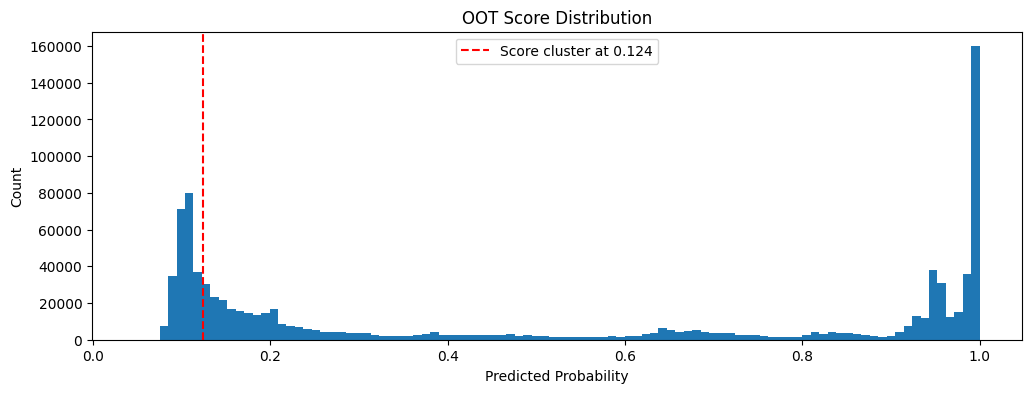

% OOT loans in 0.120-0.130 band: 4.58%


In [32]:
# Distribution of scores to visualize the clustering
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.hist(model_combined.predict_proba(X_oot)[:, 1], bins=100, edgecolor='none')
plt.axvline(0.124, color='red', linestyle='--', label='Score cluster at 0.124')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('OOT Score Distribution')
plt.legend()
plt.show()

# What % of OOT loans are in the cluster
oot_scores = model_combined.predict_proba(X_oot)[:, 1]
cluster = ((oot_scores >= 0.120) & (oot_scores <= 0.130)).mean()
print(f"% OOT loans in 0.120-0.130 band: {cluster:.2%}")

In [33]:
# Profile the loans in the 0.124 cluster
oot_scores = model_combined.predict_proba(X_oot)[:, 1]
cluster_mask = (oot_scores >= 0.120) & (oot_scores <= 0.130)

print(f"Loans in cluster    : {cluster_mask.sum():,}  ({cluster_mask.mean():.1%} of OOT)")
print(f"Bounce rate in cluster: {y_oot[cluster_mask].mean():.2%}")

print("\nFeature means — cluster vs rest:")
print(pd.concat([
    X_oot[cluster_mask].mean().rename('cluster_0.124'),
    X_oot[~cluster_mask].mean().rename('rest'),
], axis=1).round(3))

Loans in cluster    : 43,395  (4.6% of OOT)
Bounce rate in cluster: 3.68%

Feature means — cluster vs rest:
                                       cluster_0.124   rest
bounces_last_30d                               0.000  0.449
bounces_last_60d                               0.000  0.888
bounces_last_90d                               0.000  1.308
bounces_last_180d                              0.000  2.506
bounces_last_270d                              0.061  3.476
...                                              ...    ...
total_loan_count_12m_coapplicant               4.405  5.987
collateral_loan_pct_12m_coapplicant            0.437  0.577
collateral_loan_count_24m_coapplicant          2.600  3.519
total_loan_count_24m_coapplicant               5.657  7.816
collateral_loan_pct_24m_coapplicant            0.421  0.557

[89 rows x 2 columns]


In [34]:
# Profile the high-score cluster
high_mask = oot_scores >= 0.95
print(f"\nLoans scoring >= 0.95 : {high_mask.sum():,}  ({high_mask.mean():.1%} of OOT)")
print(f"Bounce rate          : {y_oot[high_mask].mean():.2%}")

print("\nFeature means — high score loans:")
print(X_oot[high_mask][['bounces_last_30d', 'bounces_last_60d',
                          'ever_90_above_dpd_12m_all',
                          'percent_90_above_dpd_12m_all_Agg_month']].mean().round(3))
# ```

# These are chronic bouncers — `bounces_last_30d` is high AND bureau shows 90+ DPD history. The model is correctly near-certain on both groups.

# ---

### Is this a problem?

# **No — it's actually good.** The bimodal distribution means:
# ```
# Portfolio naturally separates into 3 groups:

# 1. Definite bouncers  (score > 0.95) → ~20% of portfolio, >99% bounce rate
#    → Collections team should focus here

# 2. Uncertain middle   (score 0.13-0.95) → ~30% of portfolio
#    → Needs monitoring

# 3. Zero-risk cluster  (score ~0.124) → ~50% of portfolio, very low bounce rate
#    → Leave alone, no intervention needed


Loans scoring >= 0.95 : 264,106  (27.9% of OOT)
Bounce rate          : 97.68%

Feature means — high score loans:
bounces_last_30d                          1.000
bounces_last_60d                          1.998
ever_90_above_dpd_12m_all                 0.498
percent_90_above_dpd_12m_all_Agg_month    0.191
dtype: float64


In [35]:
# Check the 3% non-bounces in the high score group
high_mask = oot_scores >= 0.95
non_bounce_high = X_oot[high_mask][y_oot[high_mask] == 0]
print(f"Non-bounces in high score group: {len(non_bounce_high):,}")
print(f"\nFeature means — false positives:")
print(non_bounce_high[['bounces_last_30d', 'bounces_last_60d',
                         'bounces_last_90d', 'ever_90_above_dpd_12m_all',
                         'percent_90_above_dpd_12m_all_Agg_month']].mean().round(3))

Non-bounces in high score group: 6,130

Feature means — false positives:
bounces_last_30d                          1.000
bounces_last_60d                          1.989
bounces_last_90d                          2.926
ever_90_above_dpd_12m_all                 0.423
percent_90_above_dpd_12m_all_Agg_month    0.122
dtype: float64


In [36]:
# These false positives — check their bounce history in model_df
false_pos_loans = oot_df[high_mask][y_oot[high_mask] == 0]['masked_loan_id']

# Look at their full 12-month bounce history
print("Bounce history of false positives across all months:")
print(
    model_df_final[model_df_final['masked_loan_id'].isin(false_pos_loans)]
    .groupby('as_of_month')['target_bounce']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'bounce_rate', 'count': 'n'})
    .round(3)
)

# Also check — do they bounce in surrounding months?
print("\nFor one sample loan — full year bounce pattern:")
sample = false_pos_loans.iloc[0]
print(
    model_df_final[model_df_final['masked_loan_id'] == sample]
    [['as_of_month', 'target_bounce', 'bounces_last_30d', 'bounces_last_60d']]
    .sort_values('as_of_month')
    .to_string(index=False)
)

Bounce history of false positives across all months:
             bounce_rate     n
as_of_month                   
1                  0.675  5861
2                  0.652  5938
3                  0.665  6006
4                  0.747  6045
5                  0.802  6084
6                  0.853  6111
7                  0.868  6113
8                  0.906  6125
9                  0.962  6129
10                 0.997  6129
11                 0.509  6130
12                 0.252  5950

For one sample loan — full year bounce pattern:
 as_of_month  target_bounce  bounces_last_30d  bounces_last_60d
           1              0               0.0               0.0
           2              1               0.0               0.0
           3              1               1.0               1.0
           4              1               1.0               2.0
           5              1               1.0               2.0
           6              0               1.0               2.0
           7    

# Modeling only with cibil variables

In [101]:
# ============================================================
# BUREAU-ONLY FEATURE COLS
# ============================================================
bureau_feature_cols = [
    # Ever DPD - 12m
    'ever_1_30_dpd_12m_all', 'ever_30_90_dpd_12m_all', 'ever_90_above_dpd_12m_all',
    'ever_1_30_dpd_12m_secured', 'ever_30_90_dpd_12m_secured', 'ever_90_above_dpd_12m_secured',
    'ever_1_30_dpd_12m_unsecured', 'ever_30_90_dpd_12m_unsecured', 'ever_90_above_dpd_12m_unsecured',
    # Ever DPD - 24m
    'ever_1_30_dpd_24m_all', 'ever_30_90_dpd_24m_all', 'ever_90_above_dpd_24m_all',
    'ever_1_30_dpd_24m_secured', 'ever_30_90_dpd_24m_secured', 'ever_90_above_dpd_24m_secured',
    'ever_1_30_dpd_24m_unsecured', 'ever_30_90_dpd_24m_unsecured', 'ever_90_above_dpd_24m_unsecured',
    # Percent DPD - 12m
    'percent_1_30_dpd_12m_all_Agg_month', 'percent_30_90_dpd_12m_all_Agg_month', 'percent_90_above_dpd_12m_all_Agg_month',
    'percent_1_30_dpd_12m_secured_Agg_month', 'percent_30_90_dpd_12m_secured_Agg_month', 'percent_90_above_dpd_12m_secured_Agg_month',
    'percent_1_30_dpd_12m_unsecured_Agg_month', 'percent_30_90_dpd_12m_unsecured_Agg_month', 'percent_90_above_dpd_12m_unsecured_Agg_month',
    # Percent DPD - 24m
    'percent_1_30_dpd_24m_all_Agg_month', 'percent_30_90_dpd_24m_all_Agg_month', 'percent_90_above_dpd_24m_all_Agg_month',
    'percent_1_30_dpd_24m_secured_Agg_month', 'percent_30_90_dpd_24m_secured_Agg_month', 'percent_90_above_dpd_24m_secured_Agg_month',
    'percent_1_30_dpd_24m_unsecured_Agg_month', 'percent_30_90_dpd_24m_unsecured_Agg_month', 'percent_90_above_dpd_24m_unsecured_Agg_month',
    # Collateral
    'collateral_loan_count_12m', 'total_loan_count_12m', 'collateral_loan_pct_12m',
    'collateral_loan_count_24m', 'total_loan_count_24m', 'collateral_loan_pct_24m',
]

# ============================================================
# SAME TIME-BASED SPLIT
# ============================================================
X_train_b = train_df[bureau_feature_cols]
y_train_b  = train_df['target_bounce']
X_test_b   = test_df[bureau_feature_cols]
y_test_b   = test_df['target_bounce']
X_oot_b    = oot_df[bureau_feature_cols]
y_oot_b    = oot_df['target_bounce']

print(f"Train : {X_train_b.shape} | bounce rate: {y_train_b.mean():.2%}")
print(f"Test  : {X_test_b.shape}  | bounce rate: {y_test_b.mean():.2%}")
print(f"OOT   : {X_oot_b.shape}   | bounce rate: {y_oot_b.mean():.2%}")

# ============================================================
# TRAIN BUREAU-ONLY MODEL
# ============================================================
model_bureau = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train_b == 0).sum() / (y_train_b == 1).sum(),
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

model_bureau.fit(
    X_train_b, y_train_b,
    eval_set=[(X_train_b, y_train_b), (X_test_b, y_test_b)],
    verbose=False
)

# ============================================================
# EVALUATE
# ============================================================
evaluate("TRAIN — Bureau Only", y_train_b, model_bureau.predict_proba(X_train_b)[:, 1])
evaluate("TEST  — Bureau Only", y_test_b,  model_bureau.predict_proba(X_test_b)[:, 1])
evaluate("OOT   — Bureau Only", y_oot_b,   model_bureau.predict_proba(X_oot_b)[:, 1])

print("\nOOT AUC by month — Bureau Only:")
for month in [11, 12]:
    mask = oot_df['as_of_month'] == month
    auc  = roc_auc_score(y_oot_b[mask], model_bureau.predict_proba(X_oot_b[mask])[:, 1])
    print(f"  Month {month}: AUC = {auc:.4f}  (n={mask.sum():,})")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
feat_imp_bureau = (
    pd.Series(model_bureau.feature_importances_, index=bureau_feature_cols)
    .sort_values(ascending=False)
)
print("\nTop 15 features — Bureau Only:")
print(feat_imp_bureau.head(15).round(4))

# ============================================================
# COMPARISON TABLE
# ============================================================
print("\n" + "="*55)
print("MODEL COMPARISON SUMMARY")
print("="*55)

results = {
    'Bounce Only': {
        'train': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),   # from notebook earlier
        'test' : roc_auc_score(y_test,  model.predict_proba(X_test)[:, 1]),
        'oot'  : roc_auc_score(y_oot,   model.predict_proba(X_oot)[:, 1]),
    },
    'Bureau Only': {
        'train': roc_auc_score(y_train_b, model_bureau.predict_proba(X_train_b)[:, 1]),
        'test' : roc_auc_score(y_test_b,  model_bureau.predict_proba(X_test_b)[:, 1]),
        'oot'  : roc_auc_score(y_oot_b,   model_bureau.predict_proba(X_oot_b)[:, 1]),
    },
    'Bounce + Bureau': {
        'train': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        'test' : roc_auc_score(y_test,  model.predict_proba(X_test)[:, 1]),
        'oot'  : roc_auc_score(y_oot,   model.predict_proba(X_oot)[:, 1]),
    },
}

print(f"\n{'Model':<20} {'Train':>8} {'Test':>8} {'OOT':>8}")
print("-" * 46)
for name, aucs in results.items():
    print(f"{name:<20} {aucs['train']:>8.4f} {aucs['test']:>8.4f} {aucs['oot']:>8.4f}")

Train : (3586061, 42) | bounce rate: 40.44%
Test  : (938078, 42)  | bounce rate: 43.12%
OOT   : (947386, 42)   | bounce rate: 42.72%

  TRAIN — Bureau Only
  AUC-ROC : 0.7778
  AUC-PR  : 0.7734
              precision    recall  f1-score   support

   No Bounce       0.75      0.88      0.81   2135841
      Bounce       0.77      0.57      0.66   1450220

    accuracy                           0.76   3586061
   macro avg       0.76      0.73      0.73   3586061
weighted avg       0.76      0.76      0.75   3586061


  TEST  — Bureau Only
  AUC-ROC : 0.8002
  AUC-PR  : 0.8092
              precision    recall  f1-score   support

   No Bounce       0.75      0.87      0.81    533557
      Bounce       0.78      0.62      0.69    404521

    accuracy                           0.76    938078
   macro avg       0.77      0.74      0.75    938078
weighted avg       0.76      0.76      0.76    938078


  OOT   — Bureau Only
  AUC-ROC : 0.8103
  AUC-PR  : 0.8167
              precision    rec

In [37]:
# ============================================================
# BUREAU ONLY — PRIMARY + CO-APPLICANT
# ============================================================

# Primary bureau features only (no bounce history)
bureau_primary_cols = [
    # Ever DPD - 12m
    'ever_1_30_dpd_12m_all', 'ever_30_90_dpd_12m_all', 'ever_90_above_dpd_12m_all',
    'ever_1_30_dpd_12m_secured', 'ever_30_90_dpd_12m_secured', 'ever_90_above_dpd_12m_secured',
    'ever_1_30_dpd_12m_unsecured', 'ever_30_90_dpd_12m_unsecured', 'ever_90_above_dpd_12m_unsecured',
    # Ever DPD - 24m
    'ever_1_30_dpd_24m_all', 'ever_30_90_dpd_24m_all', 'ever_90_above_dpd_24m_all',
    'ever_1_30_dpd_24m_secured', 'ever_30_90_dpd_24m_secured', 'ever_90_above_dpd_24m_secured',
    'ever_1_30_dpd_24m_unsecured', 'ever_30_90_dpd_24m_unsecured', 'ever_90_above_dpd_24m_unsecured',
    # Percent DPD - 12m
    'percent_1_30_dpd_12m_all_Agg_month', 'percent_30_90_dpd_12m_all_Agg_month', 'percent_90_above_dpd_12m_all_Agg_month',
    'percent_1_30_dpd_12m_secured_Agg_month', 'percent_30_90_dpd_12m_secured_Agg_month', 'percent_90_above_dpd_12m_secured_Agg_month',
    'percent_1_30_dpd_12m_unsecured_Agg_month', 'percent_30_90_dpd_12m_unsecured_Agg_month', 'percent_90_above_dpd_12m_unsecured_Agg_month',
    # Percent DPD - 24m
    'percent_1_30_dpd_24m_all_Agg_month', 'percent_30_90_dpd_24m_all_Agg_month', 'percent_90_above_dpd_24m_all_Agg_month',
    'percent_1_30_dpd_24m_secured_Agg_month', 'percent_30_90_dpd_24m_secured_Agg_month', 'percent_90_above_dpd_24m_secured_Agg_month',
    'percent_1_30_dpd_24m_unsecured_Agg_month', 'percent_30_90_dpd_24m_unsecured_Agg_month', 'percent_90_above_dpd_24m_unsecured_Agg_month',
    # Collateral
    'collateral_loan_count_12m', 'total_loan_count_12m', 'collateral_loan_pct_12m',
    'collateral_loan_count_24m', 'total_loan_count_24m', 'collateral_loan_pct_24m',
]

# Co-applicant bureau features
bureau_coapp_cols = [c + '_coapplicant' for c in bureau_primary_cols
                     if c + '_coapplicant' in model_df_final_combined.columns]

# Combined bureau only (primary + coapp, no bounce)
bureau_combined_cols = [c for c in bureau_primary_cols + bureau_coapp_cols
                        if c in model_df_final_combined.columns]

print(f"Bureau primary cols : {len(bureau_primary_cols)}")
print(f"Bureau coapp cols   : {len(bureau_coapp_cols)}")
print(f"Bureau combined cols: {len(bureau_combined_cols)}")

# ============================================================
# SPLITS — from model_df_final_combined
# ============================================================
train_df = model_df_final_combined[model_df_final_combined['as_of_month'] <= 8]
test_df  = model_df_final_combined[model_df_final_combined['as_of_month'].isin([9, 10])]
oot_df   = model_df_final_combined[model_df_final_combined['as_of_month'].isin([11, 12])]

y_train = train_df['target_bounce']
y_test  = test_df['target_bounce']
y_oot   = oot_df['target_bounce']

print(f"\nTrain : {train_df.shape} | bounce rate: {y_train.mean():.2%}")
print(f"Test  : {test_df.shape}  | bounce rate: {y_test.mean():.2%}")
print(f"OOT   : {oot_df.shape}   | bounce rate: {y_oot.mean():.2%}")

# ============================================================
# MODEL 1: Bureau Primary Only
# ============================================================
print("\nTraining Bureau Primary Only...")
X_train_bp = train_df[bureau_primary_cols]
X_test_bp  = test_df[bureau_primary_cols]
X_oot_bp   = oot_df[bureau_primary_cols]

model_bureau_primary = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric='auc', use_label_encoder=False
)
model_bureau_primary.fit(
    X_train_bp, y_train,
    eval_set=[(X_train_bp, y_train), (X_test_bp, y_test)],
    verbose=False
)
evaluate("TRAIN — Bureau Primary Only", y_train, model_bureau_primary.predict_proba(X_train_bp)[:, 1])
evaluate("TEST  — Bureau Primary Only", y_test,  model_bureau_primary.predict_proba(X_test_bp)[:, 1])
evaluate("OOT   — Bureau Primary Only", y_oot,   model_bureau_primary.predict_proba(X_oot_bp)[:, 1])

# ============================================================
# MODEL 2: Bureau Co-applicant Only
# ============================================================
print("\nTraining Bureau Co-applicant Only...")
X_train_bc = train_df[bureau_coapp_cols]
X_test_bc  = test_df[bureau_coapp_cols]
X_oot_bc   = oot_df[bureau_coapp_cols]

model_bureau_coapp = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric='auc', use_label_encoder=False
)
model_bureau_coapp.fit(
    X_train_bc, y_train,
    eval_set=[(X_train_bc, y_train), (X_test_bc, y_test)],
    verbose=False
)
evaluate("TRAIN — Bureau Coapp Only", y_train, model_bureau_coapp.predict_proba(X_train_bc)[:, 1])
evaluate("TEST  — Bureau Coapp Only", y_test,  model_bureau_coapp.predict_proba(X_test_bc)[:, 1])
evaluate("OOT   — Bureau Coapp Only", y_oot,   model_bureau_coapp.predict_proba(X_oot_bc)[:, 1])

# ============================================================
# MODEL 3: Bureau Primary + Co-applicant Combined
# ============================================================
print("\nTraining Bureau Primary + Co-applicant Combined...")
X_train_bcomb = train_df[bureau_combined_cols]
X_test_bcomb  = test_df[bureau_combined_cols]
X_oot_bcomb   = oot_df[bureau_combined_cols]

model_bureau_combined = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric='auc', use_label_encoder=False
)
model_bureau_combined.fit(
    X_train_bcomb, y_train,
    eval_set=[(X_train_bcomb, y_train), (X_test_bcomb, y_test)],
    verbose=False
)
evaluate("TRAIN — Bureau Primary + Coapp", y_train, model_bureau_combined.predict_proba(X_train_bcomb)[:, 1])
evaluate("TEST  — Bureau Primary + Coapp", y_test,  model_bureau_combined.predict_proba(X_test_bcomb)[:, 1])
evaluate("OOT   — Bureau Primary + Coapp", y_oot,   model_bureau_combined.predict_proba(X_oot_bcomb)[:, 1])

# ============================================================
# FEATURE IMPORTANCE — Bureau Primary + Coapp
# ============================================================
feat_imp_bureau_comb = (
    pd.Series(model_bureau_combined.feature_importances_, index=bureau_combined_cols)
    .sort_values(ascending=False)
)
print("\nTop 20 features — Bureau Primary + Coapp:")
print(feat_imp_bureau_comb.head(20).round(4))

print("\nTop 10 co-applicant features:")
print(feat_imp_bureau_comb[
    feat_imp_bureau_comb.index.str.endswith('_coapplicant')
].head(10).round(4))

# ============================================================
# COMPARISON TABLE — ALL MODELS
# ============================================================
print(f"\n{'='*65}")
print("MODEL COMPARISON SUMMARY — CIBIL VARIABLES")
print(f"{'='*65}")
print(f"\n{'Model':<35} {'Train':>8} {'Test':>8} {'OOT':>8}")
print("-" * 61)

all_models = {
    'Bureau Primary Only'       : (model_bureau_primary,  X_train_bp,    X_test_bp,    X_oot_bp),
    'Bureau Coapp Only'         : (model_bureau_coapp,    X_train_bc,    X_test_bc,    X_oot_bc),
    'Bureau Primary + Coapp'    : (model_bureau_combined, X_train_bcomb, X_test_bcomb, X_oot_bcomb),
}

for name, (mdl, Xtr, Xte, Xoo) in all_models.items():
    tr = roc_auc_score(y_train, mdl.predict_proba(Xtr)[:, 1])
    te = roc_auc_score(y_test,  mdl.predict_proba(Xte)[:, 1])
    oo = roc_auc_score(y_oot,   mdl.predict_proba(Xoo)[:, 1])
    print(f"{name:<35} {tr:>8.4f} {te:>8.4f} {oo:>8.4f}")

# OOT by month
print(f"\n{'='*65}")
print("OOT AUC by Month")
print(f"{'='*65}")
print(f"\n{'Model':<35} {'Nov':>8} {'Dec':>8}")
print("-" * 53)

for name, (mdl, Xtr, Xte, Xoo) in all_models.items():
    nov_mask = oot_df['as_of_month'] == 11
    dec_mask = oot_df['as_of_month'] == 12
    nov = roc_auc_score(y_oot[nov_mask], mdl.predict_proba(Xoo[nov_mask])[:, 1])
    dec = roc_auc_score(y_oot[dec_mask], mdl.predict_proba(Xoo[dec_mask])[:, 1])
    print(f"{name:<35} {nov:>8.4f} {dec:>8.4f}")

Bureau primary cols : 42
Bureau coapp cols   : 42
Bureau combined cols: 84

Train : (3586061, 95) | bounce rate: 40.44%
Test  : (938078, 95)  | bounce rate: 43.12%
OOT   : (947386, 95)   | bounce rate: 42.72%

Training Bureau Primary Only...

  TRAIN — Bureau Primary Only
  AUC-ROC : 0.7778
  AUC-PR  : 0.7734
              precision    recall  f1-score   support

   No Bounce       0.75      0.88      0.81   2135841
      Bounce       0.77      0.57      0.66   1450220

    accuracy                           0.76   3586061
   macro avg       0.76      0.73      0.73   3586061
weighted avg       0.76      0.76      0.75   3586061


  TEST  — Bureau Primary Only
  AUC-ROC : 0.8002
  AUC-PR  : 0.8092
              precision    recall  f1-score   support

   No Bounce       0.75      0.87      0.81    533557
      Bounce       0.78      0.62      0.69    404521

    accuracy                           0.76    938078
   macro avg       0.77      0.74      0.75    938078
weighted avg       0.

In [84]:
from IPython.display import display
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

def decile_table_display(y_true, y_prob, label=''):
    df = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob})

    df['decile'] = pd.qcut(df['y_prob'].rank(method='first'), q=10, labels=False)
    df['decile'] = 9 - df['decile']

    tbl = (
        df.groupby('decile')
        .agg(
            Bads      = ('y_true', 'sum'),
            Total     = ('y_true', 'count'),
            min_score = ('y_prob', 'min'),
            max_score = ('y_prob', 'max'),
        )
        .reset_index()
    )

    total_goods = (tbl['Total'] - tbl['Bads']).sum()
    total_bads  = tbl['Bads'].sum()
    auc_val     = round(roc_auc_score(y_true, y_prob) * 100, 2)

    tbl['Goods']     = tbl['Total'] - tbl['Bads']
    tbl['Bad_Rate']  = (tbl['Bads'] / tbl['Total'] * 100).round(2).astype(str) + '%'
    tbl['pct_loans'] = (tbl['Total'] / tbl['Total'].sum() * 100).round(2)
    tbl['pct_goods'] = (tbl['Goods'] / total_goods * 100).round(2)
    tbl['pct_bads']  = (tbl['Bads']  / total_bads  * 100).round(2)
    tbl['cum_goods'] = tbl['pct_goods'].cumsum().round(2)
    tbl['cum_bads']  = tbl['pct_bads'].cumsum().round(2)
    tbl['KS']        = (tbl['cum_goods'] - tbl['cum_bads']).abs().round(2)
    tbl['Score_Band']= tbl.apply(
        lambda r: f"({r['min_score']:.3f}, {r['max_score']:.3f}]", axis=1
    )
    tbl['Band_no']   = tbl['decile'] + 1
    tbl['AUC']       = auc_val

    display_tbl = tbl[[
        'Band_no', 'Score_Band', 'Goods', 'Bads', 'Total',
        'Bad_Rate', 'pct_loans', 'pct_goods', 'pct_bads',
        'cum_goods', 'cum_bads', 'KS', 'AUC'
    ]].copy()

    display_tbl.columns = [
        'Band no', 'Score Band', 'Goods', 'Bads', 'Total',
        'Bad rate', '% Loans', '% Goods', '% Bads',
        'Cumm goods %', 'Cumm bads %', 'KS', 'AUC'
    ]

    print(f"\nDecile Table — {label}")
    display(display_tbl.style.hide(axis='index').set_caption(label))
    return display_tbl


# ============================================================
# BOUNCE + BUREAU MODEL
# ============================================================
train_probs = model.predict_proba(X_train)[:, 1]
test_probs  = model.predict_proba(X_test)[:, 1]
oot_probs   = model.predict_proba(X_oot)[:, 1]
oot1_mask   = oot_df['as_of_month'] == 11
oot2_mask   = oot_df['as_of_month'] == 12

train_decile  = decile_table_display(y_train,          train_probs,           label='Train — Bounce + Bureau')
test_decile   = decile_table_display(y_test,           test_probs,            label='Test  — Bounce + Bureau')
oot_decile    = decile_table_display(y_oot,            oot_probs,             label='OOT   — Bounce + Bureau (Nov+Dec)')
oot1_decile   = decile_table_display(y_oot[oot1_mask], oot_probs[oot1_mask],  label='OOT1  — Bounce + Bureau (Nov 2025)')
oot2_decile   = decile_table_display(y_oot[oot2_mask], oot_probs[oot2_mask],  label='OOT2  — Bounce + Bureau (Dec 2025)')

# ============================================================
# BUREAU ONLY MODEL
# ============================================================
bureau_train_probs = model_bureau.predict_proba(X_train_b)[:, 1]
bureau_test_probs  = model_bureau.predict_proba(X_test_b)[:, 1]
bureau_oot_probs   = model_bureau.predict_proba(X_oot_b)[:, 1]

bureau_train_decile = decile_table_display(y_train_b,          bureau_train_probs,          label='Train — Bureau Only')
bureau_test_decile  = decile_table_display(y_test_b,           bureau_test_probs,           label='Test  — Bureau Only')
bureau_oot_decile   = decile_table_display(y_oot_b,            bureau_oot_probs,            label='OOT   — Bureau Only (Nov+Dec)')
bureau_oot1_decile  = decile_table_display(y_oot_b[oot1_mask], bureau_oot_probs[oot1_mask], label='OOT1  — Bureau Only (Nov 2025)')
bureau_oot2_decile  = decile_table_display(y_oot_b[oot2_mask], bureau_oot_probs[oot2_mask], label='OOT2  — Bureau Only (Dec 2025)')

# ============================================================
# BOUNCE ONLY MODEL
# ============================================================
bounce_train_probs = model_bounce.predict_proba(train_df[bounce_feature_cols])[:, 1]
bounce_test_probs  = model_bounce.predict_proba(test_df[bounce_feature_cols])[:, 1]
bounce_oot_probs   = model_bounce.predict_proba(oot_df[bounce_feature_cols])[:, 1]

bounce_train_decile = decile_table_display(y_train,          bounce_train_probs,           label='Train — Bounce Only')
bounce_test_decile  = decile_table_display(y_test,           bounce_test_probs,            label='Test  — Bounce Only')
bounce_oot_decile   = decile_table_display(y_oot,            bounce_oot_probs,             label='OOT   — Bounce Only (Nov+Dec)')
bounce_oot1_decile  = decile_table_display(y_oot[oot1_mask], bounce_oot_probs[oot1_mask],  label='OOT1  — Bounce Only (Nov 2025)')
bounce_oot2_decile  = decile_table_display(y_oot[oot2_mask], bounce_oot_probs[oot2_mask],  label='OOT2  — Bounce Only (Dec 2025)')

# ============================================================
# OOT COMPARISON — ALL THREE MODELS
# ============================================================
print("\nOOT Comparison — Bounce Only vs Bureau Only vs Bounce + Bureau")

comparison = pd.DataFrame({
    'Band no'               : oot_decile['Band no'],
    'Bad rate (Bounce)'     : bounce_oot_decile['Bad rate'],
    'Bad rate (Bureau)'     : bureau_oot_decile['Bad rate'],
    'Bad rate (Combined)'   : oot_decile['Bad rate'],
    'KS (Bounce)'           : bounce_oot_decile['KS'],
    'KS (Bureau)'           : bureau_oot_decile['KS'],
    'KS (Combined)'         : oot_decile['KS'],
    'Cumm Bads% (Bounce)'   : bounce_oot_decile['Cumm bads %'],
    'Cumm Bads% (Bureau)'   : bureau_oot_decile['Cumm bads %'],
    'Cumm Bads% (Combined)' : oot_decile['Cumm bads %'],
    'AUC (Bounce)'          : bounce_oot_decile['AUC'],
    'AUC (Bureau)'          : bureau_oot_decile['AUC'],
    'AUC (Combined)'        : oot_decile['AUC'],
})
display(comparison.style.hide(axis='index')
        .set_caption("OOT Comparison — Bounce Only vs Bureau Only vs Bounce + Bureau"))

# ============================================================
# SUMMARY — MAX KS AND AUC PER MODEL PER SPLIT
# ============================================================
print("\nSummary — Max KS and AUC per Model per Split")

summary = pd.DataFrame({
    'Split'        : ['Train', 'Test', 'OOT', 'OOT1 (Nov)', 'OOT2 (Dec)'],
    'KS (Bounce)'  : [bounce_train_decile['KS'].max(), bounce_test_decile['KS'].max(),
                      bounce_oot_decile['KS'].max(),   bounce_oot1_decile['KS'].max(),
                      bounce_oot2_decile['KS'].max()],
    'KS (Bureau)'  : [bureau_train_decile['KS'].max(), bureau_test_decile['KS'].max(),
                      bureau_oot_decile['KS'].max(),   bureau_oot1_decile['KS'].max(),
                      bureau_oot2_decile['KS'].max()],
    'KS (Combined)': [train_decile['KS'].max(), test_decile['KS'].max(),
                      oot_decile['KS'].max(),   oot1_decile['KS'].max(),
                      oot2_decile['KS'].max()],
    'AUC (Bounce)' : [bounce_train_decile['AUC'].iloc[0], bounce_test_decile['AUC'].iloc[0],
                      bounce_oot_decile['AUC'].iloc[0],   bounce_oot1_decile['AUC'].iloc[0],
                      bounce_oot2_decile['AUC'].iloc[0]],
    'AUC (Bureau)' : [bureau_train_decile['AUC'].iloc[0], bureau_test_decile['AUC'].iloc[0],
                      bureau_oot_decile['AUC'].iloc[0],   bureau_oot1_decile['AUC'].iloc[0],
                      bureau_oot2_decile['AUC'].iloc[0]],
    'AUC (Combined)': [train_decile['AUC'].iloc[0], test_decile['AUC'].iloc[0],
                       oot_decile['AUC'].iloc[0],   oot1_decile['AUC'].iloc[0],
                       oot2_decile['AUC'].iloc[0]],
})
display(summary.style.hide(axis='index')
        .set_caption("Summary — Max KS and AUC per Model per Split"))


Decile Table — Train — Bounce + Bureau


Band no,Score Band,Goods,Bads,Total,Bad rate,% Loans,% Goods,% Bads,Cumm goods %,Cumm bads %,KS,AUC
1,"(0.988, 1.000]",1221,357385,358606,99.66%,10.000000,0.060000,24.640000,0.060000,24.640000,24.580000,91.230000
2,"(0.938, 0.988]",15382,343224,358606,95.71%,10.000000,0.720000,23.670000,0.780000,48.310000,47.530000,91.230000
3,"(0.775, 0.938]",59108,299498,358606,83.52%,10.000000,2.770000,20.650000,3.550000,68.960000,65.410000,91.230000
4,"(0.448, 0.775]",159915,198691,358606,55.41%,10.000000,7.490000,13.700000,11.040000,82.660000,71.620000,91.230000
5,"(0.225, 0.448]",271205,87401,358606,24.37%,10.000000,12.700000,6.030000,23.740000,88.690000,64.950000,91.230000
6,"(0.136, 0.225]",313286,45320,358606,12.64%,10.000000,14.670000,3.130000,38.410000,91.820000,53.410000,91.230000
7,"(0.125, 0.136]",326948,31658,358606,8.83%,10.000000,15.310000,2.180000,53.720000,94.000000,40.280000,91.230000
8,"(0.124, 0.125]",339756,18850,358606,5.26%,10.000000,15.910000,1.300000,69.630000,95.300000,25.670000,91.230000
9,"(0.116, 0.124]",317772,40834,358606,11.39%,10.000000,14.880000,2.820000,84.510000,98.120000,13.610000,91.230000
10,"(0.069, 0.116]",331248,27359,358607,7.63%,10.000000,15.510000,1.890000,100.020000,100.010000,0.010000,91.230000



Decile Table — Test  — Bounce + Bureau


Band no,Score Band,Goods,Bads,Total,Bad rate,% Loans,% Goods,% Bads,Cumm goods %,Cumm bads %,KS,AUC
1,"(0.995, 1.000]",167,93641,93808,99.82%,10.000000,0.030000,23.150000,0.030000,23.150000,23.120000,95.150000
2,"(0.980, 0.995]",1344,92464,93808,98.57%,10.000000,0.250000,22.860000,0.280000,46.010000,45.730000,95.150000
3,"(0.942, 0.980]",6278,87530,93808,93.31%,10.000000,1.180000,21.640000,1.460000,67.650000,66.190000,95.150000
4,"(0.686, 0.942]",26690,67117,93807,71.55%,10.000000,5.000000,16.590000,6.460000,84.240000,77.780000,95.150000
5,"(0.354, 0.686]",59077,34731,93808,37.02%,10.000000,11.070000,8.590000,17.530000,92.830000,75.300000,95.150000
6,"(0.195, 0.354]",80719,13089,93808,13.95%,10.000000,15.130000,3.240000,32.660000,96.070000,63.410000,95.150000
7,"(0.126, 0.195]",88001,5806,93807,6.19%,10.000000,16.490000,1.440000,49.150000,97.510000,48.360000,95.150000
8,"(0.124, 0.126]",90085,3723,93808,3.97%,10.000000,16.880000,0.920000,66.030000,98.430000,32.400000,95.150000
9,"(0.116, 0.124]",90288,3520,93808,3.75%,10.000000,16.920000,0.870000,82.950000,99.300000,16.350000,95.150000
10,"(0.072, 0.116]",90908,2900,93808,3.09%,10.000000,17.040000,0.720000,99.990000,100.020000,0.030000,95.150000



Decile Table — OOT   — Bounce + Bureau (Nov+Dec)


...

Band no,Score Band,Goods,Bads,Total,Bad rate,% Loans,% Goods,% Bads,Cumm goods %,Cumm bads %,KS,AUC
1,"(0.987, 0.987]",1419,45935,47354,97.0%,10.000000,0.520000,22.750000,0.520000,22.750000,22.230000,95.230000
2,"(0.987, 0.987]",879,46475,47354,98.14%,10.000000,0.320000,23.020000,0.840000,45.770000,44.930000,95.230000
3,"(0.958, 0.987]",2478,44875,47353,94.77%,10.000000,0.910000,22.230000,1.750000,68.000000,66.250000,95.230000
4,"(0.788, 0.958]",13678,33676,47354,71.12%,10.000000,5.040000,16.680000,6.790000,84.680000,77.890000,95.230000
5,"(0.374, 0.788]",28361,18992,47353,40.11%,10.000000,10.440000,9.410000,17.230000,94.090000,76.860000,95.230000
6,"(0.182, 0.374]",42489,4865,47354,10.27%,10.000000,15.640000,2.410000,32.870000,96.500000,63.630000,95.230000
7,"(0.182, 0.182]",45496,1858,47354,3.92%,10.000000,16.750000,0.920000,49.620000,97.420000,47.800000,95.230000
8,"(0.182, 0.182]",45724,1629,47353,3.44%,10.000000,16.830000,0.810000,66.450000,98.230000,31.780000,95.230000
9,"(0.182, 0.182]",45954,1400,47354,2.96%,10.000000,16.920000,0.690000,83.370000,98.920000,15.550000,95.230000
10,"(0.182, 0.182]",45180,2174,47354,4.59%,10.000000,16.630000,1.080000,100.000000,100.000000,0.000000,95.230000



OOT Comparison — Bounce Only vs Bureau Only vs Bounce + Bureau


Band no,Bad rate (Bounce),Bad rate (Bureau),Bad rate (Combined),KS (Bounce),KS (Bureau),KS (Combined),Cumm Bads% (Bounce),Cumm Bads% (Bureau),Cumm Bads% (Combined),AUC (Bounce),AUC (Bureau),AUC (Combined)
1,97.57%,99.59%,99.78%,22.420000,23.240000,23.320000,22.840000,23.310000,23.360000,95.150000,81.030000,95.620000
2,97.62%,89.46%,98.52%,44.850000,42.340000,46.120000,45.690000,44.250000,46.420000,95.150000,81.030000,95.620000
3,94.45%,61.91%,93.13%,65.990000,50.180000,66.720000,67.800000,58.740000,68.220000,95.150000,81.030000,95.620000
4,70.99%,40.01%,72.23%,77.540000,49.080000,78.780000,84.420000,68.110000,85.130000,95.150000,81.030000,95.620000
5,40.98%,29.7%,36.86%,76.830000,43.760000,76.390000,94.010000,75.060000,93.760000,95.150000,81.030000,95.620000
6,10.23%,25.78%,12.5%,63.550000,36.830000,64.040000,96.400000,81.090000,96.690000,95.150000,81.030000,95.620000
7,3.63%,24.24%,5.21%,47.580000,29.270000,48.710000,97.250000,86.760000,97.910000,95.150000,81.030000,95.620000
8,3.75%,21.78%,3.28%,31.660000,20.710000,32.590000,98.130000,91.860000,98.680000,95.150000,81.030000,95.620000
9,3.84%,19.31%,3.16%,15.770000,11.140000,16.420000,99.030000,96.380000,99.420000,95.150000,81.030000,95.620000
10,4.13%,15.42%,2.53%,0.000000,0.020000,0.010000,100.000000,99.990000,100.010000,95.150000,81.030000,95.620000



Summary — Max KS and AUC per Model per Split


Split,KS (Bounce),KS (Bureau),KS (Combined),AUC (Bounce),AUC (Bureau),AUC (Combined)
Train,67.250000,45.410000,71.620000,87.180000,77.780000,91.230000
Test,76.760000,48.570000,77.780000,94.640000,80.020000,95.150000
OOT,77.540000,50.180000,78.780000,95.150000,81.030000,95.620000
OOT1 (Nov),77.190000,49.940000,78.580000,95.060000,80.880000,95.540000
OOT2 (Dec),77.890000,50.430000,78.980000,95.230000,81.180000,95.690000


In [46]:
from IPython.display import display
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

def decile_table_display(y_true, y_prob, label=''):
    df = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob})

    df['decile'] = pd.qcut(df['y_prob'].rank(method='first'), q=10, labels=False)
    df['decile'] = 9 - df['decile']

    tbl = (
        df.groupby('decile')
        .agg(
            Bads      = ('y_true', 'sum'),
            Total     = ('y_true', 'count'),
            min_score = ('y_prob', 'min'),
            max_score = ('y_prob', 'max'),
        )
        .reset_index()
    )

    total_goods = (tbl['Total'] - tbl['Bads']).sum()
    total_bads  = tbl['Bads'].sum()
    auc_val     = round(roc_auc_score(y_true, y_prob) * 100, 2)

    tbl['Goods']     = tbl['Total'] - tbl['Bads']
    tbl['Bad_Rate']  = (tbl['Bads'] / tbl['Total'] * 100).round(2).astype(str) + '%'
    tbl['pct_loans'] = (tbl['Total'] / tbl['Total'].sum() * 100).round(2)
    tbl['pct_goods'] = (tbl['Goods'] / total_goods * 100).round(2)
    tbl['pct_bads']  = (tbl['Bads']  / total_bads  * 100).round(2)
    tbl['cum_goods'] = tbl['pct_goods'].cumsum().round(2)
    tbl['cum_bads']  = tbl['pct_bads'].cumsum().round(2)
    tbl['KS']        = (tbl['cum_goods'] - tbl['cum_bads']).abs().round(2)
    tbl['Score_Band']= tbl.apply(
        lambda r: f"({r['min_score']:.3f}, {r['max_score']:.3f}]", axis=1
    )
    tbl['Band_no']   = tbl['decile'] + 1
    tbl['AUC']       = auc_val

    display_tbl = tbl[[
        'Band_no', 'Score_Band', 'Goods', 'Bads', 'Total',
        'Bad_Rate', 'pct_loans', 'pct_goods', 'pct_bads',
        'cum_goods', 'cum_bads', 'KS', 'AUC'
    ]].copy()

    display_tbl.columns = [
        'Band no', 'Score Band', 'Goods', 'Bads', 'Total',
        'Bad rate', '% Loans', '% Goods', '% Bads',
        'Cumm goods %', 'Cumm bads %', 'KS', 'AUC'
    ]

    print(f"\nDecile Table — {label}")
    display(display_tbl.style.hide(axis='index').set_caption(label))
    return display_tbl

oot1_mask = oot_df['as_of_month'] == 11
oot2_mask = oot_df['as_of_month'] == 12

# ============================================================
# BUREAU PRIMARY ONLY
# ============================================================
print("\n" + "━"*25 + " BUREAU PRIMARY ONLY " + "━"*25)
bp_train_decile  = decile_table_display(y_train,          model_bureau_primary.predict_proba(X_train_bp)[:, 1],            label='Train — Bureau Primary Only')
bp_test_decile   = decile_table_display(y_test,           model_bureau_primary.predict_proba(X_test_bp)[:, 1],             label='Test  — Bureau Primary Only')
bp_oot_decile    = decile_table_display(y_oot,            model_bureau_primary.predict_proba(X_oot_bp)[:, 1],              label='OOT   — Bureau Primary Only (Nov+Dec)')
bp_oot1_decile   = decile_table_display(y_oot[oot1_mask], model_bureau_primary.predict_proba(X_oot_bp[oot1_mask])[:, 1],   label='OOT1  — Bureau Primary Only (Nov 2025)')
bp_oot2_decile   = decile_table_display(y_oot[oot2_mask], model_bureau_primary.predict_proba(X_oot_bp[oot2_mask])[:, 1],   label='OOT2  — Bureau Primary Only (Dec 2025)')

# ============================================================
# BUREAU CO-APPLICANT ONLY
# ============================================================
print("\n" + "━"*25 + " BUREAU COAPP ONLY " + "━"*25)
bc_train_decile  = decile_table_display(y_train,          model_bureau_coapp.predict_proba(X_train_bc)[:, 1],              label='Train — Bureau Coapp Only')
bc_test_decile   = decile_table_display(y_test,           model_bureau_coapp.predict_proba(X_test_bc)[:, 1],               label='Test  — Bureau Coapp Only')
bc_oot_decile    = decile_table_display(y_oot,            model_bureau_coapp.predict_proba(X_oot_bc)[:, 1],                label='OOT   — Bureau Coapp Only (Nov+Dec)')
bc_oot1_decile   = decile_table_display(y_oot[oot1_mask], model_bureau_coapp.predict_proba(X_oot_bc[oot1_mask])[:, 1],     label='OOT1  — Bureau Coapp Only (Nov 2025)')
bc_oot2_decile   = decile_table_display(y_oot[oot2_mask], model_bureau_coapp.predict_proba(X_oot_bc[oot2_mask])[:, 1],     label='OOT2  — Bureau Coapp Only (Dec 2025)')

# ============================================================
# BUREAU PRIMARY + COAPP
# ============================================================
print("\n" + "━"*25 + " BUREAU PRIMARY + COAPP " + "━"*25)
bcomb_train_decile  = decile_table_display(y_train,          model_bureau_combined.predict_proba(X_train_bcomb)[:, 1],           label='Train — Bureau Primary + Coapp')
bcomb_test_decile   = decile_table_display(y_test,           model_bureau_combined.predict_proba(X_test_bcomb)[:, 1],            label='Test  — Bureau Primary + Coapp')
bcomb_oot_decile    = decile_table_display(y_oot,            model_bureau_combined.predict_proba(X_oot_bcomb)[:, 1],             label='OOT   — Bureau Primary + Coapp (Nov+Dec)')
bcomb_oot1_decile   = decile_table_display(y_oot[oot1_mask], model_bureau_combined.predict_proba(X_oot_bcomb[oot1_mask])[:, 1],  label='OOT1  — Bureau Primary + Coapp (Nov 2025)')
bcomb_oot2_decile   = decile_table_display(y_oot[oot2_mask], model_bureau_combined.predict_proba(X_oot_bcomb[oot2_mask])[:, 1],  label='OOT2  — Bureau Primary + Coapp (Dec 2025)')

# ============================================================
# BOUNCE + BUREAU PRIMARY + COAPP (model_combined)
# ============================================================
print("\n" + "━"*25 + " BOUNCE + BUREAU PRIMARY + COAPP " + "━"*25)
comb_train_decile  = decile_table_display(y_train,          model_combined.predict_proba(X_train)[:, 1],              label='Train — Bounce + Bureau Primary + Coapp')
comb_test_decile   = decile_table_display(y_test,           model_combined.predict_proba(X_test)[:, 1],               label='Test  — Bounce + Bureau Primary + Coapp')
comb_oot_decile    = decile_table_display(y_oot,            model_combined.predict_proba(X_oot)[:, 1],                label='OOT   — Bounce + Bureau Primary + Coapp (Nov+Dec)')
comb_oot1_decile   = decile_table_display(y_oot[oot1_mask], model_combined.predict_proba(X_oot[oot1_mask])[:, 1],     label='OOT1  — Bounce + Bureau Primary + Coapp (Nov 2025)')
comb_oot2_decile   = decile_table_display(y_oot[oot2_mask], model_combined.predict_proba(X_oot[oot2_mask])[:, 1],     label='OOT2  — Bounce + Bureau Primary + Coapp (Dec 2025)')

# ============================================================
# OOT COMPARISON — ALL FOUR MODELS
# ============================================================
print("\nOOT Comparison — Bureau Primary vs Coapp vs Bureau Comb vs Bounce+Bureau Comb")

comparison = pd.DataFrame({
    'Band no'                  : bp_oot_decile['Band no'],
    'Bad rate (Bur Primary)'   : bp_oot_decile['Bad rate'],
    'Bad rate (Bur Coapp)'     : bc_oot_decile['Bad rate'],
    'Bad rate (Bur Comb)'      : bcomb_oot_decile['Bad rate'],
    'Bad rate (Bounce+Bur)'    : comb_oot_decile['Bad rate'],
    'KS (Bur Primary)'         : bp_oot_decile['KS'],
    'KS (Bur Coapp)'           : bc_oot_decile['KS'],
    'KS (Bur Comb)'            : bcomb_oot_decile['KS'],
    'KS (Bounce+Bur)'          : comb_oot_decile['KS'],
    'Cumm Bads% (Bur Primary)' : bp_oot_decile['Cumm bads %'],
    'Cumm Bads% (Bur Coapp)'   : bc_oot_decile['Cumm bads %'],
    'Cumm Bads% (Bur Comb)'    : bcomb_oot_decile['Cumm bads %'],
    'Cumm Bads% (Bounce+Bur)'  : comb_oot_decile['Cumm bads %'],
    'AUC (Bur Primary)'        : bp_oot_decile['AUC'],
    'AUC (Bur Coapp)'          : bc_oot_decile['AUC'],
    'AUC (Bur Comb)'           : bcomb_oot_decile['AUC'],
    'AUC (Bounce+Bur)'         : comb_oot_decile['AUC'],
})
display(comparison.style.hide(axis='index')
        .set_caption("OOT Comparison — Bureau Primary vs Coapp vs Bureau Comb vs Bounce+Bureau Comb"))

# ============================================================
# SUMMARY — MAX KS AND AUC PER MODEL PER SPLIT
# ============================================================
print("\nSummary — Max KS and AUC per Model per Split")

summary = pd.DataFrame({
    'Split'               : ['Train', 'Test', 'OOT', 'OOT1 (Nov)', 'OOT2 (Dec)'],
    'KS (Bur Primary)'    : [bp_train_decile['KS'].max(),    bp_test_decile['KS'].max(),
                              bp_oot_decile['KS'].max(),      bp_oot1_decile['KS'].max(),
                              bp_oot2_decile['KS'].max()],
    'KS (Bur Coapp)'      : [bc_train_decile['KS'].max(),    bc_test_decile['KS'].max(),
                              bc_oot_decile['KS'].max(),      bc_oot1_decile['KS'].max(),
                              bc_oot2_decile['KS'].max()],
    'KS (Bur Comb)'       : [bcomb_train_decile['KS'].max(), bcomb_test_decile['KS'].max(),
                              bcomb_oot_decile['KS'].max(),   bcomb_oot1_decile['KS'].max(),
                              bcomb_oot2_decile['KS'].max()],
    'KS (Bounce+Bur)'     : [comb_train_decile['KS'].max(),  comb_test_decile['KS'].max(),
                              comb_oot_decile['KS'].max(),    comb_oot1_decile['KS'].max(),
                              comb_oot2_decile['KS'].max()],
    'AUC (Bur Primary)'   : [bp_train_decile['AUC'].iloc[0],    bp_test_decile['AUC'].iloc[0],
                              bp_oot_decile['AUC'].iloc[0],      bp_oot1_decile['AUC'].iloc[0],
                              bp_oot2_decile['AUC'].iloc[0]],
    'AUC (Bur Coapp)'     : [bc_train_decile['AUC'].iloc[0],    bc_test_decile['AUC'].iloc[0],
                              bc_oot_decile['AUC'].iloc[0],      bc_oot1_decile['AUC'].iloc[0],
                              bc_oot2_decile['AUC'].iloc[0]],
    'AUC (Bur Comb)'      : [bcomb_train_decile['AUC'].iloc[0], bcomb_test_decile['AUC'].iloc[0],
                              bcomb_oot_decile['AUC'].iloc[0],   bcomb_oot1_decile['AUC'].iloc[0],
                              bcomb_oot2_decile['AUC'].iloc[0]],
    'AUC (Bounce+Bur)'    : [comb_train_decile['AUC'].iloc[0],  comb_test_decile['AUC'].iloc[0],
                              comb_oot_decile['AUC'].iloc[0],    comb_oot1_decile['AUC'].iloc[0],
                              comb_oot2_decile['AUC'].iloc[0]],
})
display(summary.style.hide(axis='index')
        .set_caption("Summary — Max KS and AUC per Model per Split"))


━━━━━━━━━━━━━━━━━━━━━━━━━ BUREAU PRIMARY ONLY ━━━━━━━━━━━━━━━━━━━━━━━━━

Decile Table — Train — Bureau Primary Only


Band no,Score Band,Goods,Bads,Total,Bad rate,% Loans,% Goods,% Bads,Cumm goods %,Cumm bads %,KS,AUC
1,"(0.955, 0.999]",2857,355749,358606,99.2%,10.000000,0.130000,24.530000,0.130000,24.530000,24.400000,77.780000
2,"(0.739, 0.955]",68054,290552,358606,81.02%,10.000000,3.190000,20.040000,3.320000,44.570000,41.250000,77.780000
3,"(0.502, 0.739]",177619,180987,358606,50.47%,10.000000,8.320000,12.480000,11.640000,57.050000,45.410000,77.780000
4,"(0.388, 0.502]",233779,124827,358606,34.81%,10.000000,10.950000,8.610000,22.590000,65.660000,43.070000,77.780000
5,"(0.339, 0.388]",259680,98926,358606,27.59%,10.000000,12.160000,6.820000,34.750000,72.480000,37.730000,77.780000
6,"(0.317, 0.339]",267618,90988,358606,25.37%,10.000000,12.530000,6.270000,47.280000,78.750000,31.470000,77.780000
7,"(0.317, 0.317]",272463,86143,358606,24.02%,10.000000,12.760000,5.940000,60.040000,84.690000,24.650000,77.780000
8,"(0.304, 0.317]",275592,83014,358606,23.15%,10.000000,12.900000,5.720000,72.940000,90.410000,17.470000,77.780000
9,"(0.279, 0.304]",281912,76694,358606,21.39%,10.000000,13.200000,5.290000,86.140000,95.700000,9.560000,77.780000
10,"(0.131, 0.279]",296267,62340,358607,17.38%,10.000000,13.870000,4.300000,100.010000,100.000000,0.010000,77.780000



Decile Table — Test  — Bureau Primary Only


Band no,Score Band,Goods,Bads,Total,Bad rate,% Loans,% Goods,% Bads,Cumm goods %,Cumm bads %,KS,AUC
1,"(0.975, 0.999]",384,93424,93808,99.59%,10.000000,0.070000,23.090000,0.070000,23.090000,23.020000,80.020000
2,"(0.809, 0.975]",10679,83129,93808,88.62%,10.000000,2.000000,20.550000,2.070000,43.640000,41.570000,80.020000
3,"(0.553, 0.809]",37259,56549,93808,60.28%,10.000000,6.980000,13.980000,9.050000,57.620000,48.570000,80.020000
4,"(0.430, 0.553]",55823,37984,93807,40.49%,10.000000,10.460000,9.390000,19.510000,67.010000,47.500000,80.020000
5,"(0.339, 0.430]",65694,28114,93808,29.97%,10.000000,12.310000,6.950000,31.820000,73.960000,42.140000,80.020000
6,"(0.317, 0.339]",68375,25433,93808,27.11%,10.000000,12.810000,6.290000,44.630000,80.250000,35.620000,80.020000
7,"(0.317, 0.317]",71039,22768,93807,24.27%,10.000000,13.310000,5.630000,57.940000,85.880000,27.940000,80.020000
8,"(0.299, 0.317]",71953,21855,93808,23.3%,10.000000,13.490000,5.400000,71.430000,91.280000,19.850000,80.020000
9,"(0.272, 0.299]",74189,19619,93808,20.91%,10.000000,13.900000,4.850000,85.330000,96.130000,10.800000,80.020000
10,"(0.130, 0.272]",78162,15646,93808,16.68%,10.000000,14.650000,3.870000,99.980000,100.000000,0.020000,80.020000



Decile Table — OOT   — Bureau Primary Only (Nov+Dec)


...

Band no,Score Band,Goods,Bads,Total,Bad rate,% Loans,% Goods,% Bads,Cumm goods %,Cumm bads %,KS,AUC
1,"(0.996, 1.000]",59,47295,47354,99.88%,10.000000,0.020000,23.430000,0.020000,23.430000,23.410000,95.740000
2,"(0.984, 0.996]",641,46713,47354,98.65%,10.000000,0.240000,23.140000,0.260000,46.570000,46.310000,95.740000
3,"(0.946, 0.984]",3223,44130,47353,93.19%,10.000000,1.190000,21.860000,1.450000,68.430000,66.980000,95.740000
4,"(0.712, 0.946]",13398,33956,47354,71.71%,10.000000,4.930000,16.820000,6.380000,85.250000,78.870000,95.740000
5,"(0.389, 0.712]",30045,17308,47353,36.55%,10.000000,11.060000,8.570000,17.440000,93.820000,76.380000,95.740000
6,"(0.199, 0.389]",41419,5935,47354,12.53%,10.000000,15.250000,2.940000,32.690000,96.760000,64.070000,95.740000
7,"(0.143, 0.199]",44917,2437,47354,5.15%,10.000000,16.530000,1.210000,49.220000,97.970000,48.750000,95.740000
8,"(0.111, 0.143]",45561,1792,47353,3.78%,10.000000,16.770000,0.890000,65.990000,98.860000,32.870000,95.740000
9,"(0.101, 0.111]",46111,1243,47354,2.62%,10.000000,16.970000,0.620000,82.960000,99.480000,16.520000,95.740000
10,"(0.070, 0.101]",46284,1070,47354,2.26%,10.000000,17.040000,0.530000,100.000000,100.010000,0.010000,95.740000



OOT Comparison — Bureau Primary vs Coapp vs Bureau Comb vs Bounce+Bureau Comb


Band no,Bad rate (Bur Primary),Bad rate (Bur Coapp),Bad rate (Bur Comb),Bad rate (Bounce+Bur),KS (Bur Primary),KS (Bur Coapp),KS (Bur Comb),KS (Bounce+Bur),Cumm Bads% (Bur Primary),Cumm Bads% (Bur Coapp),Cumm Bads% (Bur Comb),Cumm Bads% (Bounce+Bur),AUC (Bur Primary),AUC (Bur Coapp),AUC (Bur Comb),AUC (Bounce+Bur)
1,99.59%,99.55%,99.7%,99.85%,23.240000,23.220000,23.290000,23.340000,23.310000,23.300000,23.340000,23.370000,81.030000,81.340000,83.270000,95.670000
2,89.46%,92.26%,95.13%,98.69%,42.340000,43.470000,44.710000,46.210000,44.250000,44.900000,45.610000,46.470000,81.030000,81.340000,83.270000,95.670000
3,61.91%,62.32%,63.71%,93.13%,50.180000,51.480000,53.280000,66.810000,58.740000,59.490000,60.520000,68.270000,81.030000,81.340000,83.270000,95.670000
4,40.01%,39.05%,39.68%,71.7%,49.080000,49.980000,52.040000,78.650000,68.110000,68.630000,69.810000,85.050000,81.030000,81.340000,83.270000,95.670000
5,29.7%,30.5%,31.59%,37.08%,43.760000,44.990000,47.500000,76.350000,75.060000,75.770000,77.210000,93.730000,81.030000,81.340000,83.270000,95.670000
6,25.78%,24.26%,27.11%,12.57%,36.830000,37.450000,41.130000,64.030000,81.090000,81.450000,83.560000,96.670000,81.030000,81.340000,83.270000,95.670000
7,24.24%,21.41%,21.8%,5.27%,29.270000,28.740000,32.580000,48.720000,86.760000,86.460000,88.660000,97.900000,81.030000,81.340000,83.270000,95.670000
8,21.78%,22.07%,19.53%,3.83%,20.710000,20.310000,23.100000,32.830000,91.860000,91.630000,93.230000,98.800000,81.030000,81.340000,83.270000,95.670000
9,19.31%,19.38%,15.65%,2.72%,11.140000,10.770000,12.030000,16.490000,96.380000,96.170000,96.890000,99.440000,81.030000,81.340000,83.270000,95.670000
10,15.42%,16.4%,13.31%,2.36%,0.020000,0.020000,0.000000,0.010000,99.990000,100.010000,100.000000,99.990000,81.030000,81.340000,83.270000,95.670000



Summary — Max KS and AUC per Model per Split


Split,KS (Bur Primary),KS (Bur Coapp),KS (Bur Comb),KS (Bounce+Bur),AUC (Bur Primary),AUC (Bur Coapp),AUC (Bur Comb),AUC (Bounce+Bur)
Train,45.410000,46.320000,48.220000,72.590000,77.780000,78.360000,80.260000,91.830000
Test,48.570000,50.080000,51.930000,77.620000,80.020000,80.430000,82.500000,95.240000
OOT,50.180000,51.480000,53.280000,78.650000,81.030000,81.340000,83.270000,95.670000
OOT1 (Nov),49.940000,51.230000,53.080000,78.460000,80.880000,81.170000,83.140000,95.610000
OOT2 (Dec),50.430000,51.710000,53.480000,78.870000,81.180000,81.500000,83.410000,95.740000


In [41]:
model_df_final_combined.shape

(5471525, 95)

# Save the models

In [43]:
import pickle
import os

MODEL_DIR = f'{BASE_PATH}/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# SAVE NEW MODELS ONLY
# ============================================================
models_to_save = {
    'model_bureau_primary'  : model_bureau_primary,  # Bureau primary only
    'model_bureau_coapp'    : model_bureau_coapp,    # Bureau coapp only
    'model_bureau_combined' : model_bureau_combined, # Bureau primary + coapp
    'model_combined'        : model_combined,        # Bounce + Bureau primary + coapp
}

print("Saving models...")
for name, mdl in models_to_save.items():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(mdl, f)
    size = os.path.getsize(path) / 1024
    print(f"  Saved: {name}.pkl  ({size:.1f} KB)")

# ============================================================
# SAVE NEW FEATURE COLUMN LISTS ONLY
# ============================================================
feature_sets = {
    'feature_cols_bureau_primary'  : bureau_primary_cols,
    'feature_cols_bureau_coapp'    : bureau_coapp_cols,
    'feature_cols_bureau_combined' : bureau_combined_cols,
    'feature_cols_combined'        : feature_cols,
}

print("\nSaving feature column lists...")
for name, cols in feature_sets.items():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(cols, f)
    print(f"  Saved: {name}.pkl  ({len(cols)} features)")

# ============================================================
# VERIFY — RELOAD AND CHECK
# ============================================================
print("\nVerifying saved models...")
print(f"\n{'Name':<35} {'Type':<15} {'Estimators':>12} {'Depth':>6} {'Size (KB)':>10}")
print("-" * 82)

for name in models_to_save.keys():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'rb') as f:
        mdl = pickle.load(f)
    size = os.path.getsize(path) / 1024
    print(f"  {name:<33} {type(mdl).__name__:<15} "
          f"{mdl.n_estimators:>12} {mdl.max_depth:>6} {size:>10.1f}")

print("\nVerifying feature column lists...")
print(f"\n{'Name':<40} {'Features':>10}")
print("-" * 52)
for name in feature_sets.keys():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'rb') as f:
        cols = pickle.load(f)
    print(f"  {name:<38} {len(cols):>10}")

print(f"\nAll files saved to: {MODEL_DIR}")
print(f"\nFull directory ({len(os.listdir(MODEL_DIR))} files):")
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(f'{MODEL_DIR}/{f}') / 1024
    print(f"  {f:<50} {size:>8.1f} KB")

Saving models...
  Saved: model_bureau_primary.pkl  (170.5 KB)
  Saved: model_bureau_coapp.pkl  (172.8 KB)
  Saved: model_bureau_combined.pkl  (173.0 KB)
  Saved: model_combined.pkl  (172.1 KB)

Saving feature column lists...
  Saved: feature_cols_bureau_primary.pkl  (42 features)
  Saved: feature_cols_bureau_coapp.pkl  (42 features)
  Saved: feature_cols_bureau_combined.pkl  (84 features)
  Saved: feature_cols_combined.pkl  (89 features)

Verifying saved models...

Name                                Type              Estimators  Depth  Size (KB)
----------------------------------------------------------------------------------
  model_bureau_primary              XGBClassifier            100      4      170.5
  model_bureau_coapp                XGBClassifier            100      4      172.8
  model_bureau_combined             XGBClassifier            100      4      173.0
  model_combined                    XGBClassifier            100      4      172.1

Verifying feature column lists

In [44]:
print(BASE_PATH)

/Users/shiva/Downloads/Five_star_customer_data


In [104]:
import pickle
import os

MODEL_DIR = f'{BASE_PATH}/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# SAVE MODELS
# ============================================================
models_to_save = {
    'model_bounce_bureau' : model,         # Bounce + Bureau
    'model_bureau_only'   : model_bureau,  # Bureau Only
    'model_bounce_only'   : model_bounce,  # Bounce Only
}

for name, mdl in models_to_save.items():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(mdl, f)
    size = os.path.getsize(path) / 1024
    print(f"Saved: {name}.pkl  ({size:.1f} KB)")

# ============================================================
# SAVE FEATURE COLUMN LISTS
# ============================================================
feature_sets = {
    'feature_cols_bounce_bureau' : feature_cols,
    'feature_cols_bureau_only'   : bureau_feature_cols,
    'feature_cols_bounce_only'   : bounce_feature_cols,
}

for name, cols in feature_sets.items():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(cols, f)
    print(f"Saved: {name}.pkl  ({len(cols)} features)")

# ============================================================
# VERIFY — RELOAD AND CHECK
# ============================================================
print("\nVerifying saved models...")

for name in models_to_save.keys():
    path = f'{MODEL_DIR}/{name}.pkl'
    with open(path, 'rb') as f:
        mdl = pickle.load(f)
    print(f"  {name}: {type(mdl).__name__} ✅  "
          f"(n_estimators={mdl.n_estimators}, "
          f"max_depth={mdl.max_depth})")

print("\nAll models saved to:", MODEL_DIR)
print(os.listdir(MODEL_DIR))

Saved: model_bounce_bureau.pkl  (169.9 KB)
Saved: model_bureau_only.pkl  (170.5 KB)
Saved: model_bounce_only.pkl  (157.5 KB)
Saved: feature_cols_bounce_bureau.pkl  (47 features)
Saved: feature_cols_bureau_only.pkl  (42 features)
Saved: feature_cols_bounce_only.pkl  (5 features)

Verifying saved models...
  model_bounce_bureau: XGBClassifier ✅  (n_estimators=100, max_depth=4)
  model_bureau_only: XGBClassifier ✅  (n_estimators=100, max_depth=4)
  model_bounce_only: XGBClassifier ✅  (n_estimators=100, max_depth=4)

All models saved to: /Users/shiva/Downloads/Five_star_customer_data//models
['feature_cols_bureau_only.pkl', 'model_bounce_only.pkl', 'model_bureau_only.pkl', 'feature_cols_bounce_only.pkl', 'feature_cols_bounce_bureau.pkl', 'model_bounce_bureau.pkl']


# Print all feature importance of the models

In [47]:
# ============================================================
# FEATURE IMPORTANCE — ALL FOUR MODELS
# ============================================================
def display_feature_importance(model, feature_cols, label):
    feat_imp = (
        pd.Series(model.feature_importances_, index=feature_cols)
        .sort_values(ascending=False)
        .reset_index()
    )
    feat_imp.columns       = ['Feature', 'Importance']
    feat_imp['Importance'] = feat_imp['Importance'].round(4)
    feat_imp['Rank']       = range(1, len(feat_imp) + 1)
    feat_imp['Cumulative'] = feat_imp['Importance'].cumsum().round(4)
    feat_imp = feat_imp[['Rank', 'Feature', 'Importance', 'Cumulative']]
    print(f"\nFeature Importance — {label}")
    display(feat_imp.style.hide(axis='index').set_caption(f"Feature Importance — {label}"))
    return feat_imp

bp_imp    = display_feature_importance(model_bureau_primary,  bureau_primary_cols,  label='Bureau Primary Only')
bc_imp    = display_feature_importance(model_bureau_coapp,    bureau_coapp_cols,    label='Bureau Coapp Only')
bcomb_imp = display_feature_importance(model_bureau_combined, bureau_combined_cols, label='Bureau Primary + Coapp')
comb_imp  = display_feature_importance(model_combined,        feature_cols,         label='Bounce + Bureau Primary + Coapp')

# ============================================================
# COMBINED VIEW — Bureau primary features across all models
# ============================================================
print("\nFeature Importance — Bureau Primary features across all models")

# Bureau primary features in each model
bp_series = (
    pd.Series(model_bureau_primary.feature_importances_, index=bureau_primary_cols)
    .sort_values(ascending=False)
    .reset_index()
)
bp_series.columns = ['Feature', 'Importance (Bur Primary)']

bc_series = (
    pd.Series(model_bureau_combined.feature_importances_, index=bureau_combined_cols)
    .filter(items=bureau_primary_cols)
    .reset_index()
)
bc_series.columns = ['Feature', 'Importance (Bur Comb)']

comb_series = (
    pd.Series(model_combined.feature_importances_, index=feature_cols)
    .filter(items=bureau_primary_cols)
    .reset_index()
)
comb_series.columns = ['Feature', 'Importance (Bounce+Bur Comb)']

combined_view = (
    bp_series
    .merge(bc_series,   on='Feature', how='outer')
    .merge(comb_series, on='Feature', how='outer')
    .sort_values('Importance (Bur Primary)', ascending=False)
)
combined_view['Importance (Bur Primary)']      = combined_view['Importance (Bur Primary)'].round(4)
combined_view['Importance (Bur Comb)']         = combined_view['Importance (Bur Comb)'].round(4)
combined_view['Importance (Bounce+Bur Comb)']  = combined_view['Importance (Bounce+Bur Comb)'].round(4)
combined_view['Rank'] = range(1, len(combined_view) + 1)
combined_view = combined_view[[
    'Rank', 'Feature',
    'Importance (Bur Primary)',
    'Importance (Bur Comb)',
    'Importance (Bounce+Bur Comb)',
]]
display(combined_view.style.hide(axis='index')
        .set_caption("Bureau Primary Feature Importance — Across All Models"))

# ============================================================
# COMBINED VIEW — Coapp features across bureau_combined and model_combined
# ============================================================
print("\nFeature Importance — Co-applicant features across models")

bc_coapp_series = (
    pd.Series(model_bureau_combined.feature_importances_, index=bureau_combined_cols)
    .filter(items=bureau_coapp_cols)
    .reset_index()
)
bc_coapp_series.columns = ['Feature', 'Importance (Bur Comb)']

comb_coapp_series = (
    pd.Series(model_combined.feature_importances_, index=feature_cols)
    .filter(items=bureau_coapp_cols)
    .reset_index()
)
comb_coapp_series.columns = ['Feature', 'Importance (Bounce+Bur Comb)']

coapp_standalone = (
    pd.Series(model_bureau_coapp.feature_importances_, index=bureau_coapp_cols)
    .sort_values(ascending=False)
    .reset_index()
)
coapp_standalone.columns = ['Feature', 'Importance (Coapp Only)']

coapp_view = (
    coapp_standalone
    .merge(bc_coapp_series,   on='Feature', how='outer')
    .merge(comb_coapp_series, on='Feature', how='outer')
    .sort_values('Importance (Coapp Only)', ascending=False)
)
coapp_view['Importance (Coapp Only)']       = coapp_view['Importance (Coapp Only)'].round(4)
coapp_view['Importance (Bur Comb)']         = coapp_view['Importance (Bur Comb)'].round(4)
coapp_view['Importance (Bounce+Bur Comb)']  = coapp_view['Importance (Bounce+Bur Comb)'].round(4)
coapp_view['Rank'] = range(1, len(coapp_view) + 1)
coapp_view = coapp_view[[
    'Rank', 'Feature',
    'Importance (Coapp Only)',
    'Importance (Bur Comb)',
    'Importance (Bounce+Bur Comb)',
]]
display(coapp_view.style.hide(axis='index')
        .set_caption("Co-applicant Feature Importance — Across Models"))


Feature Importance — Bureau Primary Only


Rank,Feature,Importance,Cumulative
1,percent_1_30_dpd_24m_secured_Agg_month,0.278200,0.278200
2,ever_90_above_dpd_12m_all,0.118100,0.396300
3,collateral_loan_count_24m,0.064700,0.461000
4,percent_30_90_dpd_24m_secured_Agg_month,0.058000,0.519000
5,percent_1_30_dpd_12m_secured_Agg_month,0.054600,0.573600
6,ever_90_above_dpd_24m_all,0.050300,0.623900
7,percent_1_30_dpd_12m_all_Agg_month,0.038900,0.662800
8,percent_30_90_dpd_12m_secured_Agg_month,0.038000,0.700800
9,percent_30_90_dpd_12m_all_Agg_month,0.036500,0.737300
10,collateral_loan_count_12m,0.031700,0.769000



Feature Importance — Bureau Coapp Only


Rank,Feature,Importance,Cumulative
1,percent_1_30_dpd_24m_secured_Agg_month_coapplicant,0.295800,0.295800
2,ever_30_90_dpd_24m_all_coapplicant,0.098300,0.394100
3,percent_30_90_dpd_24m_secured_Agg_month_coapplicant,0.085800,0.479900
4,ever_90_above_dpd_12m_all_coapplicant,0.080300,0.560200
5,percent_1_30_dpd_12m_secured_Agg_month_coapplicant,0.057800,0.618000
6,percent_30_90_dpd_12m_secured_Agg_month_coapplicant,0.032500,0.650500
7,ever_30_90_dpd_24m_unsecured_coapplicant,0.032100,0.682600
8,ever_30_90_dpd_12m_all_coapplicant,0.027100,0.709700
9,percent_1_30_dpd_12m_all_Agg_month_coapplicant,0.026500,0.736200
10,ever_90_above_dpd_12m_unsecured_coapplicant,0.025900,0.762100



Feature Importance — Bureau Primary + Coapp


...

Rank,Feature,Importance,Cumulative
1,bounces_last_30d,0.612100,0.612100
2,bounces_last_60d,0.074200,0.686300
3,bounces_last_90d,0.038400,0.724700
4,percent_30_90_dpd_24m_all_Agg_month,0.023800,0.748500
5,percent_1_30_dpd_12m_all_Agg_month_coapplicant,0.018900,0.767400
6,percent_1_30_dpd_12m_secured_Agg_month_coapplicant,0.017900,0.785300
7,bounces_last_180d,0.017200,0.802500
8,percent_1_30_dpd_12m_all_Agg_month,0.015800,0.818300
9,percent_30_90_dpd_24m_all_Agg_month_coapplicant,0.013000,0.831300
10,percent_1_30_dpd_12m_secured_Agg_month,0.011100,0.842400



Feature Importance — Bureau Primary features across all models


Rank,Feature,Importance (Bur Primary),Importance (Bur Comb),Importance (Bounce+Bur Comb)
1,percent_1_30_dpd_24m_secured_Agg_month,0.278200,0.054900,0.003800
2,ever_90_above_dpd_12m_all,0.118100,0.064100,0.009400
3,collateral_loan_count_24m,0.064700,0.003700,0.001900
4,percent_30_90_dpd_24m_secured_Agg_month,0.058000,0.014500,0.002500
5,percent_1_30_dpd_12m_secured_Agg_month,0.054600,0.021900,0.011100
6,ever_90_above_dpd_24m_all,0.050300,0.004400,0.000700
7,percent_1_30_dpd_12m_all_Agg_month,0.038900,0.023100,0.015800
8,percent_30_90_dpd_12m_secured_Agg_month,0.038000,0.005500,0.004300
9,percent_30_90_dpd_12m_all_Agg_month,0.036500,0.019500,0.006400
10,collateral_loan_count_12m,0.031700,0.007200,0.005400



Feature Importance — Co-applicant features across models


Rank,Feature,Importance (Coapp Only),Importance (Bur Comb),Importance (Bounce+Bur Comb)
1,percent_1_30_dpd_24m_secured_Agg_month_coapplicant,0.295800,0.246300,0.006400
2,ever_30_90_dpd_24m_all_coapplicant,0.098300,0.000000,0.000000
3,percent_30_90_dpd_24m_secured_Agg_month_coapplicant,0.085800,0.061100,0.006400
4,ever_90_above_dpd_12m_all_coapplicant,0.080300,0.041200,0.008300
5,percent_1_30_dpd_12m_secured_Agg_month_coapplicant,0.057800,0.038400,0.017900
6,percent_30_90_dpd_12m_secured_Agg_month_coapplicant,0.032500,0.022100,0.009100
7,ever_30_90_dpd_24m_unsecured_coapplicant,0.032100,0.001700,0.001200
8,ever_30_90_dpd_12m_all_coapplicant,0.027100,0.034700,0.000000
9,percent_1_30_dpd_12m_all_Agg_month_coapplicant,0.026500,0.041200,0.018900
10,ever_90_above_dpd_12m_unsecured_coapplicant,0.025900,0.007100,0.000000


# Qc code for some sample features